In [1]:
from datetime import timezone
import pandas as pd

from engine.technical import bullish_engulf
from engine.candles_loader import CandlesLoader
from engine.pattern_engine import PatternEngine
from engine.pattern_evaluator import PatternEvaluator

In [2]:
def date_to_epoch(date_time_str, t_zone=timezone.utc):

    dt = pd.to_datetime(date_time_str, format="%d/%m/%Y %H:%M:%S")

    dt_utc = dt.tz_localize(t_zone)

    return int(dt_utc.timestamp())

def p_func(candles):
    return bullish_engulf(candles)

def inv_val(candles, current_candle):
    return candles.at[current_candle - 1, 'LOW']

def inv_cond(pattern, candles, current_candle):
    return candles.at[current_candle, 'LOW'] <= pattern.invalidation_price

def is_suc(pattern, price_change):
    return price_change > 0

In [3]:
loader = CandlesLoader("../data/BTCUSD_1d_coinbase_of.csv")

In [4]:
evaluator = PatternEvaluator(
    is_pattern=p_func,
    get_invalidation_val=inv_val,
    is_invalidated=inv_cond,
    is_successful=is_suc
)

In [5]:
epoch_intervals = []
epoch_titles = []

for y in range(2016, 2026):
    start = date_to_epoch(f"01/01/{y} 00:00:00")
    end = date_to_epoch(f"01/01/{y+1} 00:00:00")
    epoch_intervals.append((start, end))
    epoch_titles.append(str(y))

sessions_open_list = [i for i in range(1, 25)]

In [6]:
engine = PatternEngine(
    loader=loader,
    evaluator=evaluator,
    intervals=epoch_intervals,
    interval_labels=epoch_titles,
    sessions_open_list=sessions_open_list
)

                                                        Sessions 1                                                         
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Interval ┃ Total ┃ Succ ┃ Fail ┃ Inv ┃ Succ% ┃ Fail% ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE%  ┃ Sharpe ┃ Sortino ┃ MaxDD%  ┃ p-val  ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│   2016   │  13   │  9   │  3   │  1  │  69   │  23   │  7   │ 0.69 │ 1.0  │ -0.81 │  3.85  │  3.68   │ -2.11%  │ 0.3991 │
│   2017   │   9   │  7   │  2   │  0  │  77   │  22   │  0   │ 3.07 │ 3.55 │ -1.04 │ 11.91  │  26.79  │ -1.82%  │ 0.0545 │
│   2018   │  13   │  9   │  1   │  3  │  69   │   7   │  23  │ 2.04 │ 2.84 │ -3.3  │ -2.55  │  -1.62  │ -27.74% │ 0.5734 │
│   2019   │  14   │  5   │  7   │  2  │  35   │  50   │  14  │ 1.05 │ 1.31 │ -2.68 │ -6.05  │  -5.42  │ -7.68%  │ 0.1773 │
│   2020   │  19   │  7   │  6   │  6  │  36   │  31   │  31  │ 2.1  │ 1.15 │ -2.71 │ -2.67  │  -2.73  │ -15.31% │ 0.4727 │
│   2021   │  21   │  8   │  7   │  6  │  38   │  33   │  28  │ 2.99 │ 2.5  │ -4.44 │ -3.22  │  -2.99  │ -20.95% │ 0.3639 │
│   2022   │  23   │  13  │  6   │  4  │  56   │  26   │  17  │ 2.93 │ 2.91 │ -2.37 │  2.09  │  1.84   │ -20.56% │ 0.5348 │
│   2023   │  26   │  10  │  12  │  4  │  38   │  46   │  15  │ 2.91 │ 2.2  │ -1.74 │  2.24  │  4.18   │ -10.7%  │ 0.4781 │
│   2024   │  26   │  6   │  16  │  4  │  23   │  61   │  15  │ 0.43 │ 0.87 │ -2.19 │ -12.71 │  -8.91  │ -24.11% │ 0.0004 │
│   2025   │  14   │  9   │  5   │  0  │  64   │  35   │  0   │ 1.38 │ 1.48 │ -1.12 │  6.69  │  9.26   │ -2.27%  │ 0.139  │
├──────────┼───────┼──────┼──────┼─────┼───────┼───────┼──────┼──────┼──────┼───────┼────────┼─────────┼─────────┼────────┤
│   SUM    │  178  │  83  │  65  │ 30  │  46   │  36   │  16  │ 2.07 │ 1.92 │ -2.35 │  -0.6  │  -0.58  │ -54.72% │ 0.6144 │
└──────────┴───────┴──────┴──────┴─────┴───────┴───────┴──────┴──────┴──────┴───────┴────────┴─────────┴─────────┴────────┘

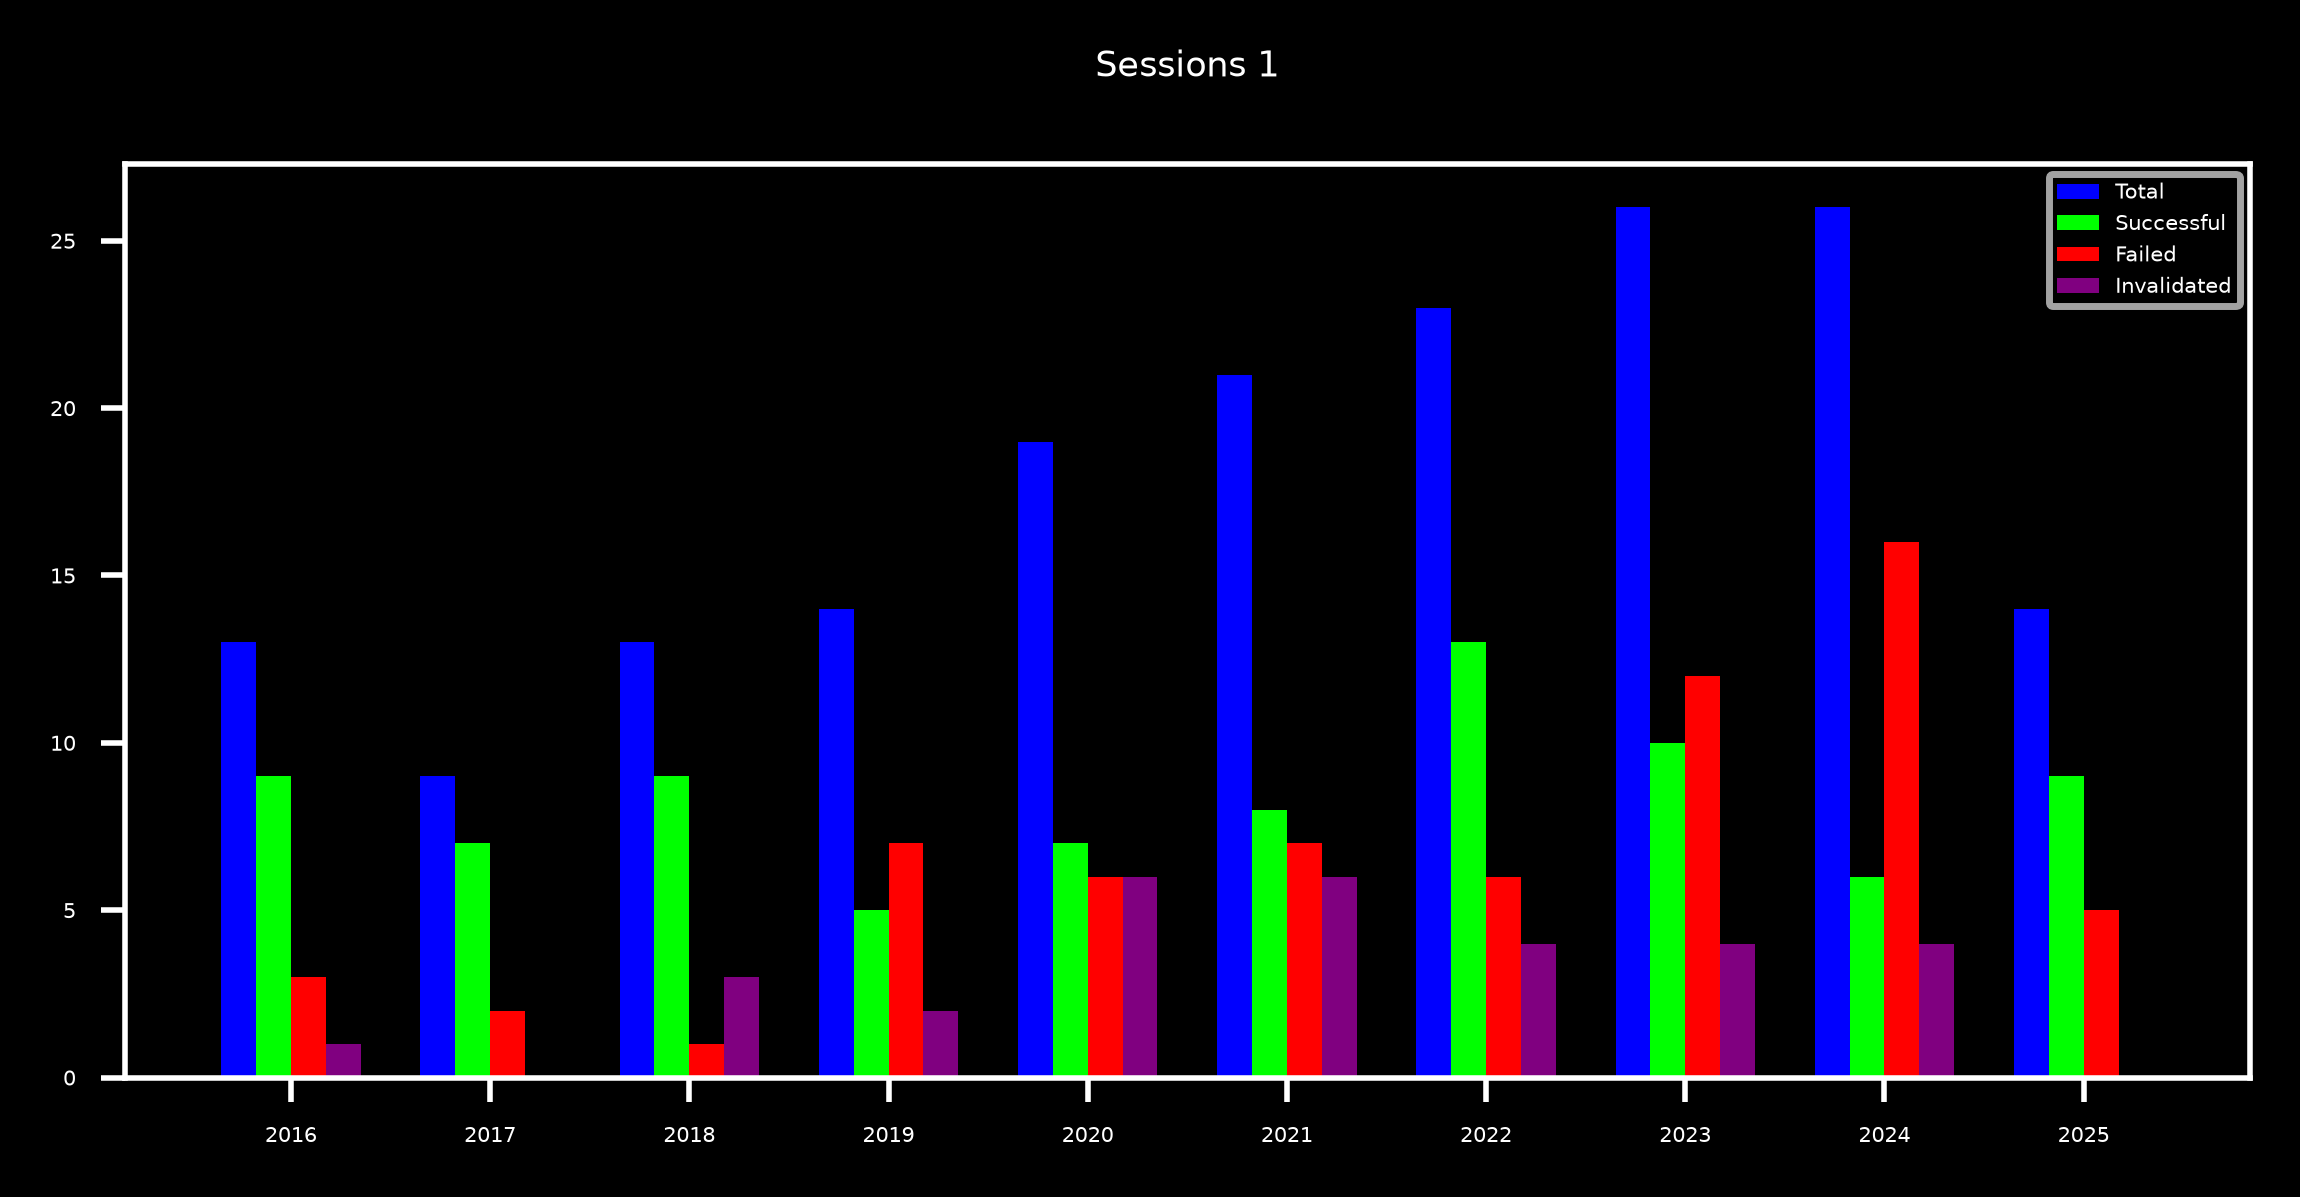

                                                        Sessions 2                                                         
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Interval ┃ Total ┃ Succ ┃ Fail ┃ Inv ┃ Succ% ┃ Fail% ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE%  ┃ Sharpe ┃ Sortino ┃ MaxDD%  ┃ p-val  ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│   2016   │  13   │  7   │  4   │  2  │  53   │  30   │  15  │ 3.05 │ 2.15 │ -1.25 │  7.0   │  14.76  │  -2.3%  │ 0.1377 │
│   2017   │   9   │  8   │  0   │  1  │  88   │   0   │  11  │ 4.28 │ 5.26 │ -1.79 │  8.54  │   6.9   │ -6.97%  │ 0.1452 │
│   2018   │  13   │  6   │  3   │  4  │  46   │  23   │  30  │ 2.93 │ 3.38 │ -6.0  │ -4.92  │  -3.74  │ -34.92% │ 0.2861 │
│   2019   │  14   │  5   │  5   │  4  │  35   │  35   │  28  │ 4.33 │ 2.48 │ -3.46 │  0.64  │   0.9   │ -14.26% │ 0.8816 │
│   2020   │  19   │  9   │  2   │  8  │  47   │  10   │  42  │ 3.6  │ 2.68 │ -3.39 │  1.45  │  1.63   │ -11.32% │ 0.6943 │
│   2021   │  21   │  7   │  4   │ 10  │  33   │  19   │  47  │ 3.97 │ 3.8  │ -5.75 │ -1.27  │  -1.22  │ -26.08% │ 0.7172 │
│   2022   │  23   │  13  │  5   │  5  │  56   │  21   │  21  │ 2.03 │ 3.68 │ -2.8  │ -0.58  │  -0.43  │ -19.48% │ 0.8633 │
│   2023   │  26   │  10  │  8   │  8  │  38   │  30   │  30  │ 3.93 │ 3.16 │ -2.48 │  1.36  │  2.26   │ -11.13% │ 0.6661 │
│   2024   │  26   │  10  │  10  │  6  │  38   │  38   │  23  │ 1.71 │ 1.54 │ -3.31 │ -5.24  │  -4.53  │ -29.51% │ 0.1048 │
│   2025   │  13   │  5   │  4   │  4  │  38   │  30   │  30  │ 1.06 │ 1.87 │ -2.25 │ -5.88  │  -5.06  │ -9.03%  │ 0.2063 │
├──────────┼───────┼──────┼──────┼─────┼───────┼───────┼──────┼──────┼──────┼───────┼────────┼─────────┼─────────┼────────┤
│   SUM    │  177  │  80  │  45  │ 52  │  45   │  25   │  29  │ 3.04 │ 2.91 │ -3.32 │ -0.27  │  -0.26  │ -57.03% │ 0.8206 │
└──────────┴───────┴──────┴──────┴─────┴───────┴───────┴──────┴──────┴──────┴───────┴────────┴─────────┴─────────┴────────┘

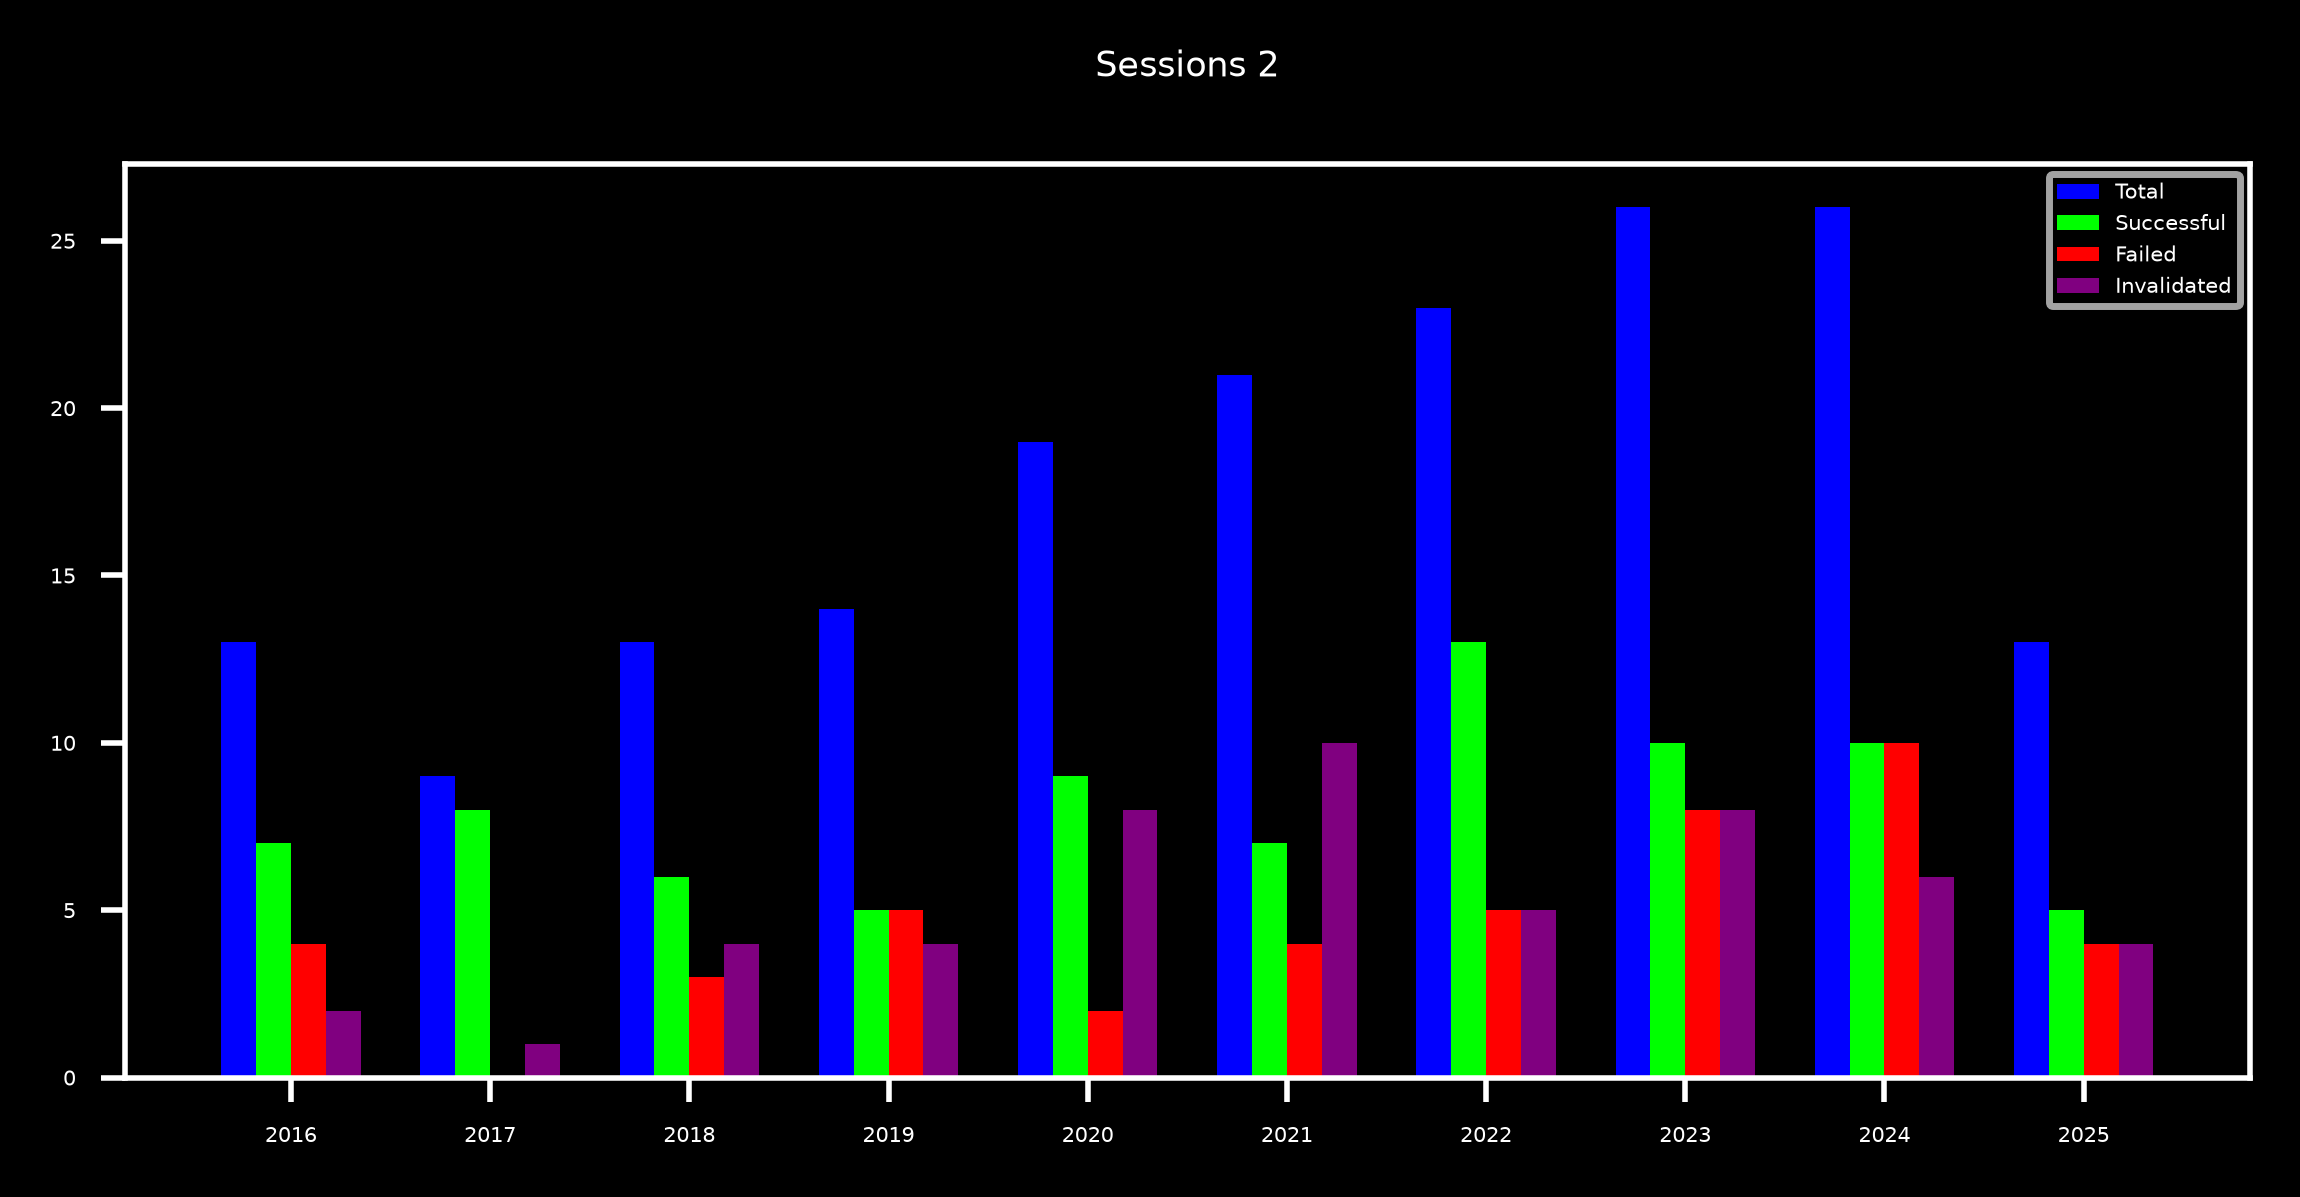

                                                        Sessions 3                                                         
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Interval ┃ Total ┃ Succ ┃ Fail ┃ Inv ┃ Succ% ┃ Fail% ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE%  ┃ Sharpe ┃ Sortino ┃ MaxDD%  ┃ p-val  ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│   2016   │  13   │  8   │  3   │  2  │  61   │  23   │  15  │ 2.23 │ 2.53 │ -1.54 │  4.4   │  7.25   │ -4.39%  │ 0.3375 │
│   2017   │   9   │  8   │  0   │  1  │  88   │   0   │  11  │ 4.67 │ 8.11 │ -3.3  │  4.43  │  1.99   │ -17.58% │ 0.4269 │
│   2018   │  13   │  6   │  1   │  6  │  46   │   7   │  46  │ 5.29 │ 4.61 │ -7.34 │ -3.79  │  -3.03  │ -39.7%  │ 0.4057 │
│   2019   │  14   │  4   │  6   │  4  │  28   │  42   │  28  │ 5.46 │ 3.23 │ -3.96 │ -0.57  │  -0.74  │ -15.15% │ 0.8953 │
│   2020   │  19   │  8   │  2   │  9  │  42   │  10   │  47  │ 4.23 │ 3.18 │ -3.65 │  2.09  │  2.78   │ -9.94%  │ 0.5724 │
│   2021   │  21   │  5   │  5   │ 11  │  23   │  23   │  52  │ 7.29 │ 5.47 │ -6.87 │  0.46  │  0.59   │ -28.87% │ 0.8956 │
│   2022   │  23   │  6   │  7   │ 10  │  26   │  30   │  43  │ 2.77 │ 4.0  │ -4.54 │ -6.05  │  -5.08  │ -40.3%  │ 0.0812 │
│   2023   │  26   │  11  │  3   │ 12  │  42   │  11   │  46  │ 4.59 │ 3.73 │ -3.02 │  1.34  │  2.14   │ -11.84% │ 0.6709 │
│   2024   │  26   │  9   │  10  │  7  │  34   │  38   │  26  │ 3.13 │ 2.16 │ -3.84 │ -3.08  │  -3.2   │ -31.21% │ 0.3313 │
│   2025   │  13   │  6   │  3   │  4  │  46   │  23   │  30  │ 2.59 │ 2.75 │ -2.37 │  2.3   │  2.59   │  -7.9%  │ 0.6102 │
├──────────┼───────┼──────┼──────┼─────┼───────┼───────┼──────┼──────┼──────┼───────┼────────┼─────────┼─────────┼────────┤
│   SUM    │  177  │  71  │  40  │ 66  │  40   │  22   │  37  │ 4.08 │ 3.77 │ -4.11 │ -0.57  │  -0.58  │ -67.9%  │ 0.6316 │
└──────────┴───────┴──────┴──────┴─────┴───────┴───────┴──────┴──────┴──────┴───────┴────────┴─────────┴─────────┴────────┘

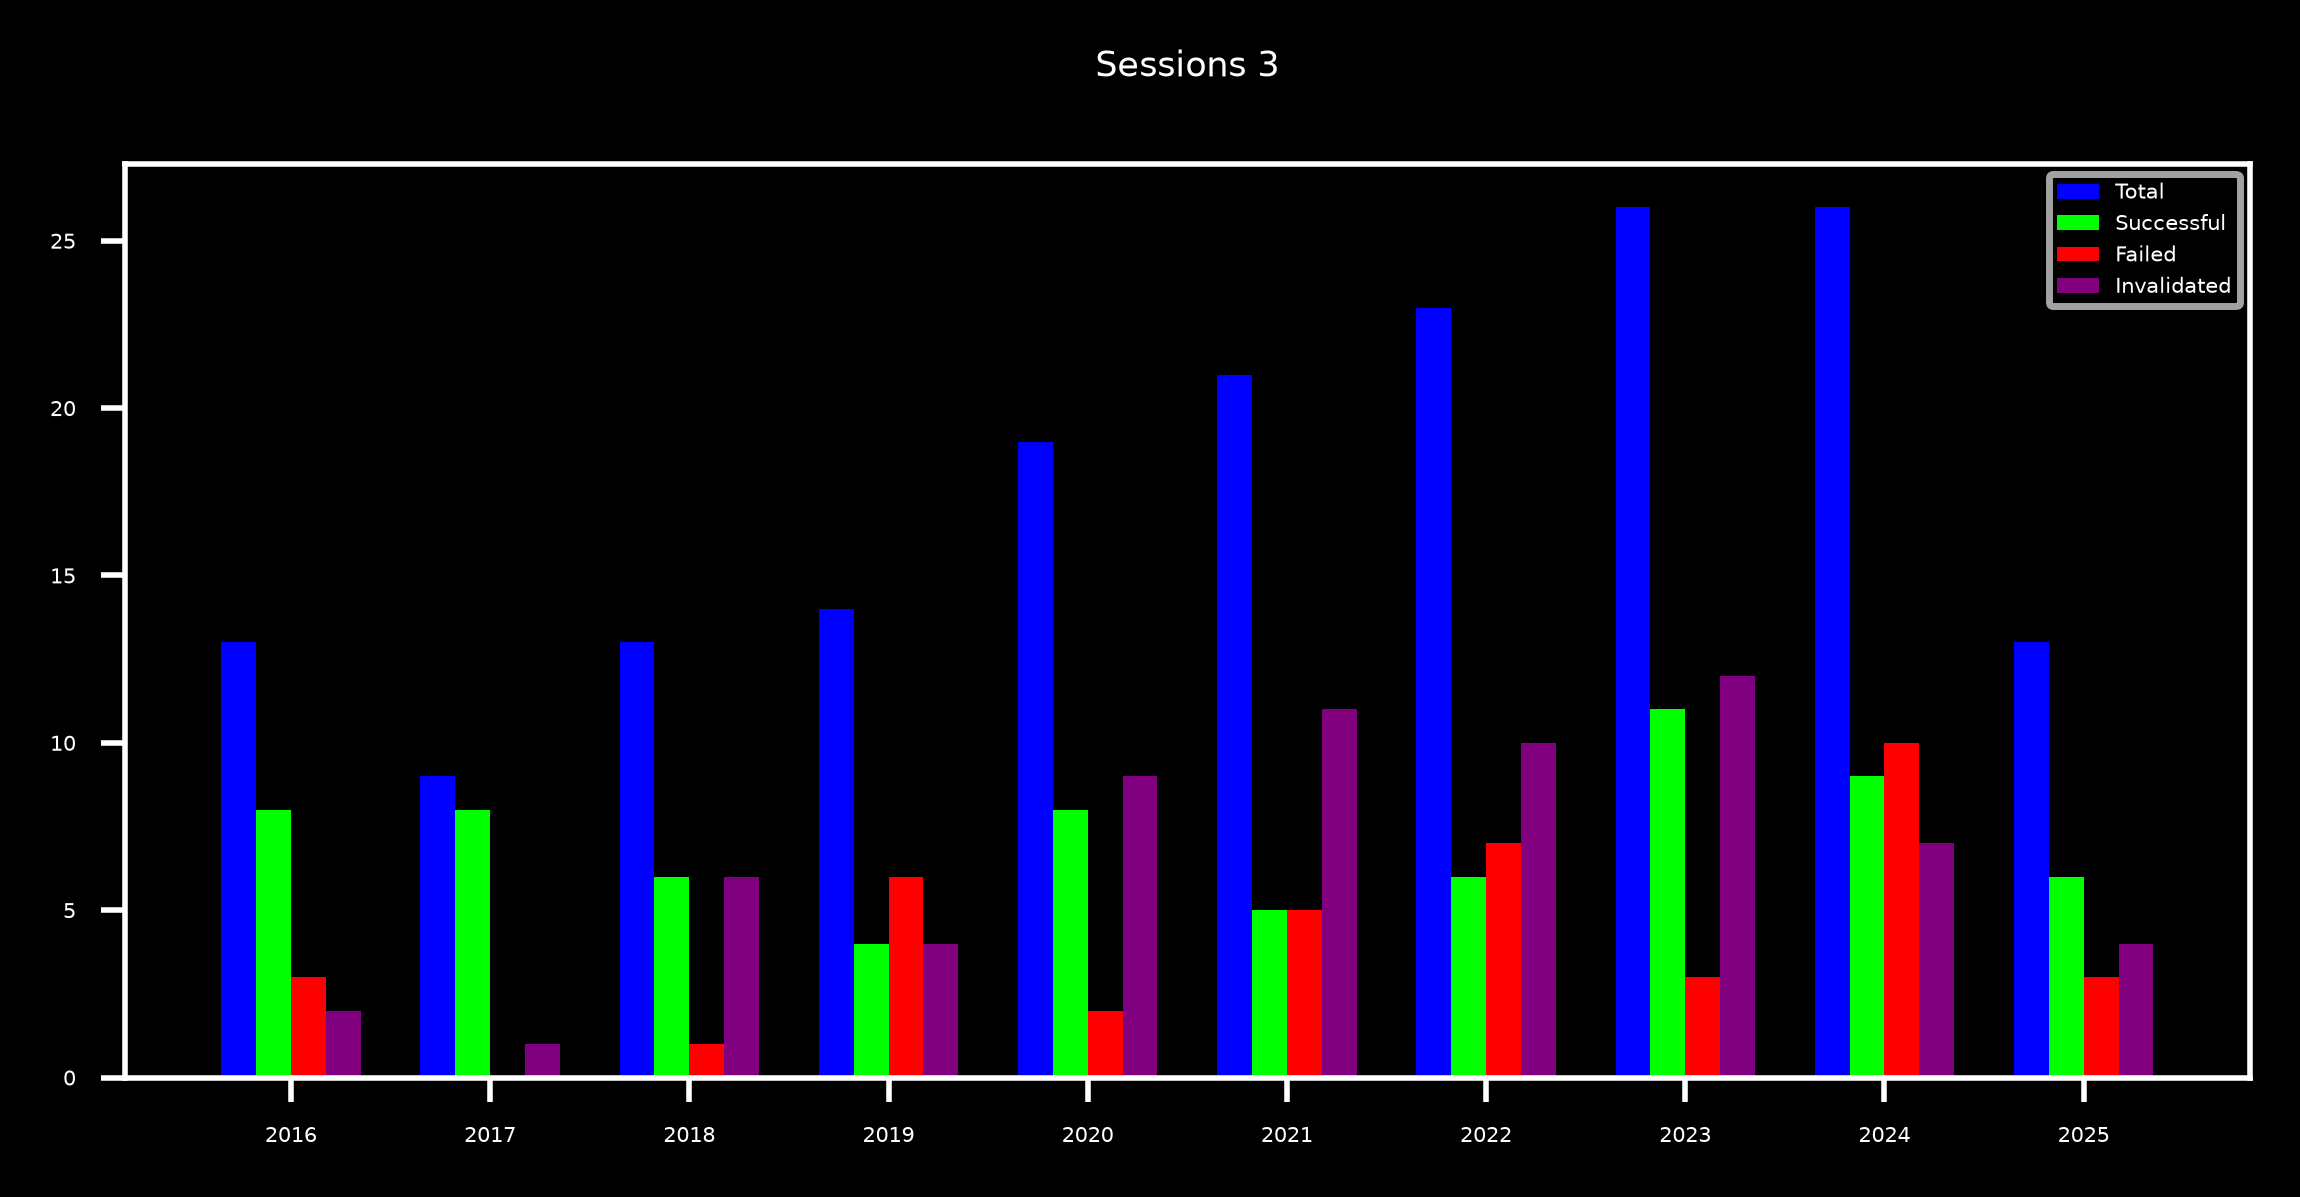

                                                        Sessions 4                                                         
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Interval ┃ Total ┃ Succ ┃ Fail ┃ Inv ┃ Succ% ┃ Fail% ┃ Inv% ┃ Chg% ┃ MFE% ┃ MAE%  ┃ Sharpe ┃ Sortino ┃ MaxDD%  ┃ p-val  ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│   2016   │  13   │  9   │  1   │  3  │  69   │   7   │  23  │ 3.02 │ 3.3  │ -1.58 │  8.57  │  18.28  │ -2.61%  │ 0.0755 │
│   2017   │   9   │  8   │  0   │  1  │  88   │   0   │  11  │ 5.33 │ 9.03 │ -4.52 │  4.72  │  2.04   │ -19.79% │ 0.3988 │
│   2018   │  13   │  5   │  1   │  7  │  38   │   7   │  53  │ 5.7  │ 4.72 │ -8.4  │ -5.26  │  -4.59  │ -48.43% │ 0.2549 │
│   2019   │  14   │  3   │  6   │  5  │  21   │  42   │  35  │ 6.44 │ 4.1  │ -5.26 │ -2.74  │  -3.26  │ -18.85% │ 0.5294 │
│   2020   │  19   │  5   │  3   │ 11  │  26   │  15   │  57  │ 5.42 │ 3.64 │ -4.71 │ -2.07  │  -2.29  │ -31.03% │ 0.5762 │
│   2021   │  21   │  5   │  5   │ 11  │  23   │  23   │  52  │ 7.52 │ 6.3  │ -7.27 │  0.39  │  0.42   │ -35.94% │ 0.9124 │
│   2022   │  23   │  7   │  5   │ 11  │  30   │  21   │  47  │ 2.4  │ 4.56 │ -5.31 │ -3.96  │  -3.52  │ -36.43% │ 0.2443 │
│   2023   │  26   │  10  │  2   │ 14  │  38   │   7   │  53  │ 6.31 │ 4.75 │ -3.58 │  2.75  │  4.29   │ -19.57% │ 0.385  │
│   2024   │  26   │  11  │  6   │  9  │  42   │  23   │  34  │ 3.86 │ 3.16 │ -4.44 │ -0.43  │  -0.56  │ -33.03% │ 0.8915 │
│   2025   │  13   │  5   │  4   │  4  │  38   │  30   │  30  │ 3.23 │ 3.11 │ -2.55 │  2.35  │  3.52   │ -9.32%  │ 0.6027 │
├──────────┼───────┼──────┼──────┼─────┼───────┼───────┼──────┼──────┼──────┼───────┼────────┼─────────┼─────────┼────────┤
│   SUM    │  177  │  68  │  33  │ 76  │  38   │  18   │  42  │ 4.72 │ 4.49 │ -4.8  │ -0.32  │  -0.33  │ -75.72% │ 0.7893 │
└──────────┴───────┴──────┴──────┴─────┴───────┴───────┴──────┴──────┴──────┴───────┴────────┴─────────┴─────────┴────────┘

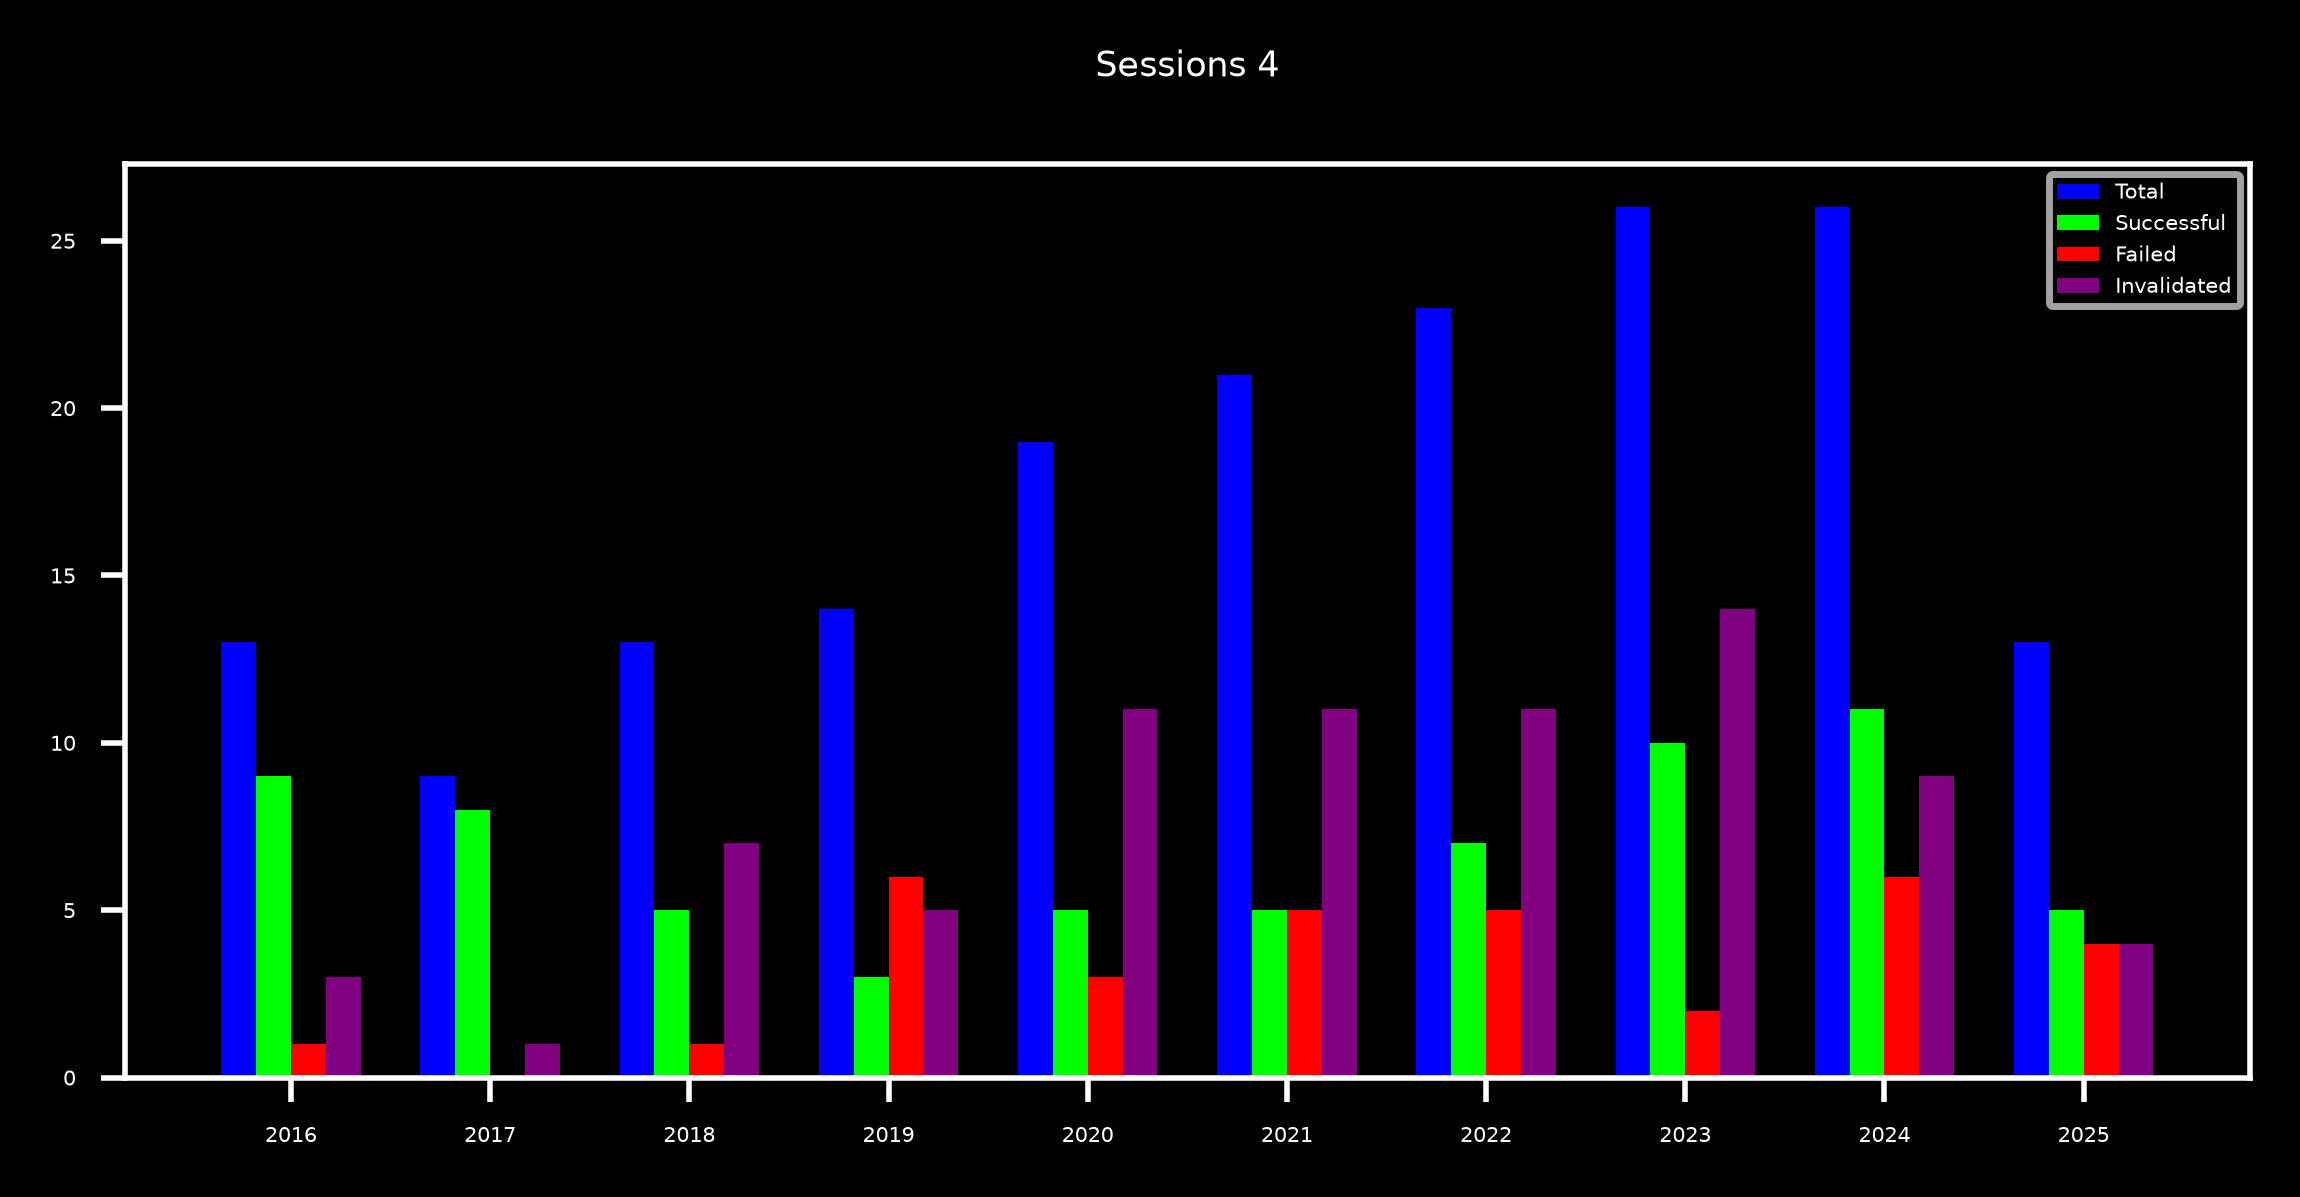

                                                         Sessions 5                                                         
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Interval ┃ Total ┃ Succ ┃ Fail ┃ Inv ┃ Succ% ┃ Fail% ┃ Inv% ┃ Chg%  ┃ MFE% ┃ MAE%  ┃ Sharpe ┃ Sortino ┃ MaxDD%  ┃ p-val  ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│   2016   │  13   │  7   │  2   │  4  │  53   │  15   │  30  │ 4.07  │ 3.55 │ -2.01 │  3.92  │  5.93   │  -5.3%  │ 0.3913 │
│   2017   │   9   │  6   │  1   │  2  │  66   │  11   │  22  │  4.8  │ 9.56 │ -5.57 │  7.08  │  7.96   │ -7.87%  │ 0.2176 │
│   2018   │  13   │  3   │  2   │  8  │  23   │  15   │  61  │ 5.78  │ 4.87 │ -9.7  │ -8.32  │  -6.64  │ -58.42% │ 0.0831 │
│   2019   │  14   │  3   │  4   │  7  │  21   │  28   │  50  │ 5.54  │ 4.23 │ -5.71 │ -3.72  │  -4.5   │ -20.73% │ 0.3968 │
│   2020   │  19   │  4   │  4   │ 11  │  21   │  21   │  57  │ 10.57 │ 5.26 │ -4.98 │  2.05  │  3.07   │ -17.5%  │ 0.5811 │
│   2021   │  21   │  4   │  4   │ 13  │  19   │  19   │  61  │ 11.25 │ 7.37 │ -8.85 │ -1.29  │  -1.46  │ -50.56% │ 0.7137 │
│   2022   │  23   │  8   │  4   │ 11  │  34   │  17   │  47  │ 3.25  │ 5.37 │ -6.01 │ -2.36  │  -2.0   │ -45.1%  │ 0.483  │
│   2023   │  26   │  10  │  2   │ 14  │  38   │   7   │  53  │ 7.13  │ 5.29 │ -3.67 │  2.92  │  4.83   │ -20.28% │ 0.3574 │
│   2024   │  26   │  9   │  8   │  9  │  34   │  30   │  34  │ 5.96  │ 3.96 │ -4.64 │  0.8   │  1.07   │ -23.59% │ 0.7985 │
│   2025   │  13   │  4   │  4   │  5  │  30   │  30   │  38  │  4.6  │ 3.59 │ -3.1  │  0.62  │  0.88   │  -9.8%  │ 0.8898 │
├──────────┼───────┼──────┼──────┼─────┼───────┼───────┼──────┼───────┼──────┼───────┼────────┼─────────┼─────────┼────────┤
│   SUM    │  177  │  58  │  35  │ 84  │  32   │  19   │  47  │  6.0  │ 5.2  │ -5.41 │  -0.5  │  -0.53  │ -81.89% │ 0.6731 │
└──────────┴───────┴──────┴──────┴─────┴───────┴───────┴──────┴───────┴──────┴───────┴────────┴─────────┴─────────┴────────┘

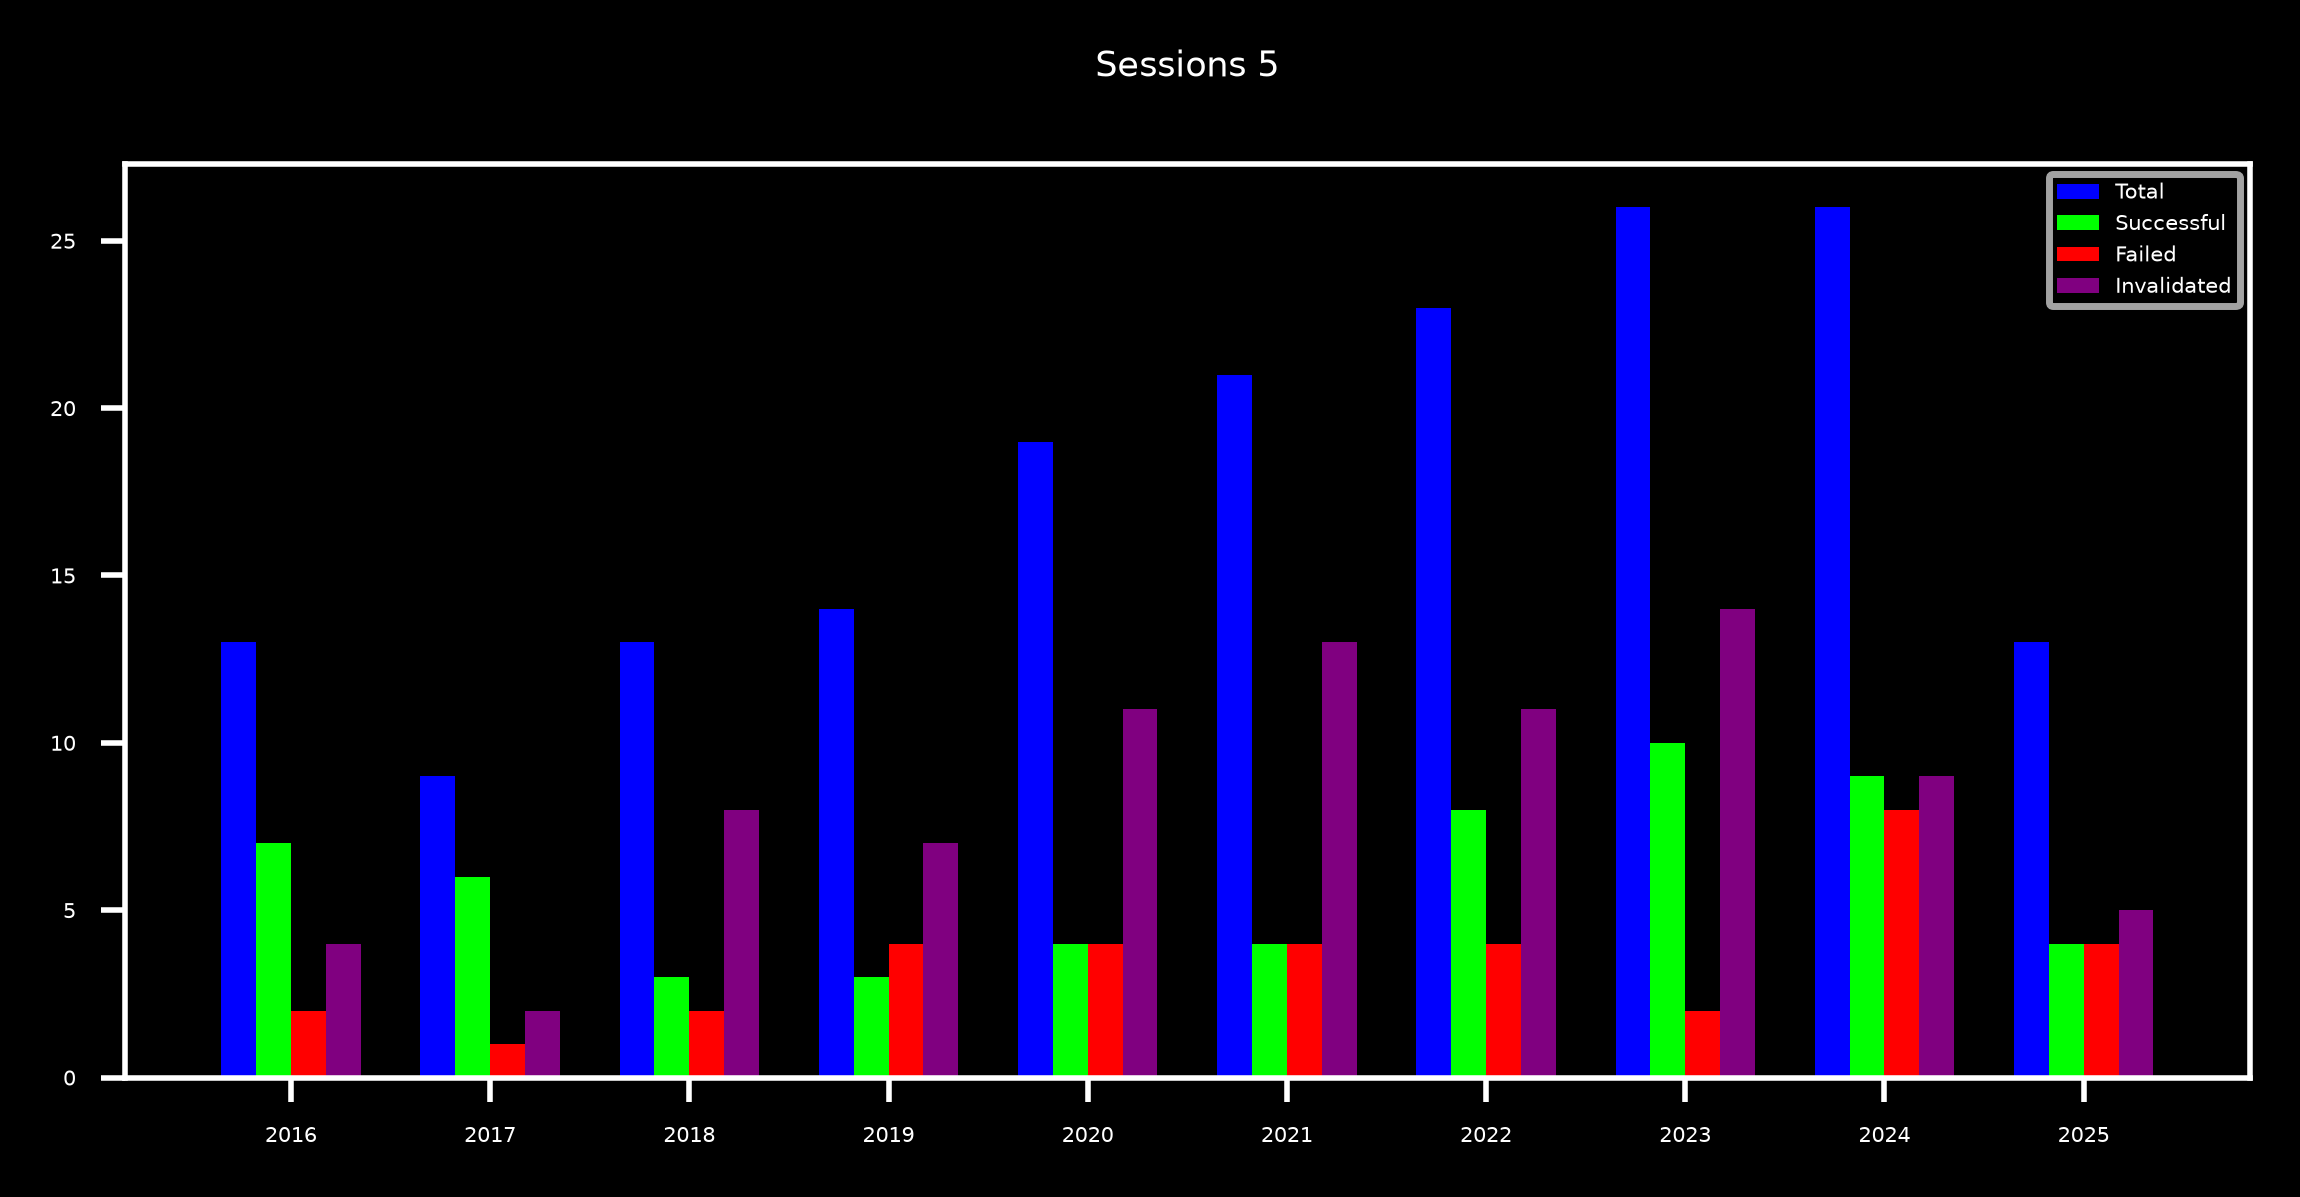

                                                         Sessions 6                                                          
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Interval ┃ Total ┃ Succ ┃ Fail ┃ Inv ┃ Succ% ┃ Fail% ┃ Inv% ┃ Chg% ┃ MFE%  ┃  MAE%  ┃ Sharpe ┃ Sortino ┃ MaxDD%  ┃ p-val  ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│   2016   │  13   │  7   │  0   │  6  │  53   │   0   │  46  │ 3.44 │ 4.02  │ -3.12  │  5.05  │  6.71   │ -4.36%  │ 0.2735 │
│   2017   │   9   │  6   │  0   │  3  │  66   │   0   │  33  │ 5.29 │ 10.12 │ -7.27  │ 14.29  │  19.18  │ -3.16%  │ 0.0271 │
│   2018   │  13   │  4   │  0   │  9  │  30   │   0   │  69  │ 3.08 │ 4.87  │ -11.96 │ -9.62  │  -6.76  │ -64.79% │ 0.0494 │
│   2019   │  14   │  3   │  4   │  7  │  21   │  28   │  50  │ 5.4  │ 4.23  │ -6.07  │ -0.16  │  -0.18  │ -16.07% │ 0.9697 │
│   2020   │  19   │  5   │  2   │ 12  │  26   │  10   │  63  │ 8.22 │ 5.83  │ -5.56  │  0.48  │  0.52   │ -30.54% │ 0.8966 │
│   2021   │  21   │  5   │  3   │ 13  │  23   │  14   │  61  │ 9.31 │ 7.64  │ -9.52  │ -1.01  │  -1.08  │ -47.36% │ 0.7743 │
│   2022   │  23   │  8   │  4   │ 11  │  34   │  17   │  47  │ 3.72 │ 5.87  │ -6.29  │  -1.7  │  -1.56  │ -40.93% │ 0.6133 │
│   2023   │  26   │  10  │  2   │ 14  │  38   │   7   │  53  │ 10.0 │ 6.16  │ -3.73  │  4.69  │  10.51  │ -18.13% │ 0.1445 │
│   2024   │  26   │  9   │  7   │ 10  │  34   │  26   │  38  │ 5.99 │ 4.31  │  -5.1  │  0.16  │  0.19   │ -32.37% │ 0.9597 │
│   2025   │  13   │  5   │  2   │  6  │  38   │  15   │  46  │ 3.32 │ 3.65  │ -3.39  │  1.59  │   2.5   │ -11.92% │ 0.7246 │
├──────────┼───────┼──────┼──────┼─────┼───────┼───────┼──────┼──────┼───────┼────────┼────────┼─────────┼─────────┼────────┤
│   SUM    │  177  │  62  │  24  │ 91  │  35   │  13   │  51  │ 6.0  │  5.6  │ -6.05  │  0.08  │  0.08   │ -82.92% │ 0.9476 │
└──────────┴───────┴──────┴──────┴─────┴───────┴───────┴──────┴──────┴───────┴────────┴────────┴─────────┴─────────┴────────┘

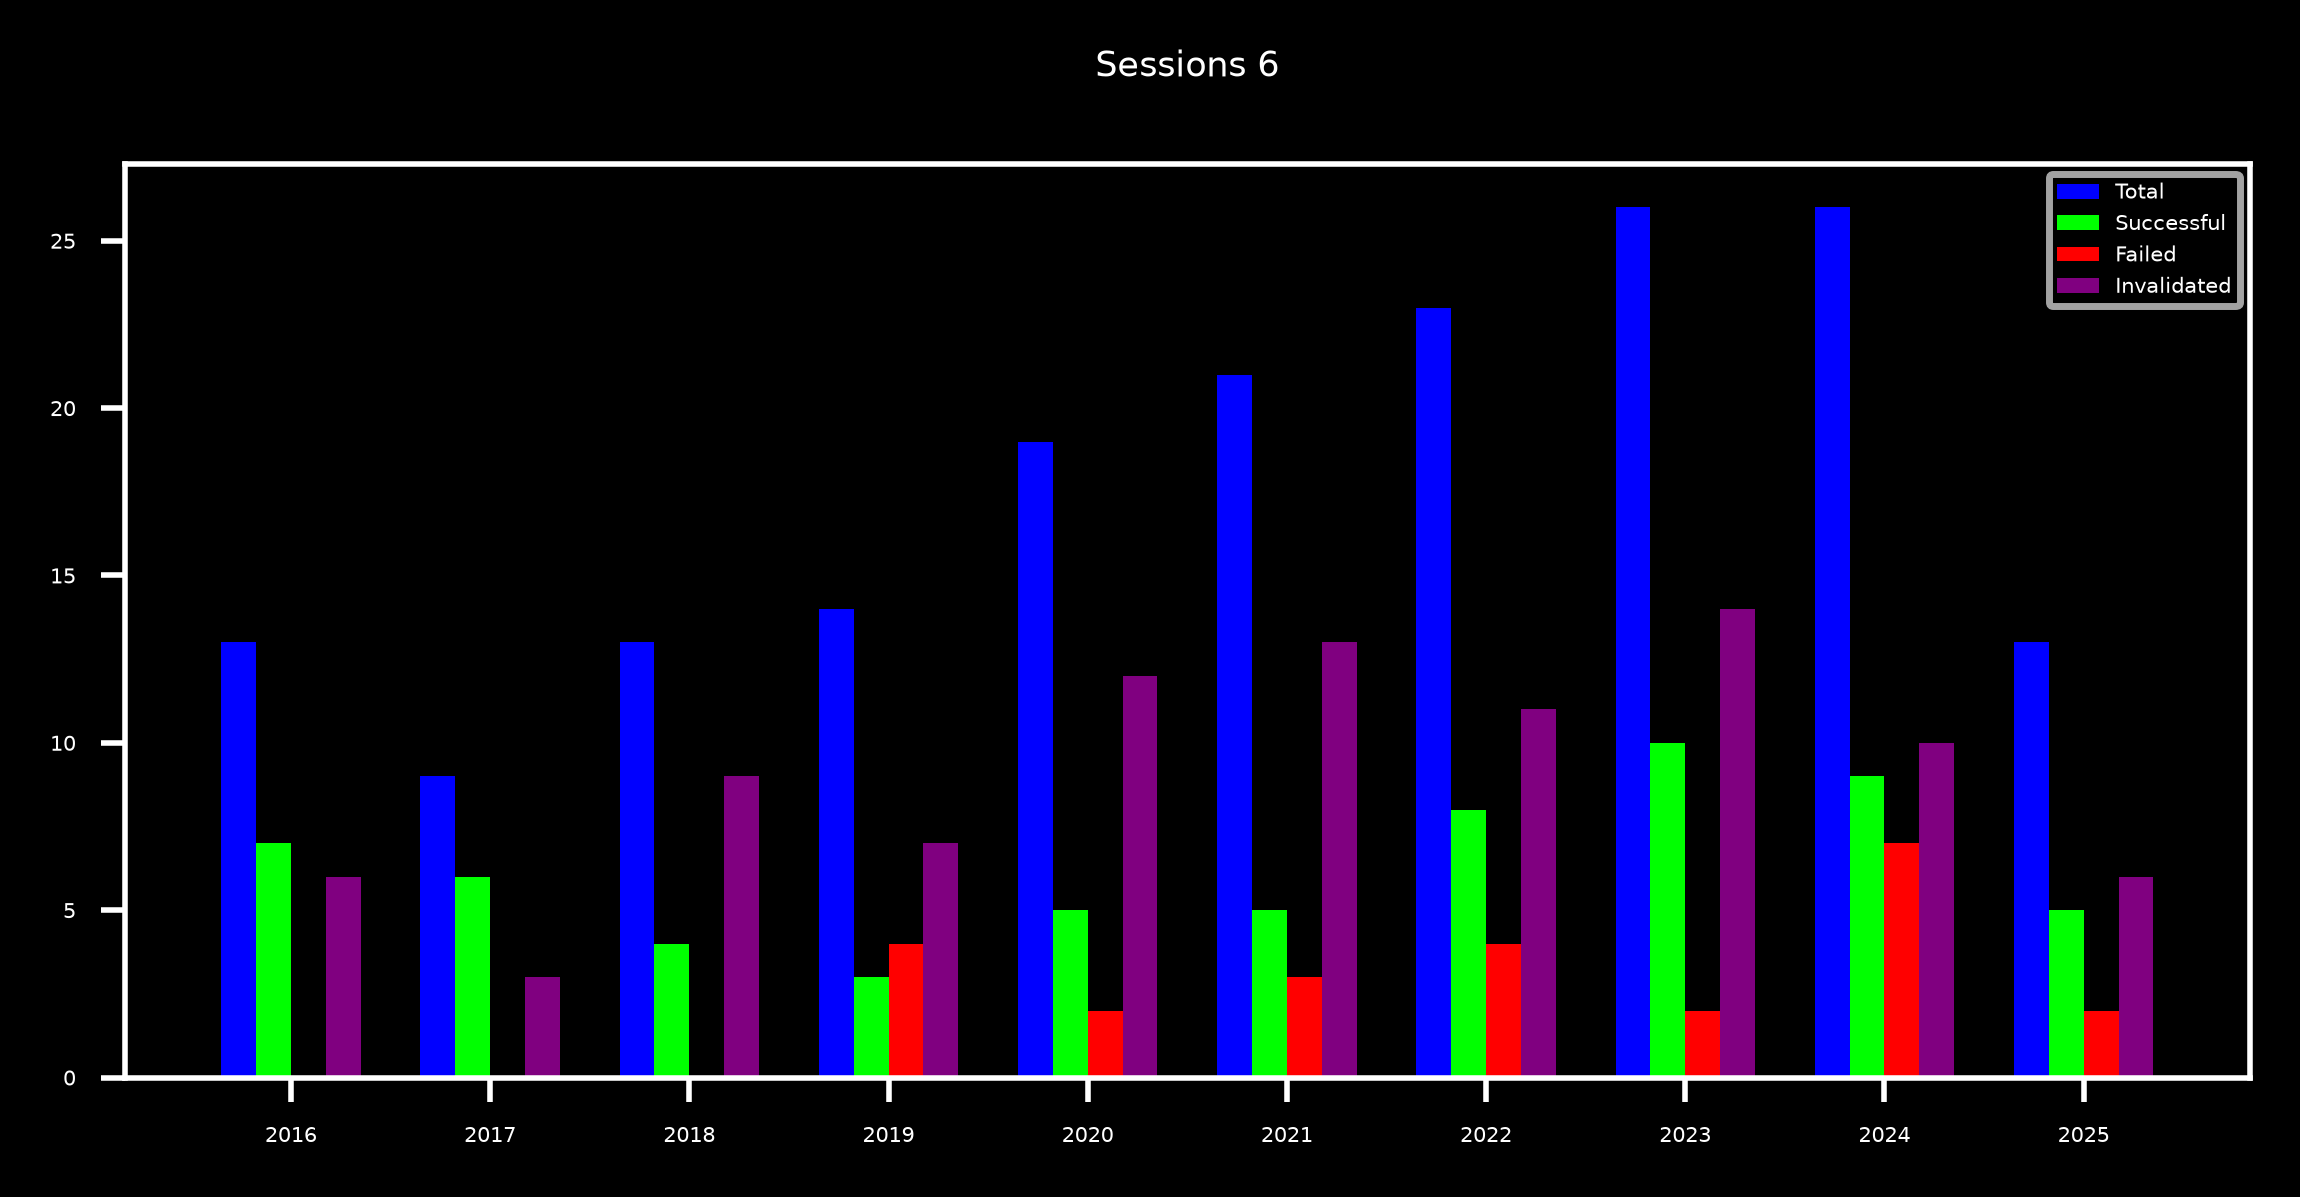

                                                          Sessions 7                                                          
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Interval ┃ Total ┃ Succ ┃ Fail ┃ Inv ┃ Succ% ┃ Fail% ┃ Inv% ┃ Chg%  ┃ MFE%  ┃  MAE%  ┃ Sharpe ┃ Sortino ┃ MaxDD%  ┃ p-val  ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│   2016   │  13   │  6   │  0   │  7  │  46   │   0   │  53  │ 3.28  │ 4.03  │ -3.63  │  1.98  │   2.3   │ -7.84%  │ 0.6605 │
│   2017   │   9   │  6   │  0   │  3  │  66   │   0   │  33  │ 6.59  │ 10.26 │ -7.27  │ 10.34  │  10.54  │ -5.22%  │ 0.0864 │
│   2018   │  13   │  3   │  1   │  9  │  23   │   7   │  69  │ 3.51  │ 5.21  │ -12.48 │ -10.71 │  -7.72  │ -62.59% │ 0.0315 │
│   2019   │  14   │  5   │  2   │  7  │  35   │  14   │  50  │ 4.68  │ 5.15  │ -6.42  │  0.6   │  0.59   │ -16.11% │ 0.8896 │
│   2020   │  19   │  5   │  2   │ 12  │  26   │  10   │  63  │ 8.75  │  6.5  │ -5.84  │  3.12  │  3.45   │ -18.38% │ 0.4026 │
│   2021   │  21   │  4   │  1   │ 16  │  19   │   4   │  76  │ 10.48 │ 7.95  │ -10.52 │ -1.03  │  -1.15  │ -47.2%  │ 0.769  │
│   2022   │  23   │  6   │  6   │ 11  │  26   │  26   │  47  │ 4.05  │ 6.01  │ -7.33  │ -3.94  │  -3.31  │ -55.63% │ 0.2471 │
│   2023   │  26   │  10  │  1   │ 15  │  38   │   3   │  57  │ 10.09 │ 6.55  │ -3.87  │  5.6   │  14.05  │ -14.02% │ 0.0839 │
│   2024   │  26   │  10  │  5   │ 11  │  38   │  19   │  42  │ 5.62  │ 4.75  │ -5.52  │  1.48  │  2.08   │ -19.13% │ 0.6389 │
│   2025   │  13   │  6   │  1   │  6  │  46   │   7   │  46  │ 3.23  │ 3.99  │ -3.59  │  1.29  │  1.42   │ -15.01% │ 0.7746 │
├──────────┼───────┼──────┼──────┼─────┼───────┼───────┼──────┼───────┼───────┼────────┼────────┼─────────┼─────────┼────────┤
│   SUM    │  177  │  61  │  19  │ 97  │  34   │  10   │  54  │ 6.22  │ 5.98  │ -6.53  │  0.14  │  0.14   │ -84.41% │ 0.9074 │
└──────────┴───────┴──────┴──────┴─────┴───────┴───────┴──────┴───────┴───────┴────────┴────────┴─────────┴─────────┴────────┘

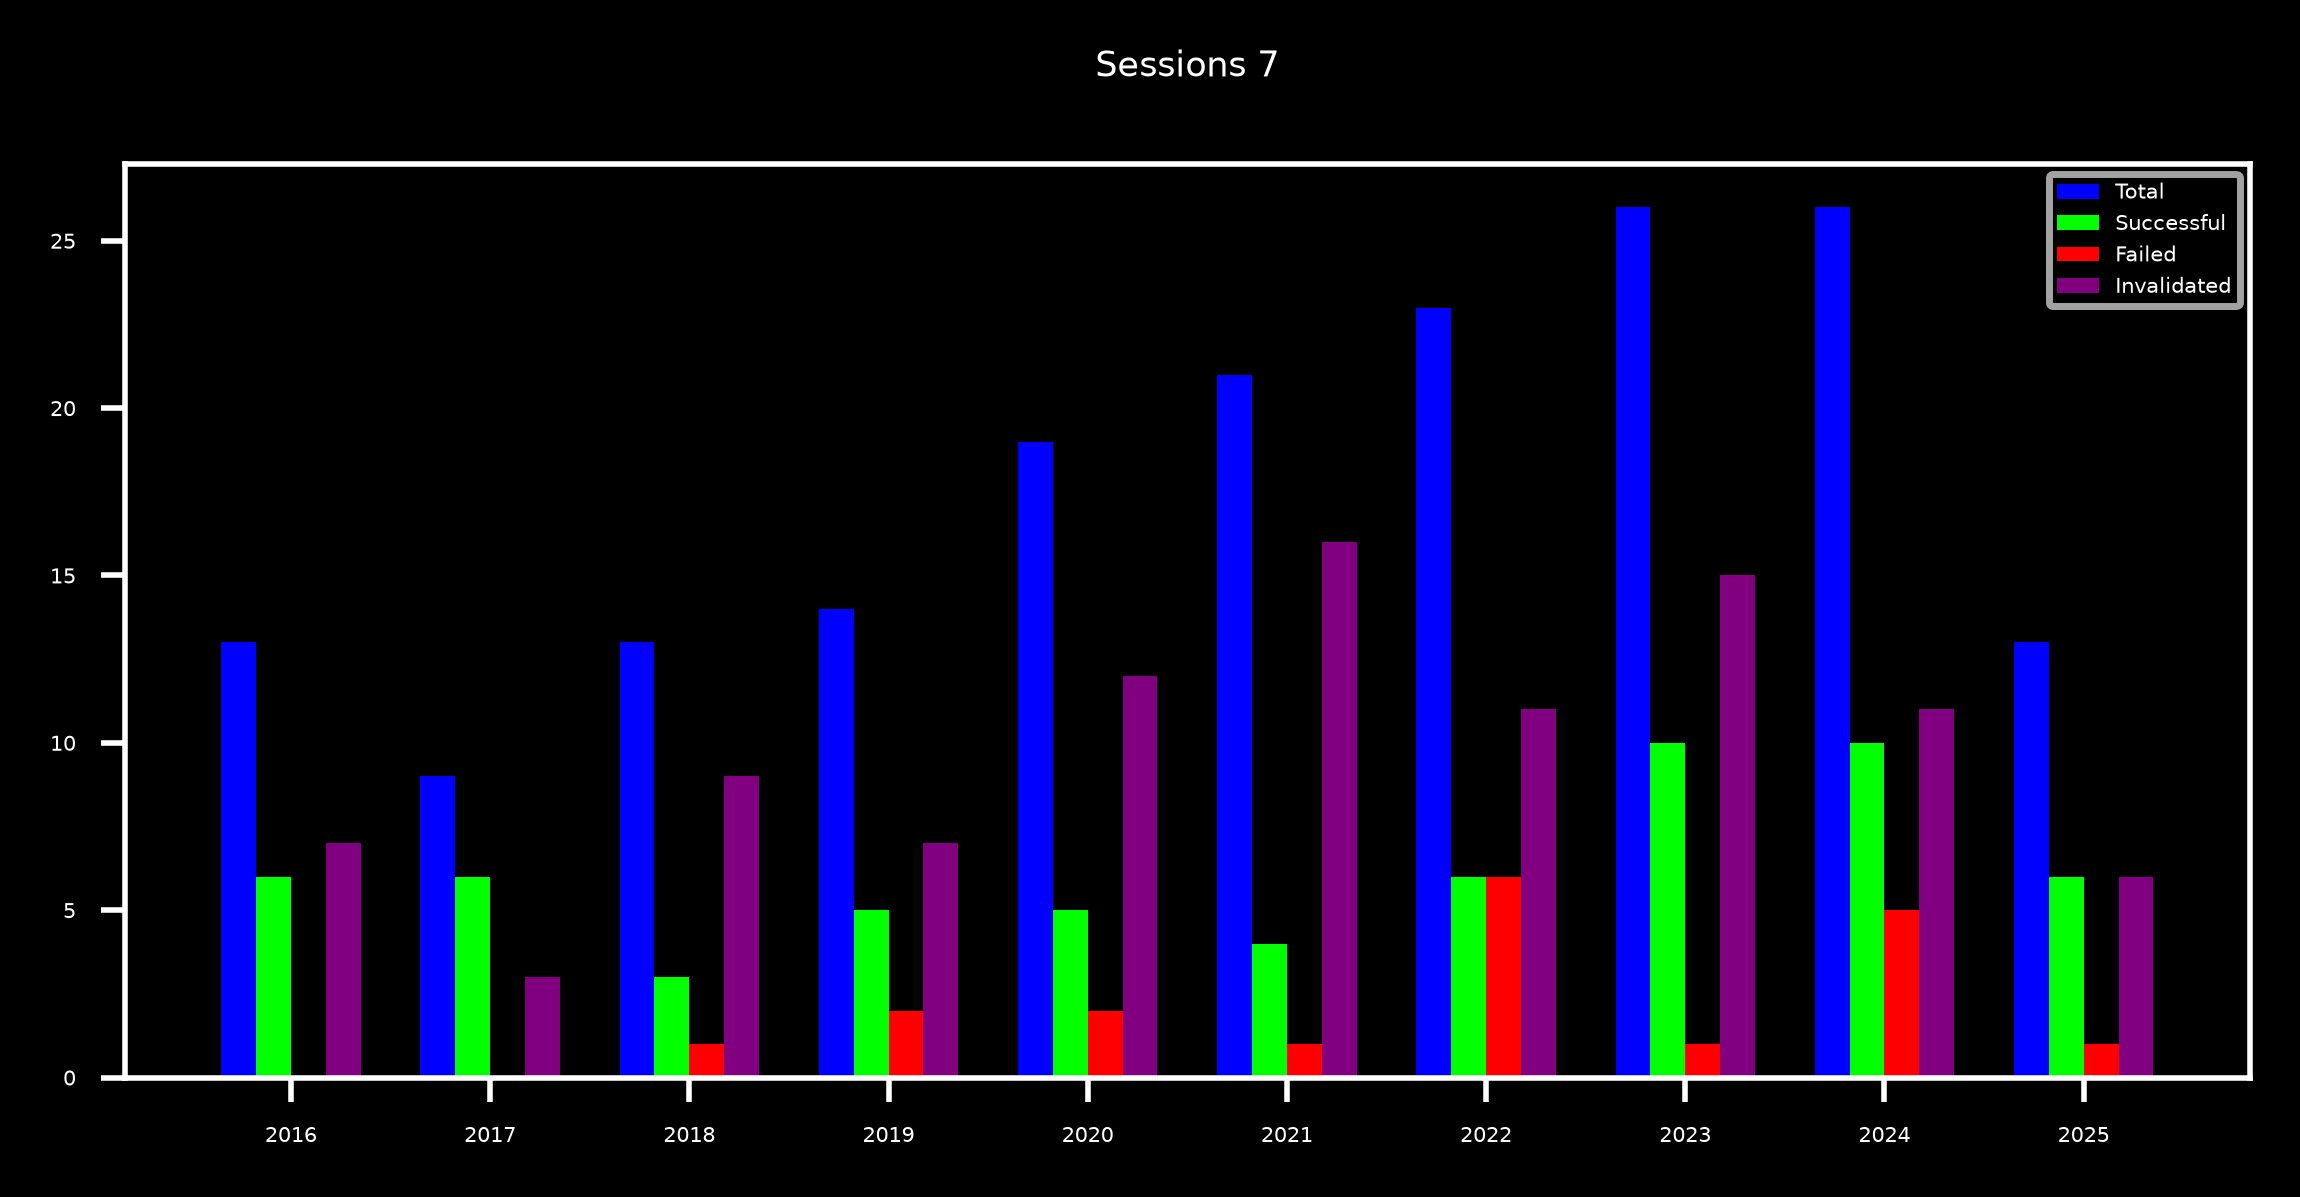

                                                          Sessions 8                                                          
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Interval ┃ Total ┃ Succ ┃ Fail ┃ Inv ┃ Succ% ┃ Fail% ┃ Inv% ┃ Chg%  ┃ MFE%  ┃  MAE%  ┃ Sharpe ┃ Sortino ┃ MaxDD%  ┃ p-val  ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│   2016   │  13   │  6   │  0   │  7  │  46   │   0   │  53  │ 2.83  │ 4.44  │ -5.23  │ -1.19  │  -0.85  │ -8.07%  │ 0.7913 │
│   2017   │   9   │  6   │  0   │  3  │  66   │   0   │  33  │ 7.66  │ 13.66 │ -7.27  │ 17.03  │  44.48  │  0.0%   │ 0.0123 │
│   2018   │  13   │  4   │  0   │  9  │  30   │   0   │  69  │ 3.85  │ 5.27  │ -13.2  │ -9.22  │  -6.57  │ -66.63% │ 0.0582 │
│   2019   │  14   │  4   │  2   │  8  │  28   │  14   │  57  │ 6.25  │ 5.63  │ -7.01  │ -0.35  │  -0.38  │ -24.21% │ 0.9355 │
│   2020   │  19   │  5   │  2   │ 12  │  26   │  10   │  63  │ 10.77 │ 6.66  │ -5.85  │  3.74  │   5.3   │ -16.71% │ 0.318  │
│   2021   │  21   │  4   │  0   │ 17  │  19   │   0   │  80  │ 11.34 │ 8.56  │ -11.58 │ -1.23  │  -1.18  │ -48.46% │ 0.7269 │
│   2022   │  23   │  5   │  4   │ 14  │  21   │  17   │  60  │ 4.67  │ 6.16  │  -8.3  │  -5.1  │  -4.33  │ -60.89% │ 0.1376 │
│   2023   │  26   │  10  │  1   │ 15  │  38   │   3   │  57  │ 10.76 │ 7.58  │ -4.15  │  6.04  │  11.19  │ -19.71% │ 0.0637 │
│   2024   │  26   │  10  │  5   │ 11  │  38   │  19   │  42  │ 5.83  │ 5.46  │ -5.73  │  1.82  │  2.37   │ -17.14% │ 0.5648 │
│   2025   │  12   │  4   │  2   │  6  │  33   │  16   │  50  │ 5.27  │  4.5  │  -3.6  │  2.76  │  3.34   │ -13.68% │ 0.5596 │
├──────────┼───────┼──────┼──────┼─────┼───────┼───────┼──────┼───────┼───────┼────────┼────────┼─────────┼─────────┼────────┤
│   SUM    │  176  │  58  │  16  │ 102 │  32   │   9   │  57  │ 7.12  │ 6.64  │ -7.09  │  0.38  │  0.37   │ -88.43% │ 0.7507 │
└──────────┴───────┴──────┴──────┴─────┴───────┴───────┴──────┴───────┴───────┴────────┴────────┴─────────┴─────────┴────────┘

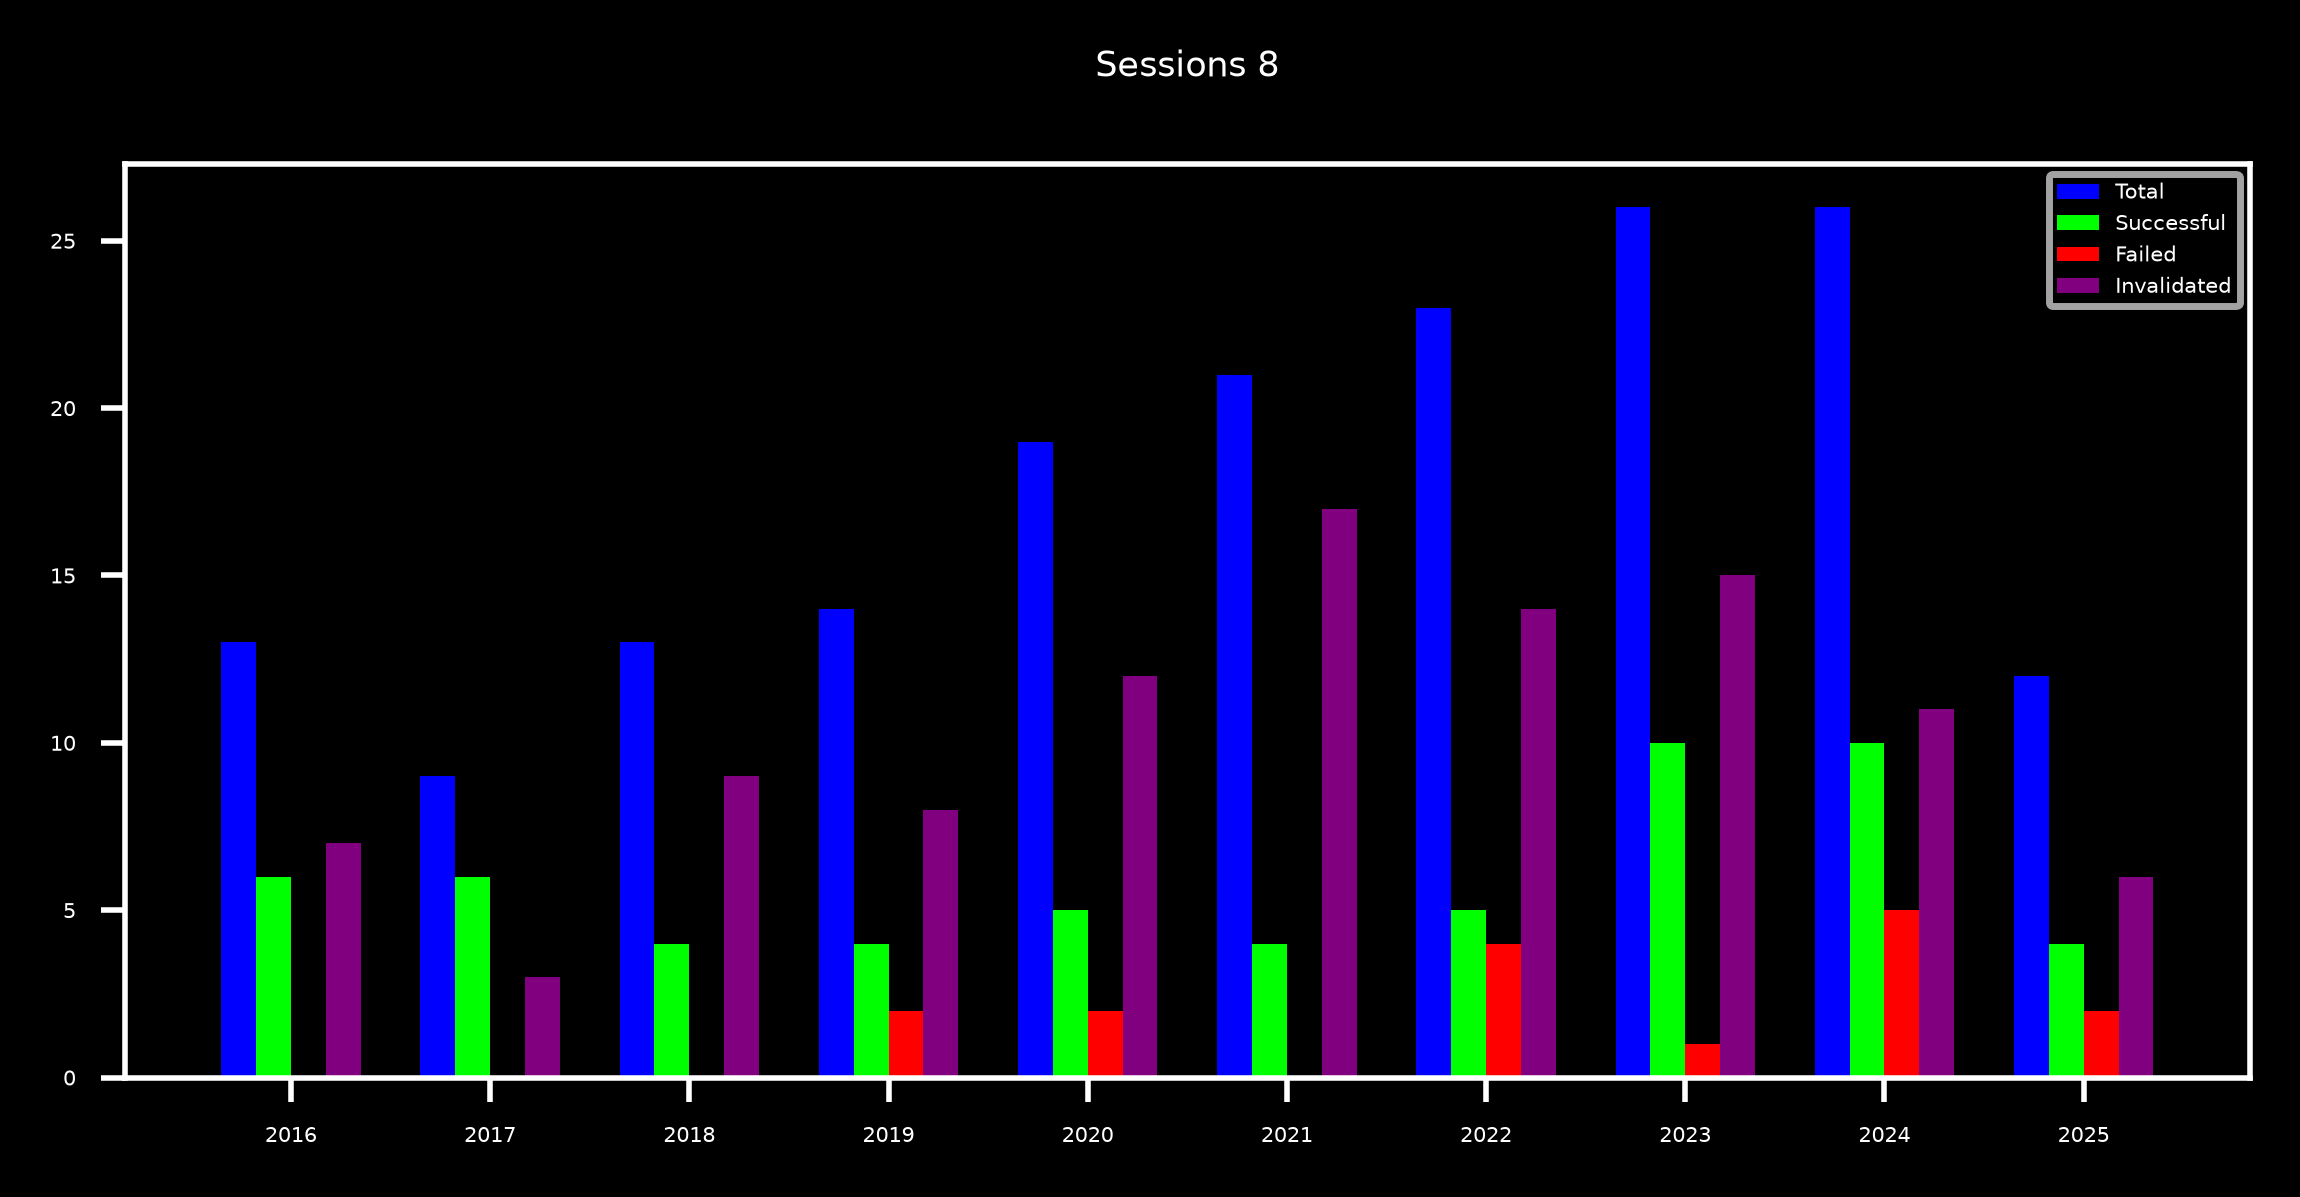

                                                          Sessions 9                                                          
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Interval ┃ Total ┃ Succ ┃ Fail ┃ Inv ┃ Succ% ┃ Fail% ┃ Inv% ┃ Chg%  ┃ MFE%  ┃  MAE%  ┃ Sharpe ┃ Sortino ┃ MaxDD%  ┃ p-val  ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│   2016   │  13   │  6   │  0   │  7  │  46   │   0   │  53  │ 3.17  │ 4.67  │ -5.41  │  0.52  │  0.42   │ -6.41%  │ 0.9079 │
│   2017   │   9   │  6   │  0   │  3  │  66   │   0   │  33  │ 11.18 │ 16.64 │ -8.11  │ 14.87  │  13.85  │  0.0%   │ 0.0229 │
│   2018   │  13   │  3   │  0   │ 10  │  23   │   0   │  76  │ 4.98  │ 5.27  │ -14.35 │ -9.92  │  -7.33  │ -71.73% │ 0.0438 │
│   2019   │  14   │  6   │  0   │  8  │  42   │   0   │  57  │ 6.42  │ 7.18  │ -7.59  │  1.94  │  2.47   │ -21.69% │ 0.6555 │
│   2020   │  19   │  6   │  1   │ 12  │  31   │   5   │  63  │ 10.54 │ 7.17  │ -5.88  │  3.94  │   5.7   │ -18.29% │ 0.2941 │
│   2021   │  21   │  4   │  0   │ 17  │  19   │   0   │  80  │ 13.28 │ 9.38  │ -12.96 │ -0.89  │  -0.99  │ -53.59% │ 0.8005 │
│   2022   │  23   │  5   │  3   │ 15  │  21   │  13   │  65  │ 4.02  │ 6.42  │ -8.63  │ -5.26  │  -4.38  │ -56.38% │ 0.1265 │
│   2023   │  26   │  10  │  0   │ 16  │  38   │   0   │  61  │ 10.88 │ 8.43  │ -4.33  │  6.61  │  12.42  │ -18.57% │ 0.0437 │
│   2024   │  26   │  11  │  3   │ 12  │  42   │  11   │  46  │ 7.24  │ 6.12  │ -5.96  │  2.2   │  3.12   │ -18.63% │ 0.4863 │
│   2025   │  12   │  5   │  1   │  6  │  41   │   8   │  50  │ 5.08  │ 4.74  │ -3.76  │  1.49  │  1.52   │ -17.98% │ 0.7515 │
├──────────┼───────┼──────┼──────┼─────┼───────┼───────┼──────┼───────┼───────┼────────┼────────┼─────────┼─────────┼────────┤
│   SUM    │  176  │  62  │  8   │ 106 │  35   │   4   │  60  │  7.9  │ 7.36  │ -7.56  │  0.78  │   0.8   │ -86.85% │ 0.513  │
└──────────┴───────┴──────┴──────┴─────┴───────┴───────┴──────┴───────┴───────┴────────┴────────┴─────────┴─────────┴────────┘

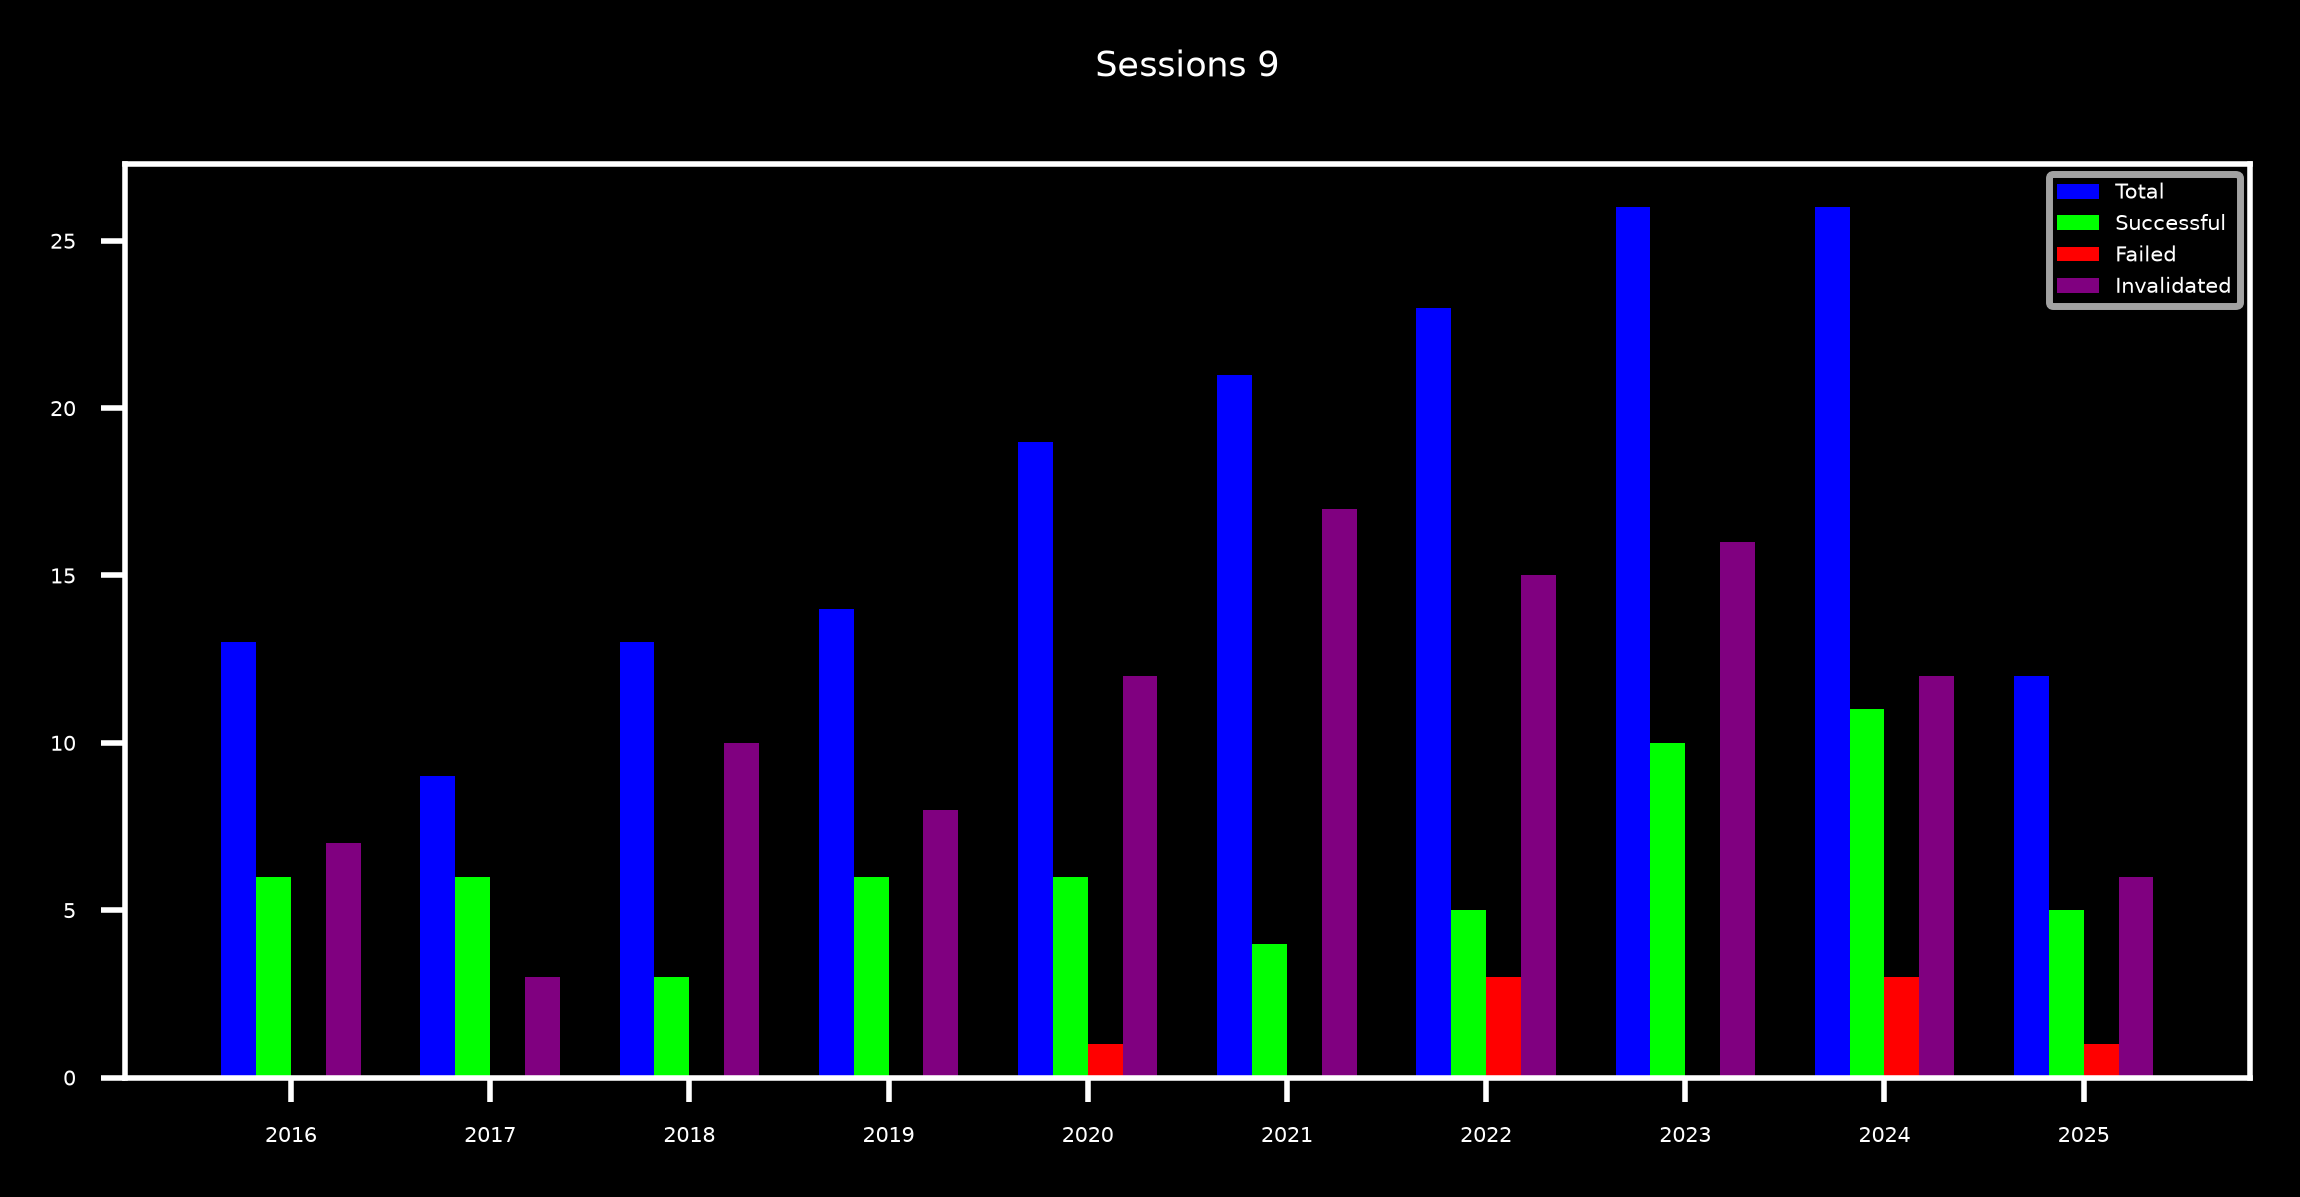

                                                         Sessions 10                                                          
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Interval ┃ Total ┃ Succ ┃ Fail ┃ Inv ┃ Succ% ┃ Fail% ┃ Inv% ┃ Chg%  ┃ MFE%  ┃  MAE%  ┃ Sharpe ┃ Sortino ┃ MaxDD%  ┃ p-val  ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│   2016   │  13   │  6   │  0   │  7  │  46   │   0   │  53  │ 3.64  │ 4.89  │ -5.41  │  1.57  │  1.38   │ -6.35%  │ 0.7273 │
│   2017   │   9   │  6   │  0   │  3  │  66   │   0   │  33  │ 14.03 │ 17.82 │ -8.11  │ 25.22  │  58.67  │  0.0%   │ 0.0014 │
│   2018   │  13   │  2   │  0   │ 11  │  15   │   0   │  84  │ 7.46  │  5.3  │ -15.44 │ -9.66  │  -7.76  │ -64.26% │ 0.0487 │
│   2019   │  14   │  6   │  0   │  8  │  42   │   0   │  57  │ 8.66  │ 8.62  │ -7.92  │  2.69  │  2.99   │ -26.4%  │ 0.5367 │
│   2020   │  19   │  6   │  1   │ 12  │  31   │   5   │  63  │ 13.88 │ 8.37  │  -7.9  │  1.5   │  1.44   │ -46.29% │ 0.6851 │
│   2021   │  21   │  3   │  0   │ 18  │  14   │   0   │  85  │ 17.65 │ 9.84  │ -13.48 │ -1.01  │  -1.22  │ -48.25% │ 0.7739 │
│   2022   │  23   │  4   │  3   │ 16  │  17   │  13   │  69  │ 5.33  │ 6.56  │ -9.52  │ -6.19  │  -5.29  │ -56.21% │ 0.0749 │
│   2023   │  26   │  10  │  0   │ 16  │  38   │   0   │  61  │ 11.13 │ 8.88  │ -4.37  │  7.09  │  13.89  │ -17.58% │ 0.0315 │
│   2024   │  26   │  11  │  3   │ 12  │  42   │  11   │  46  │ 5.88  │ 6.42  │ -5.97  │  2.45  │  3.04   │ -13.76% │ 0.4393 │
│   2025   │  12   │  5   │  1   │  6  │  41   │   8   │  50  │ 6.25  │ 5.54  │ -3.96  │  5.99  │  8.67   │ -12.89% │ 0.2179 │
├──────────┼───────┼──────┼──────┼─────┼───────┼───────┼──────┼───────┼───────┼────────┼────────┼─────────┼─────────┼────────┤
│   SUM    │  176  │  59  │  8   │ 109 │  33   │   4   │  61  │ 9.11  │ 7.92  │ -8.09  │  1.29  │  1.36   │ -88.7%  │ 0.2821 │
└──────────┴───────┴──────┴──────┴─────┴───────┴───────┴──────┴───────┴───────┴────────┴────────┴─────────┴─────────┴────────┘

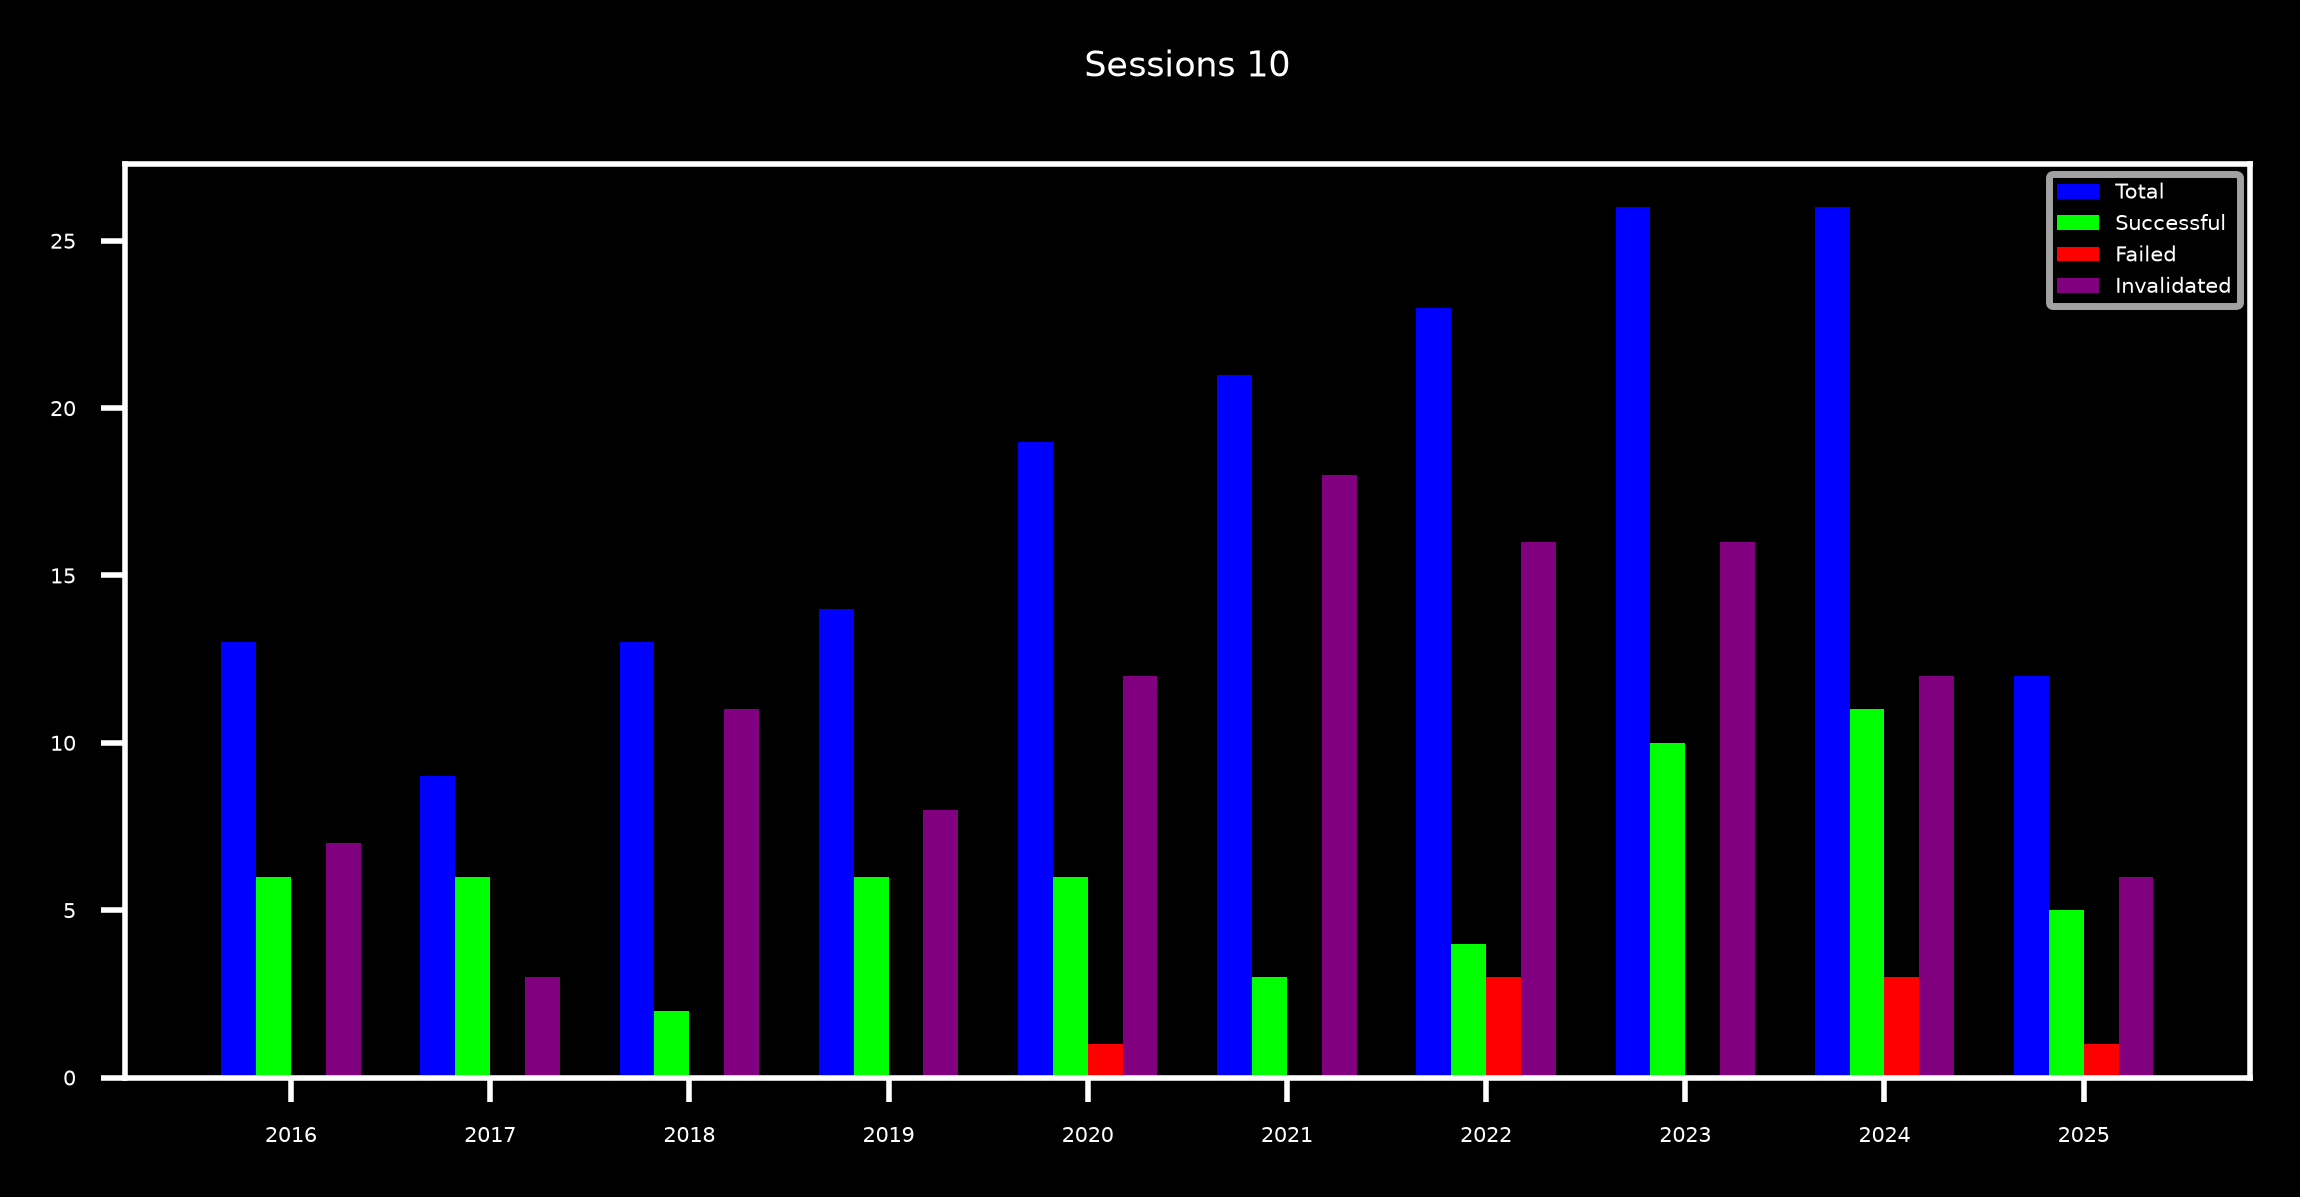

                                                         Sessions 11                                                          
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Interval ┃ Total ┃ Succ ┃ Fail ┃ Inv ┃ Succ% ┃ Fail% ┃ Inv% ┃ Chg%  ┃ MFE%  ┃  MAE%  ┃ Sharpe ┃ Sortino ┃ MaxDD%  ┃ p-val  ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│   2016   │  13   │  6   │  0   │  7  │  46   │   0   │  53  │  3.5  │ 6.01  │ -5.41  │  3.05  │  3.73   │ -6.56%  │ 0.5012 │
│   2017   │   9   │  6   │  0   │  3  │  66   │   0   │  33  │ 16.0  │ 19.97 │ -8.11  │ 27.27  │   0.0   │  0.0%   │ 0.0009 │
│   2018   │  13   │  2   │  0   │ 11  │  15   │   0   │  84  │ 4.33  │ 5.32  │ -15.44 │ -9.67  │  -7.27  │ -64.42% │ 0.0484 │
│   2019   │  14   │  6   │  0   │  8  │  42   │   0   │  57  │ 8.95  │ 10.12 │ -8.09  │  5.95  │  8.51   │ -19.12% │ 0.1844 │
│   2020   │  19   │  6   │  1   │ 12  │  31   │   5   │  63  │ 15.18 │ 9.81  │ -8.36  │  3.04  │  3.32   │ -36.76% │ 0.4142 │
│   2021   │  21   │  3   │  0   │ 18  │  14   │   0   │  85  │ 14.9  │ 10.4  │ -13.78 │ -1.33  │  -1.44  │ -47.35% │ 0.7048 │
│   2022   │  23   │  5   │  2   │ 16  │  21   │   8   │  69  │ 4.48  │ 6.78  │ -9.94  │ -6.41  │  -5.48  │ -55.68% │ 0.0656 │
│   2023   │  26   │  10  │  0   │ 16  │  38   │   0   │  61  │ 10.99 │ 9.35  │ -4.48  │  8.07  │  17.51  │ -15.39% │ 0.0157 │
│   2024   │  26   │  9   │  5   │ 12  │  34   │  19   │  46  │  7.2  │ 7.11  │ -5.97  │  3.11  │   5.0   │ -16.02% │ 0.3275 │
│   2025   │  11   │  4   │  1   │  6  │  36   │   9   │  54  │ 5.78  │ 5.63  │ -4.03  │  4.38  │  6.18   │ -13.82% │ 0.3813 │
├──────────┼───────┼──────┼──────┼─────┼───────┼───────┼──────┼───────┼───────┼────────┼────────┼─────────┼─────────┼────────┤
│   SUM    │  175  │  57  │  9   │ 109 │  32   │   5   │  62  │ 9.39  │ 8.68  │ -8.29  │  2.03  │  2.26   │ -79.77% │ 0.0924 │
└──────────┴───────┴──────┴──────┴─────┴───────┴───────┴──────┴───────┴───────┴────────┴────────┴─────────┴─────────┴────────┘

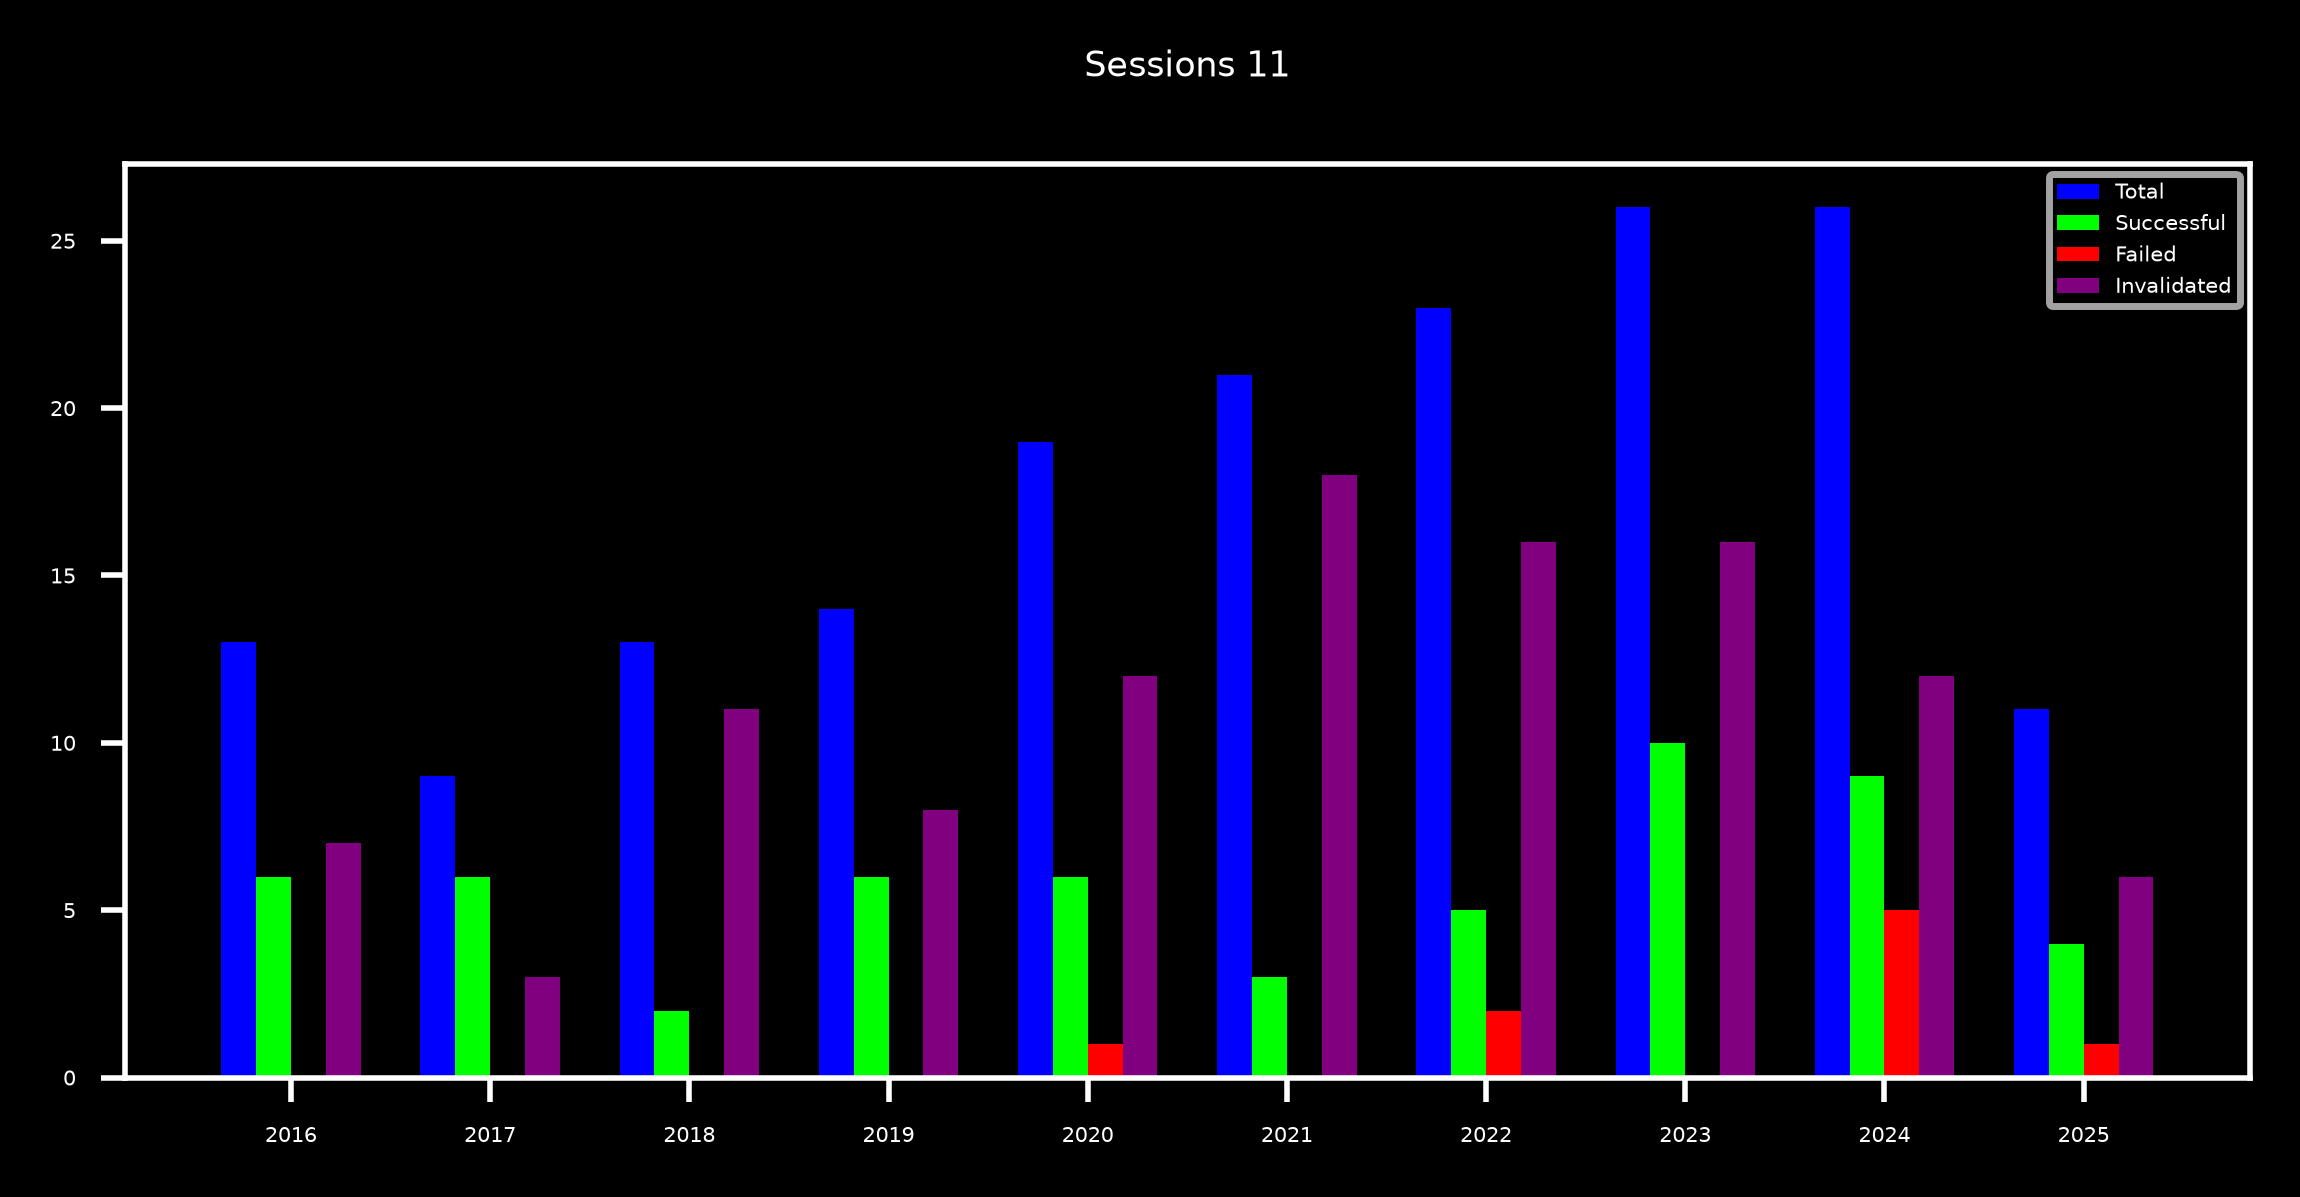

                                                         Sessions 12                                                          
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Interval ┃ Total ┃ Succ ┃ Fail ┃ Inv ┃ Succ% ┃ Fail% ┃ Inv% ┃ Chg%  ┃ MFE%  ┃  MAE%  ┃ Sharpe ┃ Sortino ┃ MaxDD%  ┃ p-val  ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│   2016   │  13   │  6   │  0   │  7  │  46   │   0   │  53  │ 4.15  │ 6.84  │ -5.41  │  3.93  │  5.07   │ -4.38%  │ 0.3891 │
│   2017   │   9   │  6   │  0   │  3  │  66   │   0   │  33  │ 17.67 │ 20.99 │ -8.11  │ 32.49  │   0.0   │  0.0%   │ 0.0003 │
│   2018   │  13   │  2   │  0   │ 11  │  15   │   0   │  84  │ 6.64  │ 5.52  │ -15.65 │ -8.79  │  -6.91  │ -61.52% │ 0.069  │
│   2019   │  14   │  6   │  0   │  8  │  42   │   0   │  57  │ 9.51  │ 11.92 │ -8.09  │  8.28  │  22.28  │ -8.37%  │ 0.0728 │
│   2020   │  19   │  6   │  1   │ 12  │  31   │   5   │  63  │ 15.05 │ 10.29 │ -8.36  │  2.79  │  3.16   │ -42.06% │ 0.4536 │
│   2021   │  21   │  3   │  0   │ 18  │  14   │   0   │  85  │ 15.56 │ 11.04 │ -14.33 │ -2.51  │  -2.51  │ -55.51% │ 0.4776 │
│   2022   │  23   │  4   │  3   │ 16  │  17   │  13   │  69  │ 5.94  │ 6.82  │ -9.95  │ -6.41  │  -5.43  │ -58.99% │ 0.0659 │
│   2023   │  26   │  10  │  0   │ 16  │  38   │   0   │  61  │ 10.49 │ 9.73  │ -4.56  │  7.77  │  19.09  │ -17.18% │ 0.0196 │
│   2024   │  26   │  11  │  3   │ 12  │  42   │  11   │  46  │ 6.56  │ 7.26  │ -6.13  │  3.11  │  5.01   │ -23.3%  │ 0.3269 │
│   2025   │  11   │  2   │  2   │  7  │  18   │  18   │  63  │ 6.79  │ 6.11  │ -4.82  │  2.75  │  4.04   │ -12.47% │ 0.5777 │
├──────────┼───────┼──────┼──────┼─────┼───────┼───────┼──────┼───────┼───────┼────────┼────────┼─────────┼─────────┼────────┤
│   SUM    │  175  │  56  │  9   │ 110 │  32   │   5   │  62  │ 9.87  │  9.2  │ -8.46  │  2.08  │  2.34   │ -82.75% │ 0.0841 │
└──────────┴───────┴──────┴──────┴─────┴───────┴───────┴──────┴───────┴───────┴────────┴────────┴─────────┴─────────┴────────┘

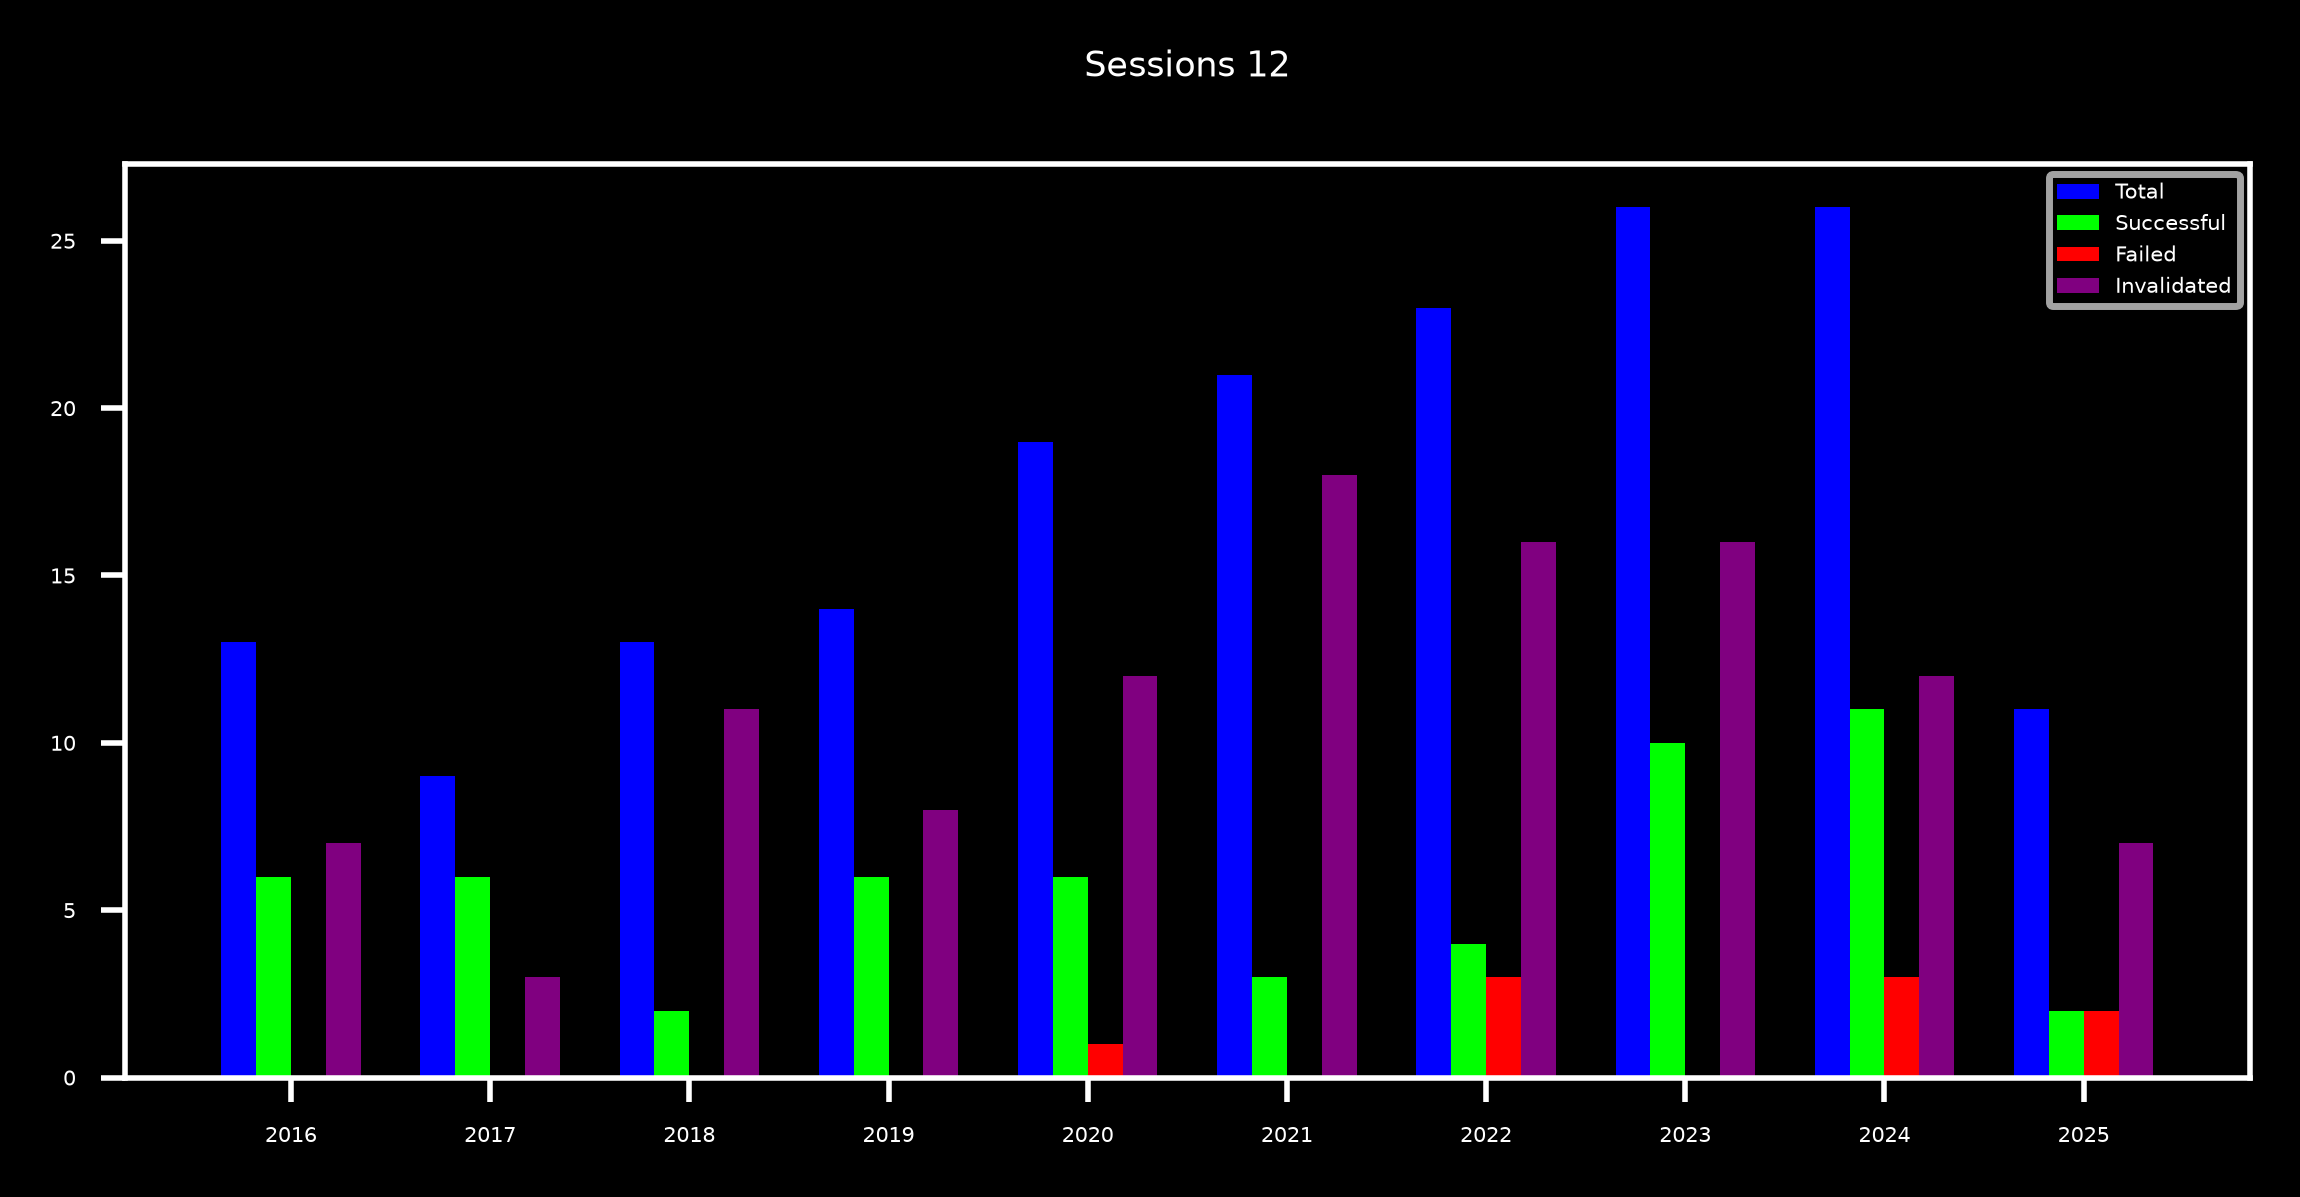

                                                         Sessions 13                                                          
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Interval ┃ Total ┃ Succ ┃ Fail ┃ Inv ┃ Succ% ┃ Fail% ┃ Inv% ┃ Chg%  ┃ MFE%  ┃  MAE%  ┃ Sharpe ┃ Sortino ┃ MaxDD%  ┃ p-val  ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│   2016   │  13   │  6   │  0   │  7  │  46   │   0   │  53  │ 3.48  │ 7.02  │ -5.41  │  5.44  │  9.22   │ -6.15%  │ 0.2402 │
│   2017   │   9   │  6   │  0   │  3  │  66   │   0   │  33  │ 18.37 │ 21.92 │ -8.11  │ 29.04  │   0.0   │  0.0%   │ 0.0006 │
│   2018   │  13   │  2   │  0   │ 11  │  15   │   0   │  84  │ 6.78  │ 5.82  │ -16.42 │ -8.95  │  -6.17  │ -63.22% │ 0.0648 │
│   2019   │  14   │  6   │  0   │  8  │  42   │   0   │  57  │ 10.85 │ 12.77 │ -8.09  │  8.88  │  24.53  │ -8.21%  │ 0.0565 │
│   2020   │  19   │  6   │  1   │ 12  │  31   │   5   │  63  │ 16.2  │ 11.37 │ -8.36  │  3.42  │  3.44   │ -40.04% │ 0.3603 │
│   2021   │  21   │  3   │  0   │ 18  │  14   │   0   │  85  │ 14.37 │ 11.92 │ -14.68 │ -0.51  │  -0.55  │ -45.05% │ 0.8842 │
│   2022   │  23   │  4   │  3   │ 16  │  17   │  13   │  69  │ 5.34  │ 6.83  │ -10.08 │  -5.9  │  -4.9   │ -57.77% │ 0.0885 │
│   2023   │  26   │  9   │  1   │ 16  │  34   │   3   │  61  │ 11.36 │ 10.14 │ -4.57  │  8.06  │  21.49  │ -17.73% │ 0.0158 │
│   2024   │  26   │  10  │  3   │ 13  │  38   │  11   │  50  │ 9.12  │ 7.96  │  -6.4  │  3.54  │  6.02   │ -27.42% │ 0.2665 │
│   2025   │  11   │  3   │  1   │  7  │  27   │   9   │  63  │ 4.21  │ 6.11  │ -5.45  │ -1.12  │  -1.19  │ -18.52% │ 0.8197 │
├──────────┼───────┼──────┼──────┼─────┼───────┼───────┼──────┼───────┼───────┼────────┼────────┼─────────┼─────────┼────────┤
│   SUM    │  175  │  55  │  9   │ 111 │  31   │   5   │  63  │ 10.5  │ 9.74  │ -8.65  │  2.57  │  2.92   │ -78.56% │ 0.0337 │
└──────────┴───────┴──────┴──────┴─────┴───────┴───────┴──────┴───────┴───────┴────────┴────────┴─────────┴─────────┴────────┘

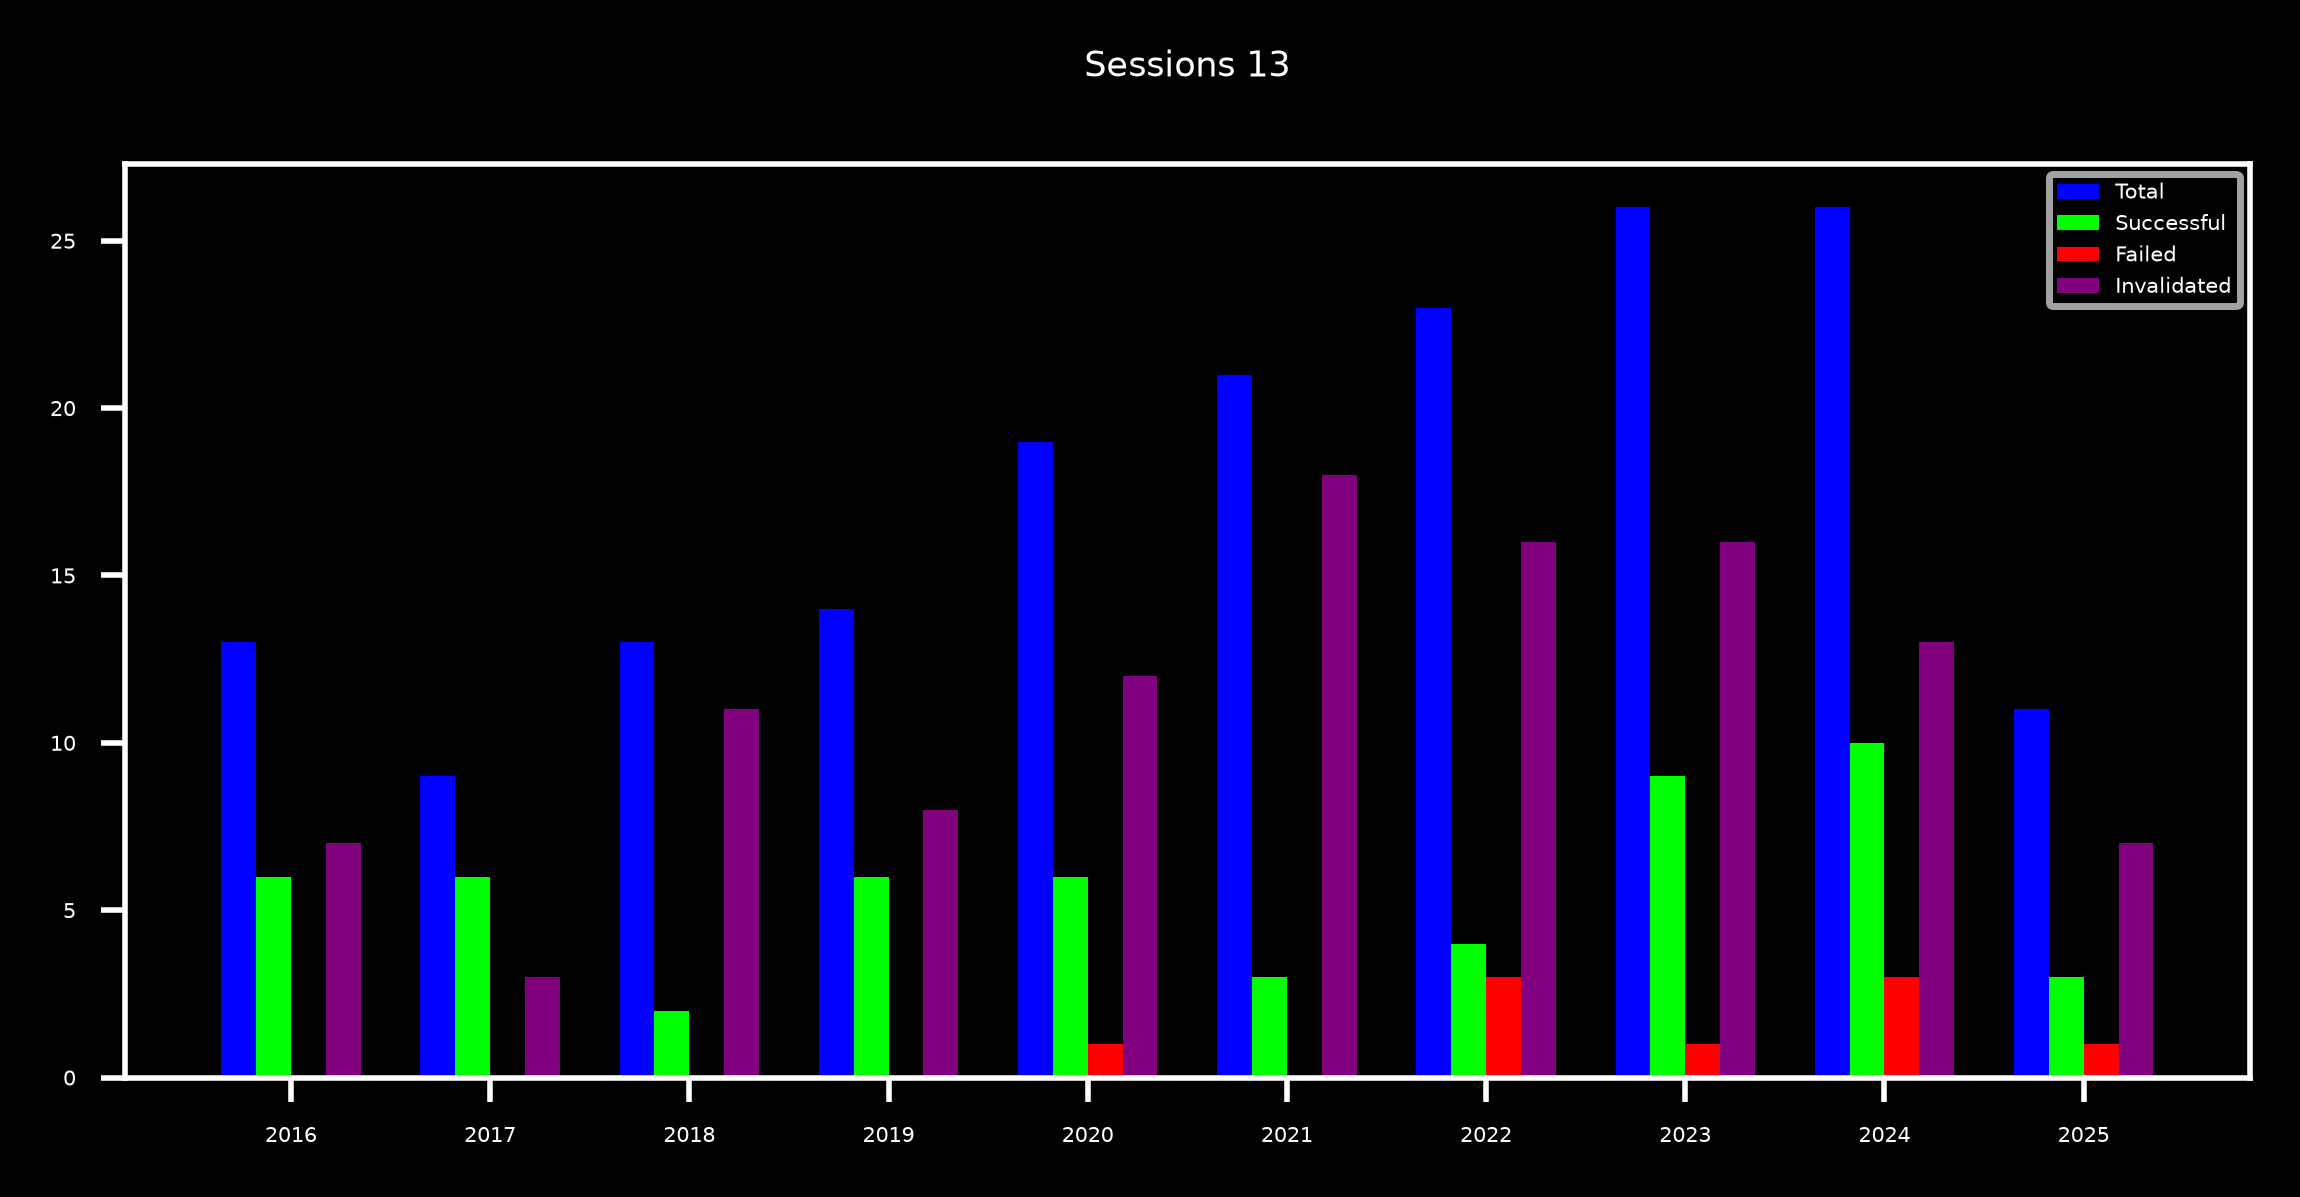

                                                         Sessions 14                                                          
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Interval ┃ Total ┃ Succ ┃ Fail ┃ Inv ┃ Succ% ┃ Fail% ┃ Inv% ┃ Chg%  ┃ MFE%  ┃  MAE%  ┃ Sharpe ┃ Sortino ┃ MaxDD%  ┃ p-val  ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│   2016   │  13   │  6   │  0   │  7  │  46   │   0   │  53  │ 3.66  │ 7.29  │ -5.68  │  4.93  │  7.07   │ -9.42%  │ 0.285  │
│   2017   │   9   │  6   │  0   │  3  │  66   │   0   │  33  │ 20.93 │ 23.88 │ -8.11  │ 27.67  │   0.0   │  0.0%   │ 0.0008 │
│   2018   │  13   │  2   │  0   │ 11  │  15   │   0   │  84  │ 6.19  │ 5.91  │ -18.1  │ -9.73  │  -6.91  │ -61.53% │ 0.0474 │
│   2019   │  14   │  6   │  0   │  8  │  42   │   0   │  57  │ 13.88 │ 14.86 │ -8.09  │  8.43  │  44.47  │ -4.24%  │ 0.0685 │
│   2020   │  19   │  6   │  1   │ 12  │  31   │   5   │  63  │ 16.52 │ 11.96 │ -8.44  │  3.44  │  3.38   │ -43.49% │ 0.3573 │
│   2021   │  21   │  3   │  0   │ 18  │  14   │   0   │  85  │ 13.73 │ 12.39 │ -15.69 │ -0.61  │  -0.65  │ -49.78% │ 0.8618 │
│   2022   │  23   │  4   │  3   │ 16  │  17   │  13   │  69  │ 7.31  │ 7.21  │ -10.37 │ -5.03  │  -4.41  │ -64.15% │ 0.1429 │
│   2023   │  26   │  8   │  2   │ 16  │  30   │   7   │  61  │ 12.9  │ 10.7  │ -4.65  │  7.65  │  23.22  │ -15.38% │ 0.0212 │
│   2024   │  26   │  10  │  3   │ 13  │  38   │  11   │  50  │ 11.09 │  8.7  │ -6.66  │  3.46  │  5.69   │ -37.58% │ 0.2768 │
│   2025   │  11   │  2   │  2   │  7  │  18   │  18   │  63  │ 4.74  │ 6.18  │ -5.96  │ -2.22  │  -2.11  │ -16.67% │ 0.6525 │
├──────────┼───────┼──────┼──────┼─────┼───────┼───────┼──────┼───────┼───────┼────────┼────────┼─────────┼─────────┼────────┤
│   SUM    │  175  │  53  │  11  │ 111 │  30   │   6   │  63  │ 12.01 │ 10.4  │ -9.05  │  2.6   │  3.03   │ -78.92% │ 0.0317 │
└──────────┴───────┴──────┴──────┴─────┴───────┴───────┴──────┴───────┴───────┴────────┴────────┴─────────┴─────────┴────────┘

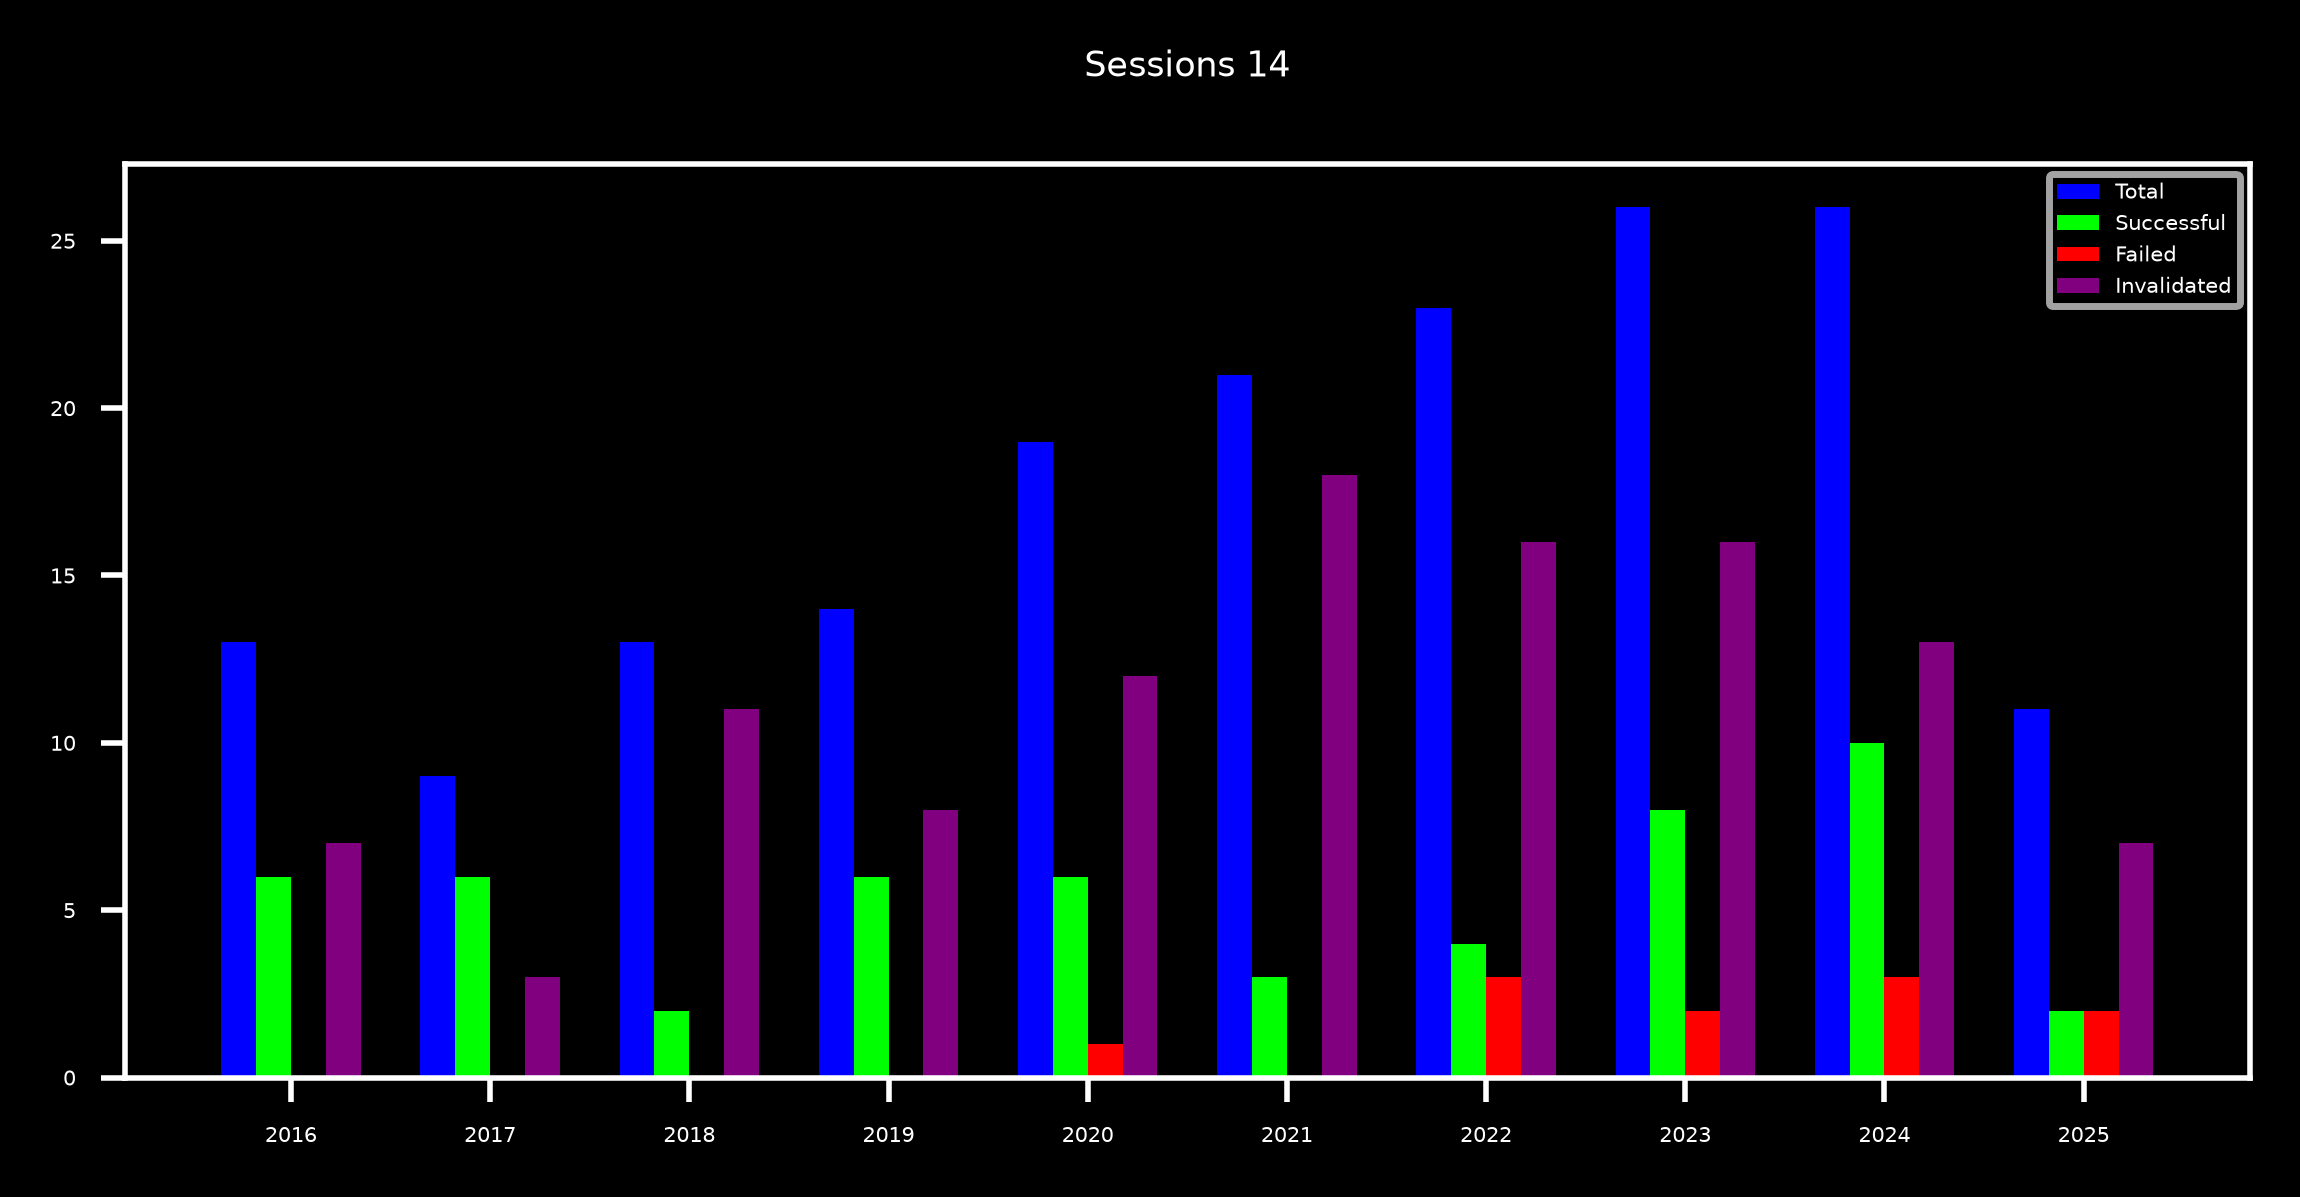

                                                         Sessions 15                                                          
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Interval ┃ Total ┃ Succ ┃ Fail ┃ Inv ┃ Succ% ┃ Fail% ┃ Inv% ┃ Chg%  ┃ MFE%  ┃  MAE%  ┃ Sharpe ┃ Sortino ┃ MaxDD%  ┃ p-val  ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│   2016   │  13   │  6   │  0   │  7  │  46   │   0   │  53  │ 3.65  │ 8.28  │ -5.94  │  3.72  │   5.1   │ -11.79% │ 0.4141 │
│   2017   │   9   │  5   │  0   │  4  │  55   │   0   │  44  │ 28.17 │ 26.37 │ -19.04 │ 23.53  │  75.77  │  0.0%   │ 0.0021 │
│   2018   │  13   │  2   │  0   │ 11  │  15   │   0   │  84  │ 6.07  │ 5.96  │ -18.59 │ -11.59 │  -8.59  │ -70.63% │ 0.0219 │
│   2019   │  14   │  5   │  1   │  8  │  35   │   7   │  57  │ 11.96 │ 15.31 │ -8.09  │  9.31  │  25.59  │ -5.76%  │ 0.047  │
│   2020   │  19   │  7   │  0   │ 12  │  36   │   0   │  63  │ 12.42 │ 12.09 │ -8.48  │  3.66  │  3.38   │ -40.19% │ 0.3286 │
│   2021   │  21   │  3   │  0   │ 18  │  14   │   0   │  85  │ 16.82 │ 12.55 │ -15.86 │ -0.04  │  -0.05  │ -45.35% │  0.99  │
│   2022   │  23   │  4   │  2   │ 17  │  17   │   8   │  73  │ 6.29  │ 7.45  │ -10.73 │  -6.0  │  -5.23  │ -61.09% │ 0.0834 │
│   2023   │  26   │  9   │  0   │ 17  │  34   │   0   │  65  │ 13.14 │ 10.88 │ -4.72  │  8.34  │  23.52  │ -14.08% │ 0.0128 │
│   2024   │  26   │  12  │  1   │ 13  │  46   │   3   │  50  │ 9.62  │ 9.02  │ -7.09  │  3.34  │   4.6   │ -34.68% │ 0.2934 │
│   2025   │  11   │  1   │  2   │  8  │   9   │  18   │  72  │ 9.54  │ 6.18  │ -6.26  │ -3.49  │  -3.56  │ -22.9%  │ 0.4827 │
├──────────┼───────┼──────┼──────┼─────┼───────┼───────┼──────┼───────┼───────┼────────┼────────┼─────────┼─────────┼────────┤
│   SUM    │  175  │  54  │  6   │ 115 │  30   │   3   │  65  │ 11.86 │ 10.78 │ -9.83  │  2.56  │  3.02   │ -79.05% │ 0.0342 │
└──────────┴───────┴──────┴──────┴─────┴───────┴───────┴──────┴───────┴───────┴────────┴────────┴─────────┴─────────┴────────┘

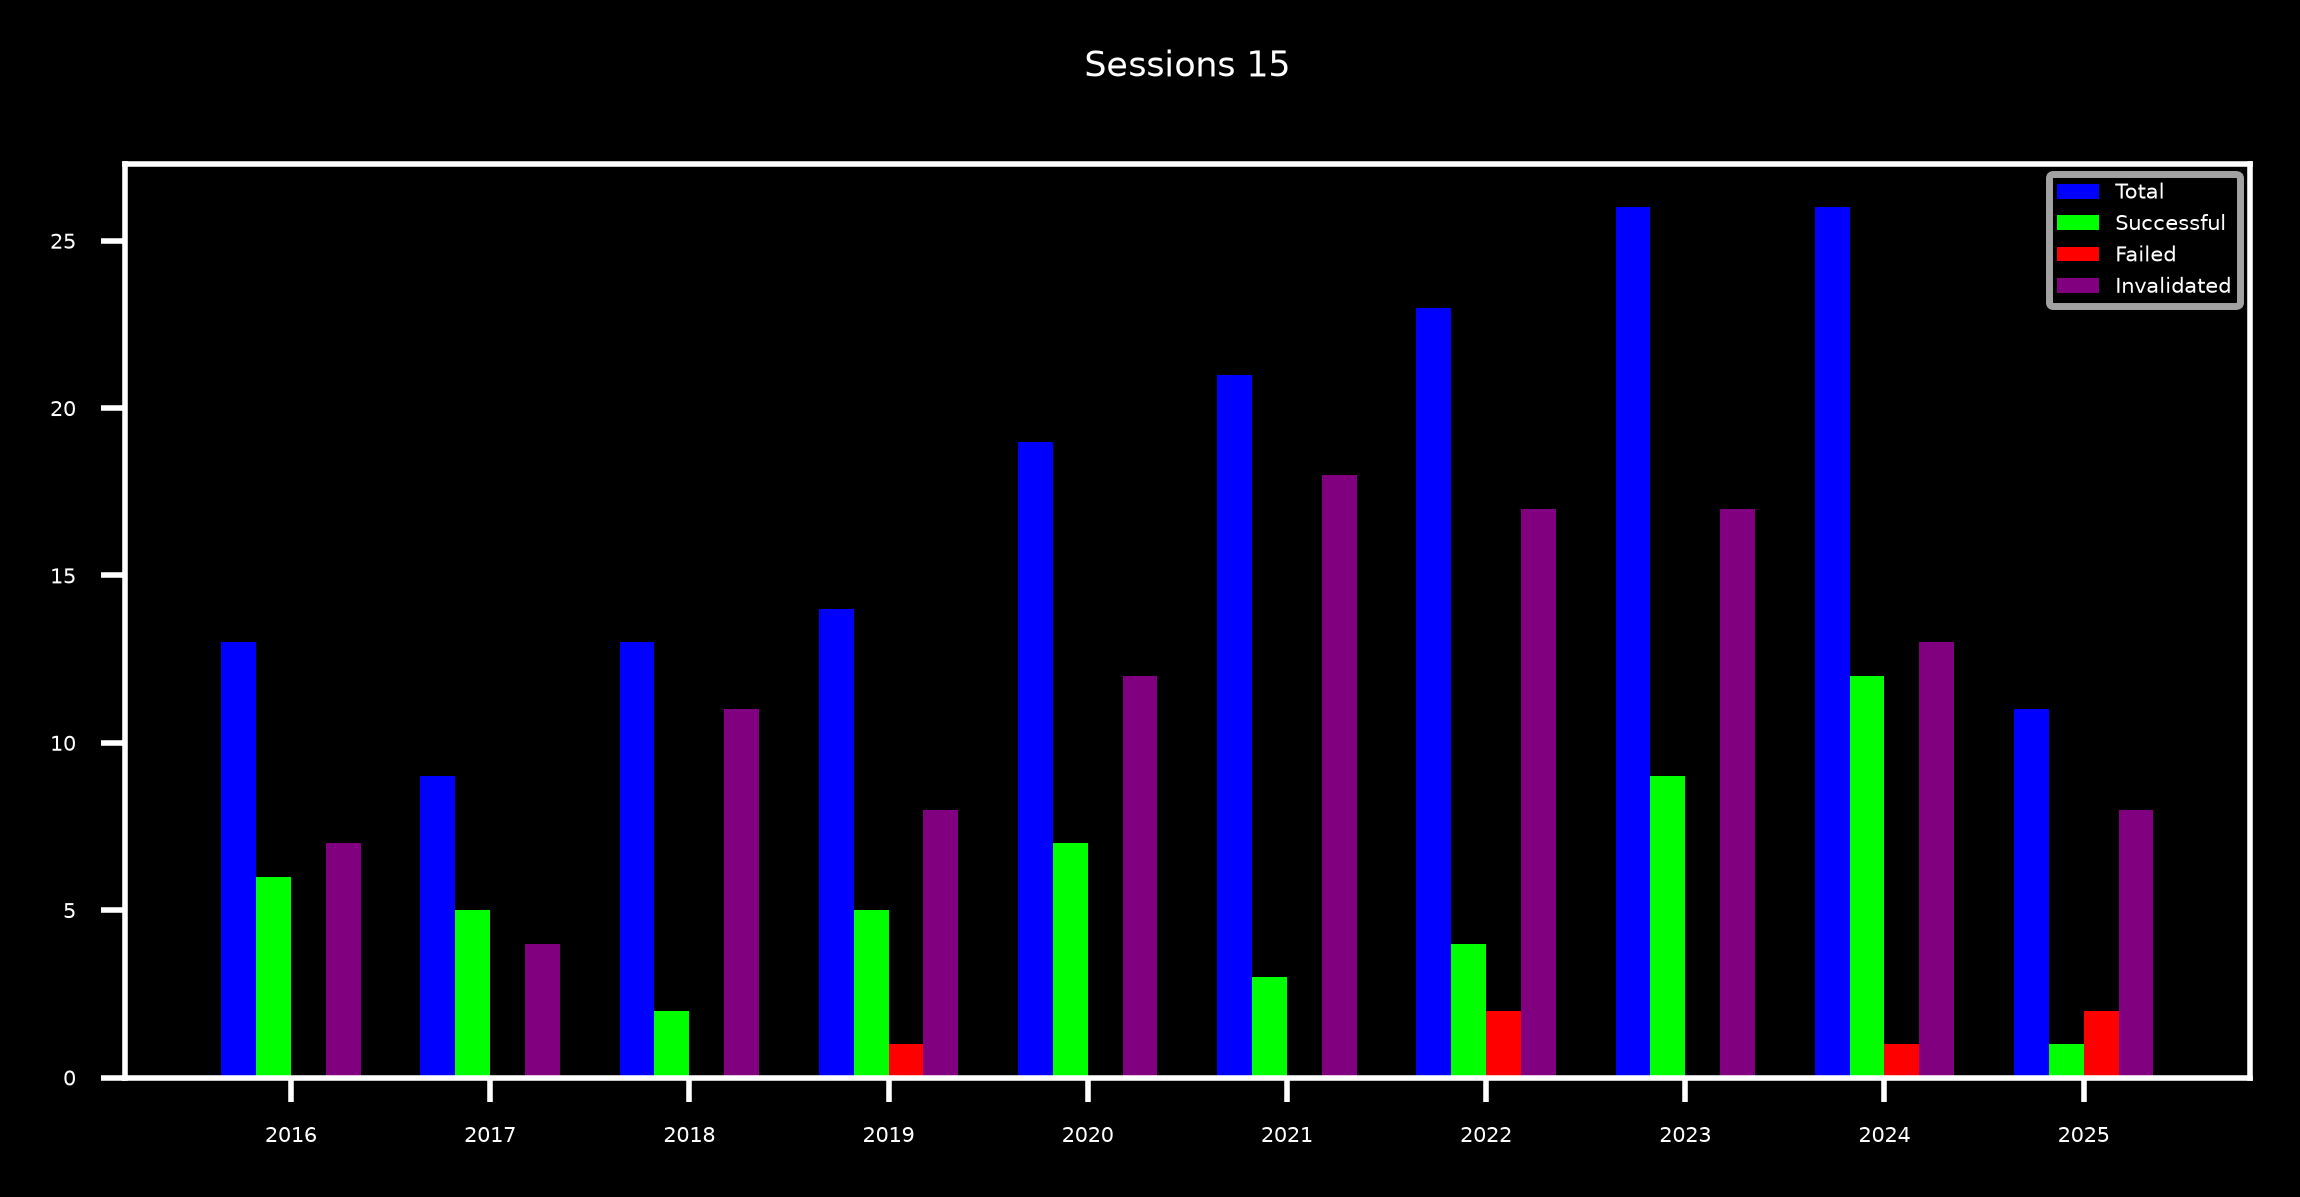

                                                         Sessions 16                                                          
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Interval ┃ Total ┃ Succ ┃ Fail ┃ Inv ┃ Succ% ┃ Fail% ┃ Inv% ┃ Chg%  ┃ MFE%  ┃  MAE%  ┃ Sharpe ┃ Sortino ┃ MaxDD%  ┃ p-val  ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│   2016   │  13   │  6   │  0   │  7  │  46   │   0   │  53  │ 3.61  │ 8.29  │ -7.25  │  2.41  │  2.58   │ -21.8%  │ 0.5938 │
│   2017   │   9   │  5   │  0   │  4  │  55   │   0   │  44  │ 32.69 │ 29.28 │ -19.04 │ 20.75  │  27.31  │  0.0%   │ 0.0044 │
│   2018   │  13   │  2   │  0   │ 11  │  15   │   0   │  84  │ 7.13  │ 5.96  │ -18.59 │ -11.46 │  -8.58  │ -69.0%  │ 0.0231 │
│   2019   │  14   │  4   │  2   │  8  │  28   │  14   │  57  │ 15.34 │ 15.97 │ -8.13  │  6.74  │  18.26  │ -8.14%  │ 0.1363 │
│   2020   │  19   │  7   │  0   │ 12  │  36   │   0   │  63  │ 16.32 │ 12.38 │ -8.48  │  4.63  │  4.84   │ -39.27% │ 0.2195 │
│   2021   │  21   │  3   │  0   │ 18  │  14   │   0   │  85  │ 20.34 │ 12.92 │ -16.2  │  0.51  │   0.7   │ -54.19% │ 0.8845 │
│   2022   │  23   │  4   │  2   │ 17  │  17   │   8   │  73  │ 7.01  │ 7.59  │ -10.79 │ -4.99  │  -4.36  │ -61.51% │ 0.1459 │
│   2023   │  26   │  9   │  0   │ 17  │  34   │   0   │  65  │ 12.37 │ 11.11 │ -5.23  │  7.77  │  16.38  │ -21.84% │ 0.0195 │
│   2024   │  26   │  10  │  3   │ 13  │  38   │  11   │  50  │ 12.79 │ 9.41  │ -7.33  │  3.44  │  5.51   │ -36.4%  │ 0.2799 │
│   2025   │  11   │  1   │  1   │  9  │   9   │   9   │  81  │ 8.39  │ 6.18  │  -6.8  │ -4.29  │  -4.21  │ -19.66% │ 0.3907 │
├──────────┼───────┼──────┼──────┼─────┼───────┼───────┼──────┼───────┼───────┼────────┼────────┼─────────┼─────────┼────────┤
│   SUM    │  175  │  51  │  8   │ 116 │  29   │   4   │  66  │ 13.95 │ 11.17 │ -10.13 │  2.61  │  3.34   │ -78.5%  │ 0.0308 │
└──────────┴───────┴──────┴──────┴─────┴───────┴───────┴──────┴───────┴───────┴────────┴────────┴─────────┴─────────┴────────┘

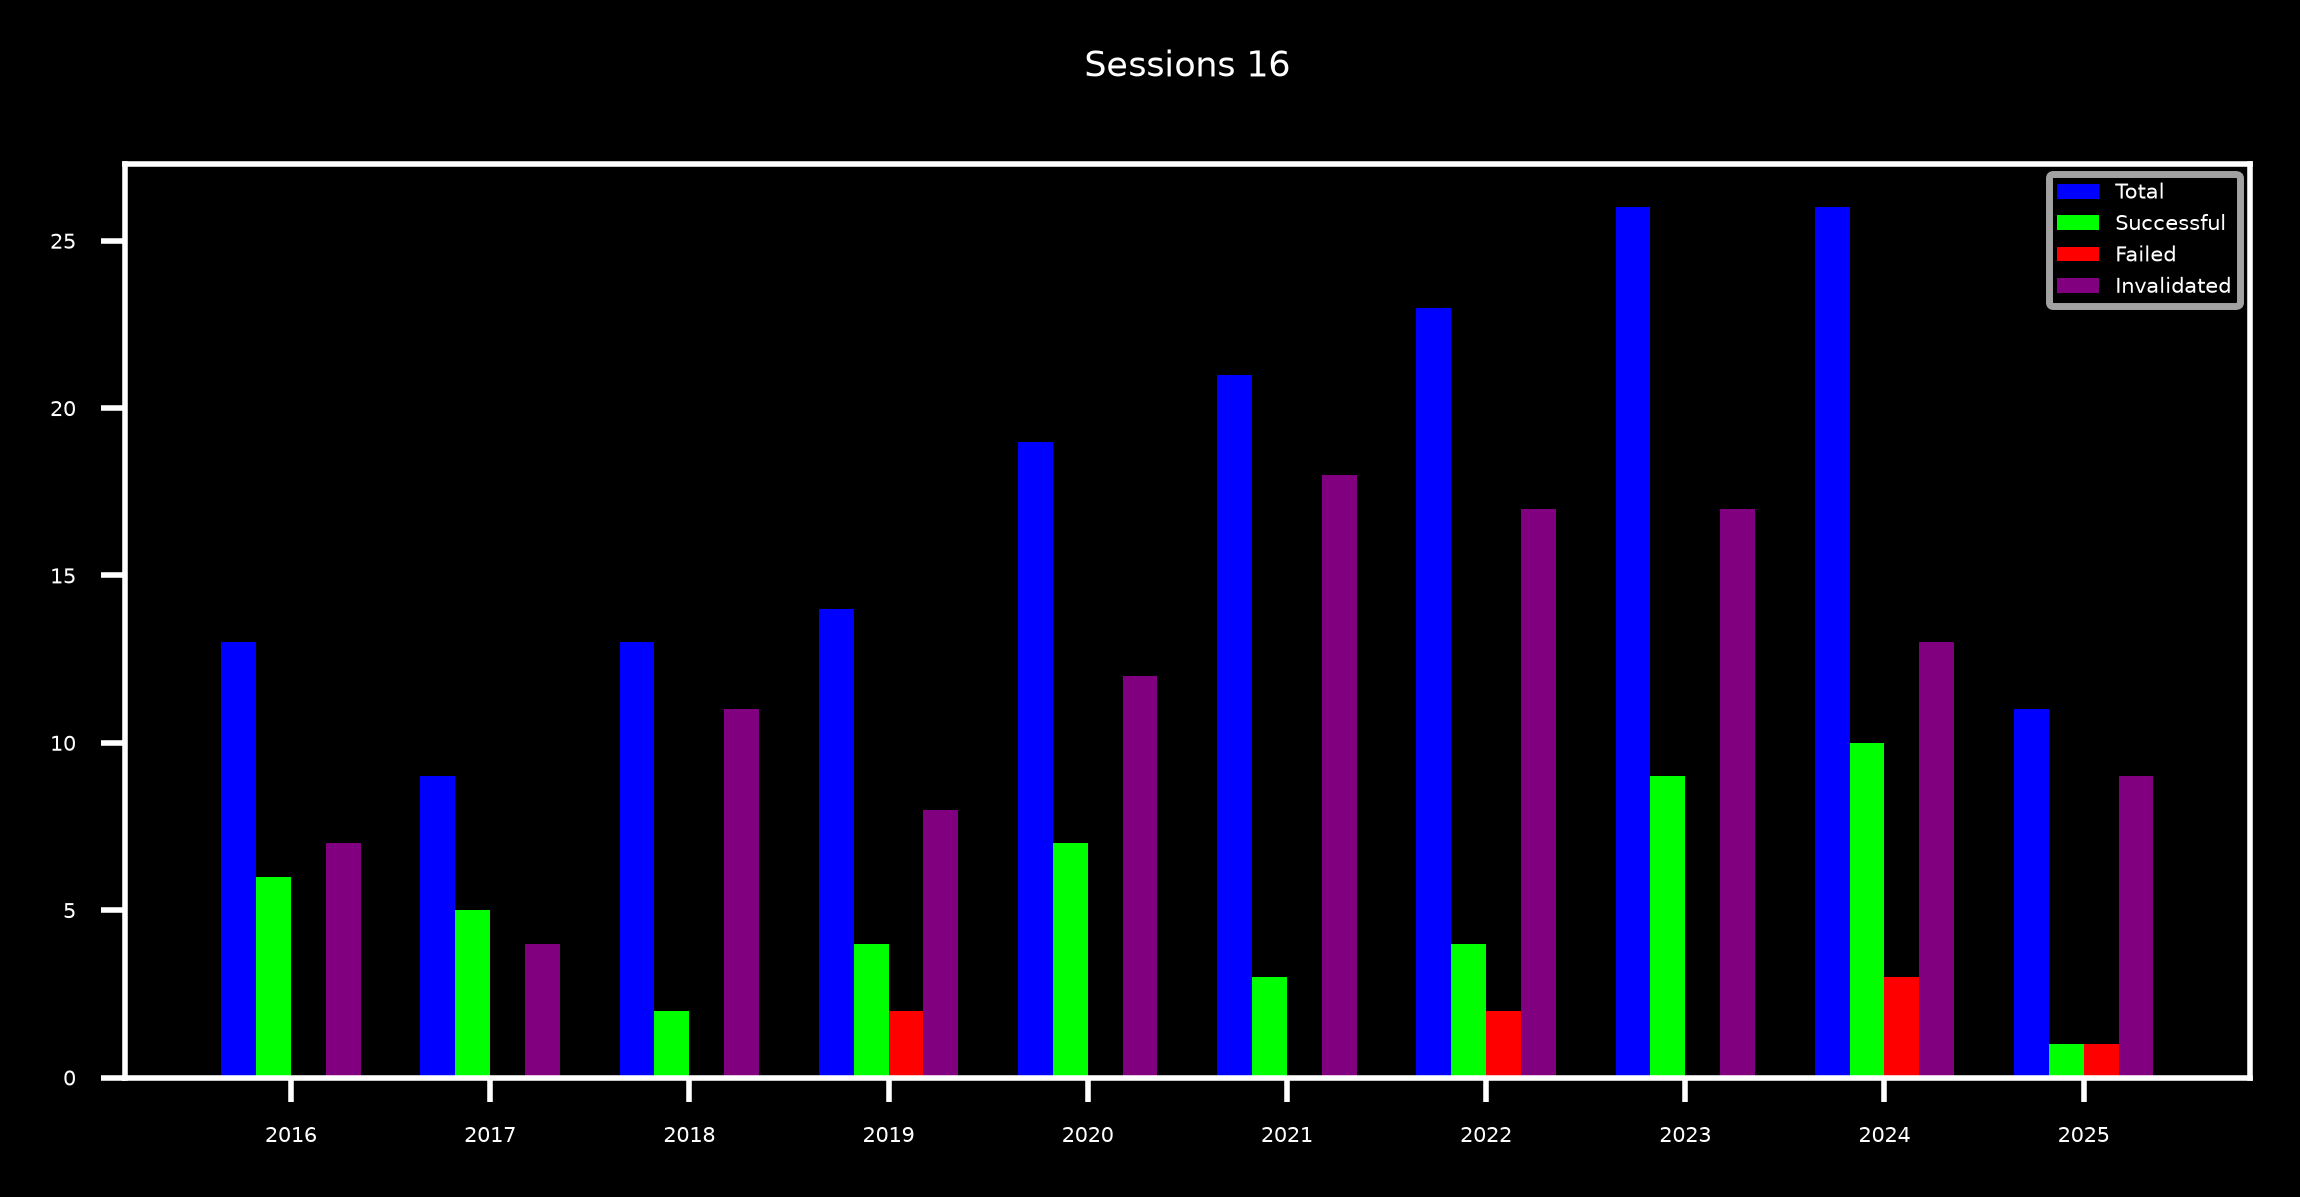

                                                         Sessions 17                                                          
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Interval ┃ Total ┃ Succ ┃ Fail ┃ Inv ┃ Succ% ┃ Fail% ┃ Inv% ┃ Chg%  ┃ MFE%  ┃  MAE%  ┃ Sharpe ┃ Sortino ┃ MaxDD%  ┃ p-val  ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│   2016   │  13   │  5   │  1   │  7  │  38   │   7   │  53  │ 5.19  │ 8.52  │ -7.25  │  3.83  │  5.13   │ -15.68% │ 0.4009 │
│   2017   │   9   │  5   │  0   │  4  │  55   │   0   │  44  │ 36.32 │ 32.01 │ -19.38 │ 17.63  │  17.93  │  0.0%   │ 0.0104 │
│   2018   │  13   │  2   │  0   │ 11  │  15   │   0   │  84  │ 11.6  │ 6.14  │ -19.04 │ -11.53 │  -8.74  │ -73.03% │ 0.0224 │
│   2019   │  14   │  5   │  1   │  8  │  35   │   7   │  57  │ 11.7  │ 16.45 │ -8.13  │  7.17  │  12.15  │ -12.44% │ 0.1147 │
│   2020   │  19   │  7   │  0   │ 12  │  36   │   0   │  63  │ 18.37 │ 13.08 │ -8.48  │  6.06  │  7.25   │ -30.61% │ 0.1136 │
│   2021   │  21   │  3   │  0   │ 18  │  14   │   0   │  85  │ 21.23 │ 13.2  │ -16.22 │  1.21  │  1.73   │ -52.54% │ 0.7315 │
│   2022   │  23   │  3   │  3   │ 17  │  13   │  13   │  73  │ 7.37  │ 7.82  │ -11.08 │ -5.92  │  -5.42  │ -60.84% │ 0.0875 │
│   2023   │  26   │  8   │  0   │ 18  │  30   │   0   │  69  │ 12.96 │ 11.22 │  -5.7  │  5.58  │  10.1   │ -24.22% │ 0.0851 │
│   2024   │  26   │  12  │  1   │ 13  │  46   │   3   │  50  │ 10.94 │ 9.86  │  -7.9  │  3.4   │  4.79   │ -39.6%  │ 0.2851 │
│   2025   │  11   │  1   │  1   │  9  │   9   │   9   │  81  │ 8.29  │ 6.18  │ -7.33  │ -4.38  │  -4.63  │ -23.35% │ 0.3818 │
├──────────┼───────┼──────┼──────┼─────┼───────┼───────┼──────┼───────┼───────┼────────┼────────┼─────────┼─────────┼────────┤
│   SUM    │  175  │  51  │  7   │ 117 │  29   │   4   │  66  │ 14.64 │ 11.6  │ -10.41 │  2.63  │  3.47   │ -79.02% │ 0.0299 │
└──────────┴───────┴──────┴──────┴─────┴───────┴───────┴──────┴───────┴───────┴────────┴────────┴─────────┴─────────┴────────┘

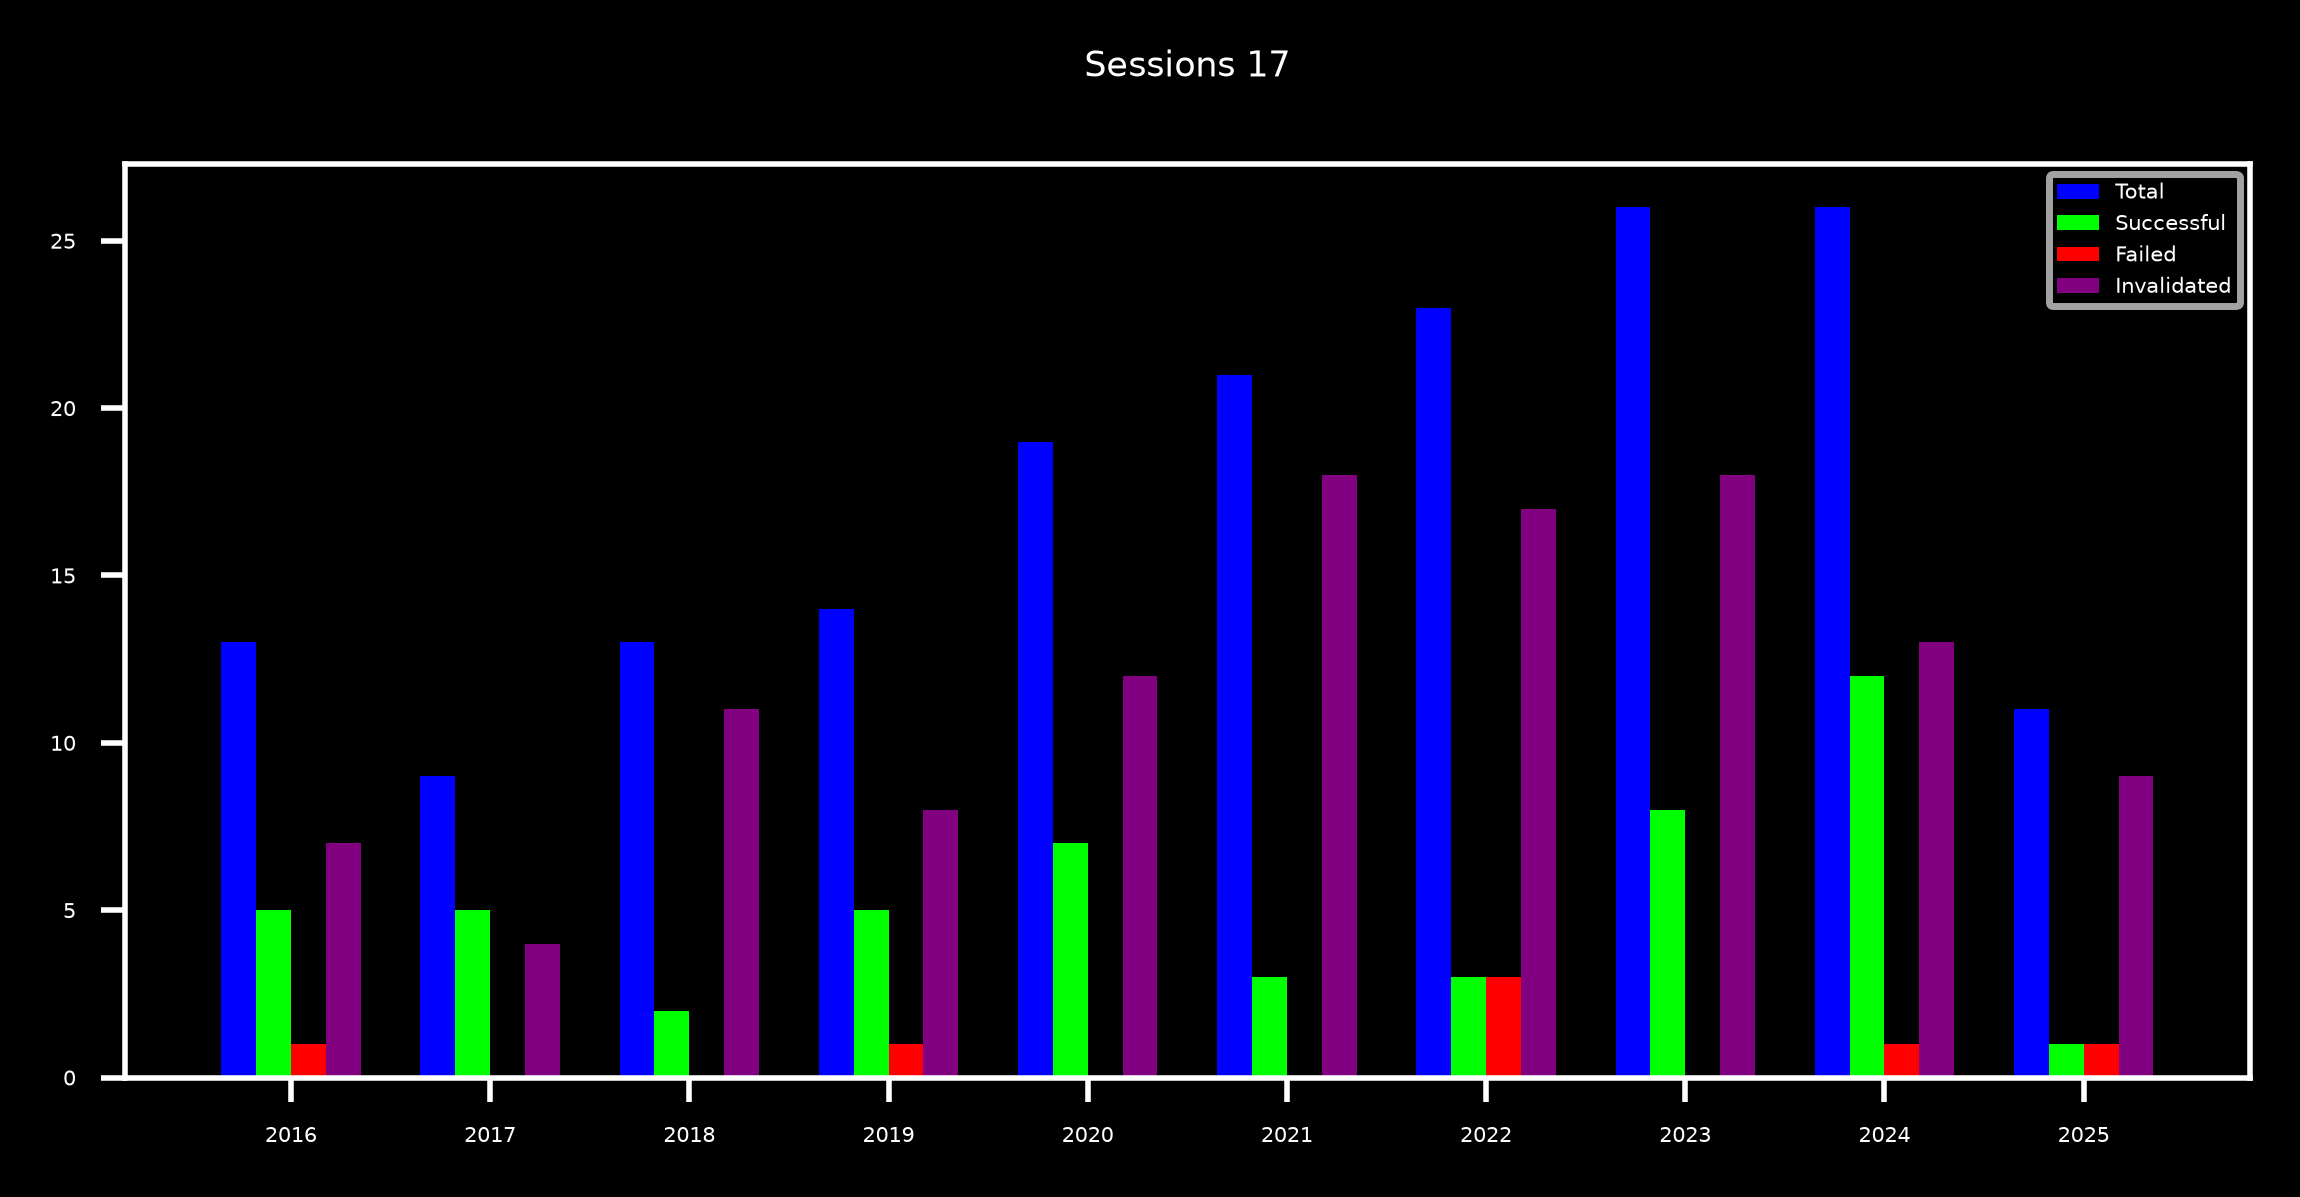

                                                         Sessions 18                                                          
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Interval ┃ Total ┃ Succ ┃ Fail ┃ Inv ┃ Succ% ┃ Fail% ┃ Inv% ┃ Chg%  ┃ MFE%  ┃  MAE%  ┃ Sharpe ┃ Sortino ┃ MaxDD%  ┃ p-val  ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│   2016   │  13   │  5   │  0   │  8  │  38   │   0   │  61  │ 5.96  │ 8.87  │ -7.71  │  3.96  │  5.42   │ -13.6%  │ 0.3863 │
│   2017   │   9   │  5   │  0   │  4  │  55   │   0   │  44  │ 38.31 │ 33.71 │ -19.38 │ 18.11  │  23.86  │  0.0%   │ 0.0091 │
│   2018   │  13   │  2   │  0   │ 11  │  15   │   0   │  84  │ 17.15 │ 6.99  │ -19.81 │ -9.02  │  -8.14  │ -68.64% │ 0.063  │
│   2019   │  14   │  5   │  1   │  8  │  35   │   7   │  57  │ 9.68  │ 16.45 │ -8.13  │  8.7   │  11.0   │ -13.04% │ 0.0611 │
│   2020   │  19   │  7   │  0   │ 12  │  36   │   0   │  63  │ 15.86 │ 13.16 │ -8.48  │  5.44  │  6.63   │ -30.39% │ 0.1522 │
│   2021   │  21   │  3   │  0   │ 18  │  14   │   0   │  85  │ 22.93 │ 13.56 │ -16.3  │  1.06  │  1.33   │ -57.15% │ 0.7637 │
│   2022   │  23   │  5   │  1   │ 17  │  21   │   4   │  73  │  5.8  │ 7.84  │ -11.12 │ -5.12  │  -4.32  │ -56.49% │ 0.1363 │
│   2023   │  26   │  8   │  0   │ 18  │  30   │   0   │  69  │ 14.19 │ 11.54 │ -5.82  │  6.68  │  12.04  │ -22.94% │ 0.0419 │
│   2024   │  26   │  11  │  2   │ 13  │  42   │   7   │  50  │ 13.84 │ 10.43 │ -7.95  │  4.43  │  7.53   │ -36.03% │ 0.1671 │
│   2025   │  11   │  2   │  0   │  9  │  18   │   0   │  81  │ 4.58  │ 6.18  │ -7.34  │ -3.37  │  -3.61  │ -22.57% │ 0.4979 │
├──────────┼───────┼──────┼──────┼─────┼───────┼───────┼──────┼───────┼───────┼────────┼────────┼─────────┼─────────┼────────┤
│   SUM    │  175  │  53  │  4   │ 118 │  30   │   2   │  67  │ 14.86 │ 11.97 │ -10.54 │  3.15  │  4.18   │ -78.13% │ 0.0094 │
└──────────┴───────┴──────┴──────┴─────┴───────┴───────┴──────┴───────┴───────┴────────┴────────┴─────────┴─────────┴────────┘

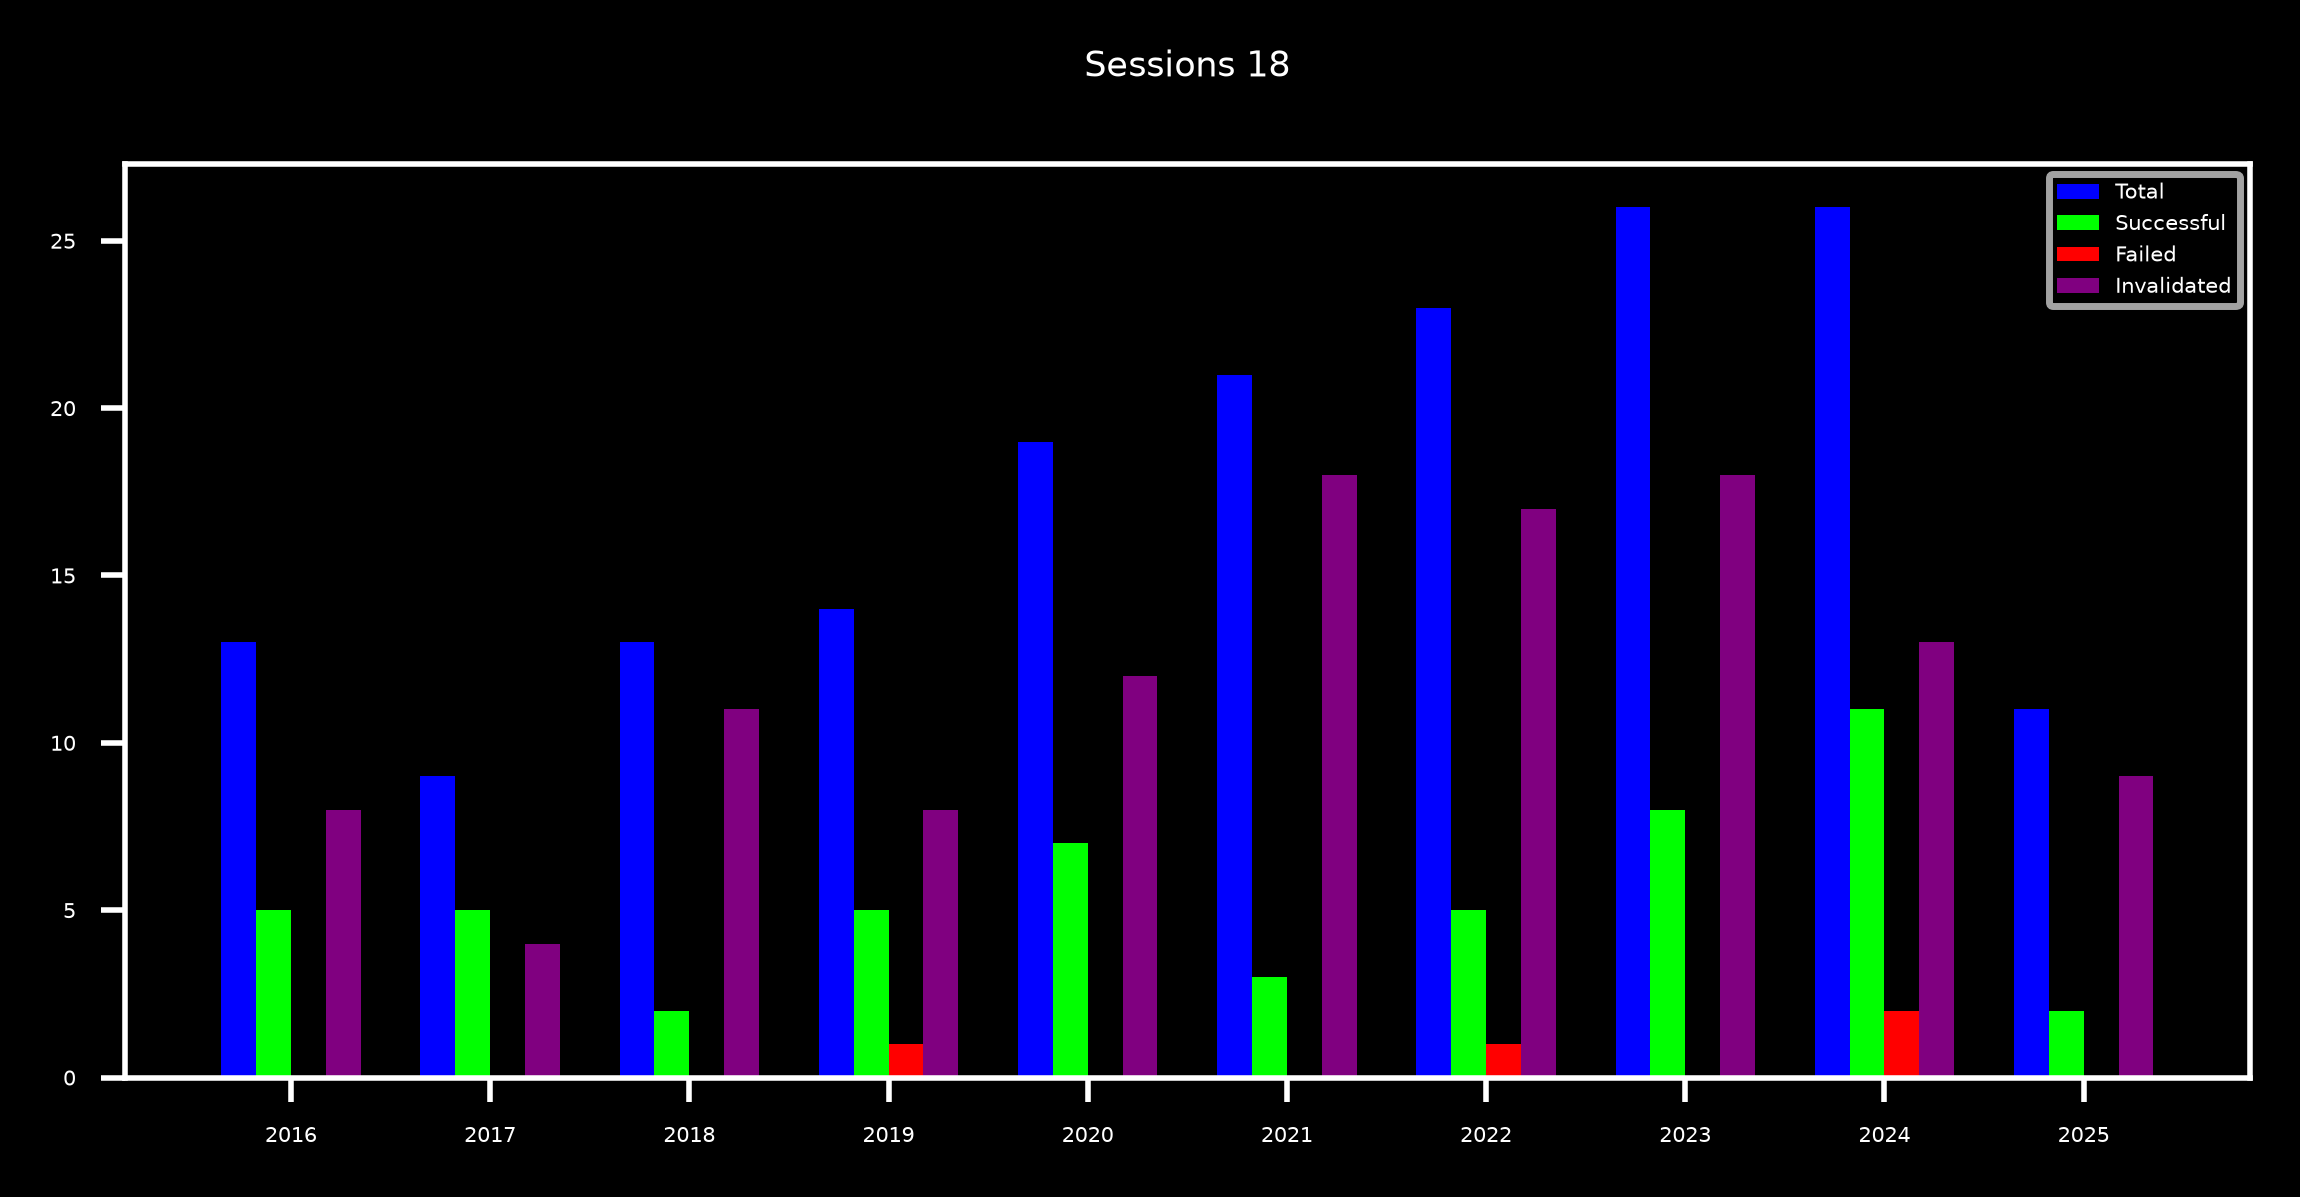

                                                         Sessions 19                                                          
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Interval ┃ Total ┃ Succ ┃ Fail ┃ Inv ┃ Succ% ┃ Fail% ┃ Inv% ┃ Chg%  ┃ MFE%  ┃  MAE%  ┃ Sharpe ┃ Sortino ┃ MaxDD%  ┃ p-val  ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│   2016   │  13   │  5   │  0   │  8  │  38   │   0   │  61  │ 6.24  │ 9.11  │ -7.71  │  3.91  │  4.28   │ -14.26% │ 0.392  │
│   2017   │   9   │  5   │  0   │  4  │  55   │   0   │  44  │ 36.47 │ 35.41 │ -19.38 │ 20.98  │  27.75  │  0.0%   │ 0.0042 │
│   2018   │  13   │  2   │  0   │ 11  │  15   │   0   │  84  │ 17.37 │ 7.16  │ -20.18 │ -8.85  │  -7.62  │ -66.88% │ 0.0673 │
│   2019   │  14   │  5   │  1   │  8  │  35   │   7   │  57  │ 10.49 │ 17.08 │ -8.13  │ 10.56  │  13.95  │ -12.05% │ 0.0272 │
│   2020   │  19   │  7   │  0   │ 12  │  36   │   0   │  63  │ 16.36 │ 13.87 │ -9.06  │  5.84  │  7.24   │ -30.47% │ 0.1261 │
│   2021   │  21   │  3   │  0   │ 18  │  14   │   0   │  85  │ 25.15 │ 14.02 │ -16.3  │  1.37  │  1.94   │ -59.98% │ 0.6957 │
│   2022   │  23   │  4   │  2   │ 17  │  17   │   8   │  73  │ 8.18  │ 8.21  │ -11.17 │ -5.27  │  -4.53  │ -58.59% │ 0.1255 │
│   2023   │  26   │  8   │  0   │ 18  │  30   │   0   │  69  │ 15.88 │ 12.44 │ -5.88  │  7.68  │  12.32  │ -21.68% │ 0.0208 │
│   2024   │  26   │  10  │  2   │ 14  │  38   │   7   │  53  │ 16.61 │ 11.14 │ -8.15  │  4.82  │  8.28   │ -40.23% │ 0.1339 │
│   2025   │  11   │  1   │  1   │  9  │   9   │   9   │  81  │ 7.84  │ 6.18  │ -7.71  │ -6.38  │  -5.67  │ -24.01% │ 0.2121 │
├──────────┼───────┼──────┼──────┼─────┼───────┼───────┼──────┼───────┼───────┼────────┼────────┼─────────┼─────────┼────────┤
│   SUM    │  175  │  50  │  6   │ 119 │  28   │   3   │  68  │ 16.49 │ 12.55 │ -10.7  │  3.35  │  4.36   │ -77.79% │ 0.0058 │
└──────────┴───────┴──────┴──────┴─────┴───────┴───────┴──────┴───────┴───────┴────────┴────────┴─────────┴─────────┴────────┘

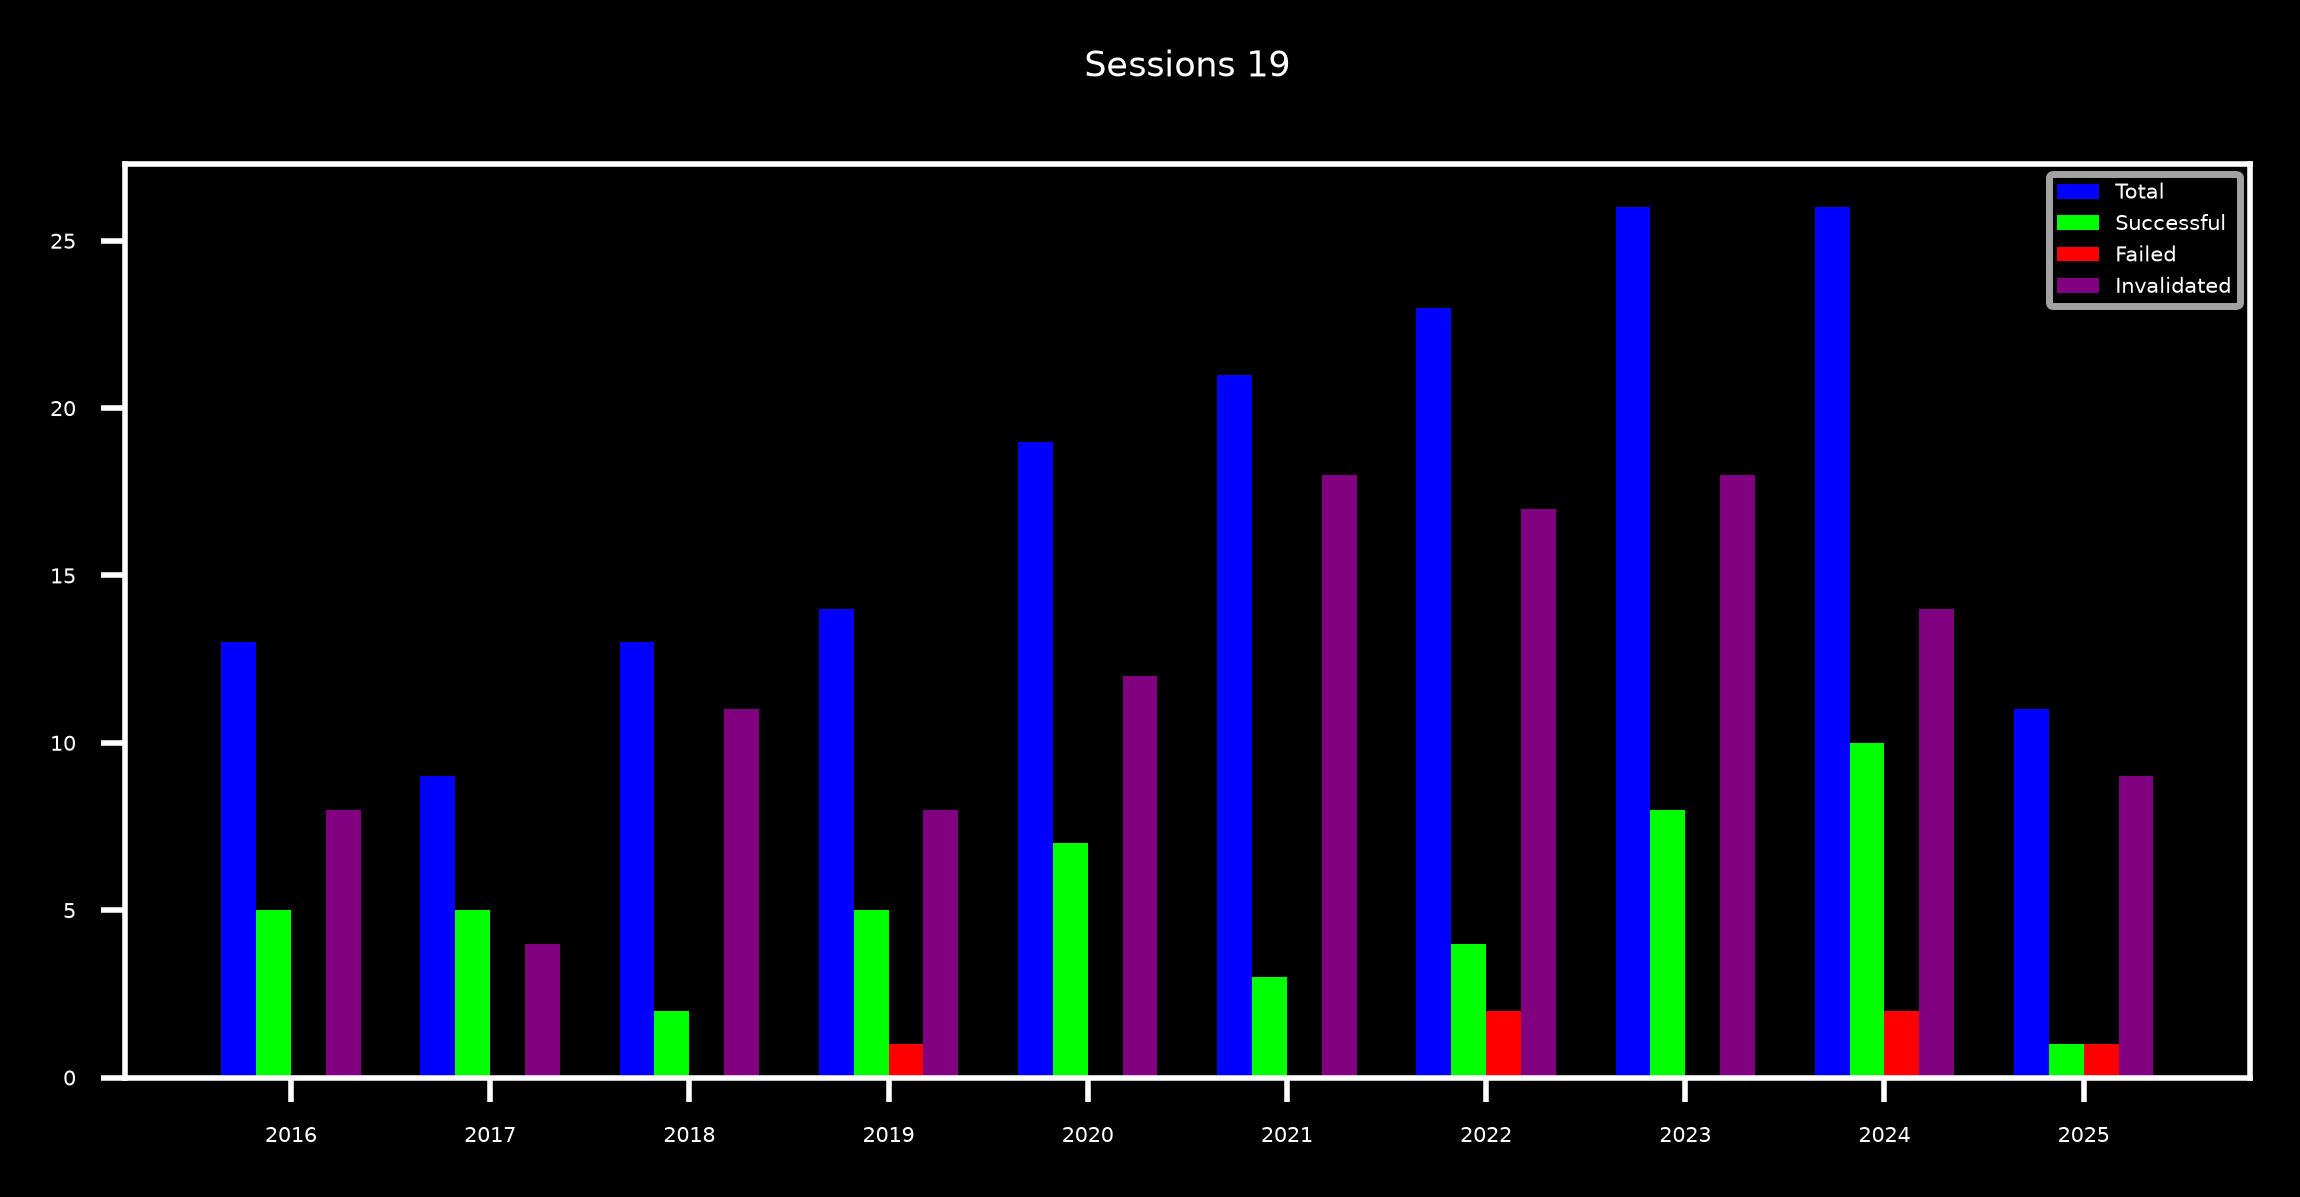

                                                         Sessions 20                                                          
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Interval ┃ Total ┃ Succ ┃ Fail ┃ Inv ┃ Succ% ┃ Fail% ┃ Inv% ┃ Chg%  ┃ MFE%  ┃  MAE%  ┃ Sharpe ┃ Sortino ┃ MaxDD%  ┃ p-val  ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│   2016   │  13   │  5   │  0   │  8  │  38   │   0   │  61  │ 6.82  │ 9.29  │ -7.71  │  4.47  │  4.59   │ -13.83% │ 0.3303 │
│   2017   │   9   │  5   │  0   │  4  │  55   │   0   │  44  │ 40.99 │ 36.3  │ -19.38 │ 22.21  │  49.74  │  0.0%   │ 0.003  │
│   2018   │  13   │  2   │  0   │ 11  │  15   │   0   │  84  │ 18.92 │ 7.24  │ -20.33 │ -8.36  │  -7.75  │ -63.82% │ 0.082  │
│   2019   │  14   │  5   │  1   │  8  │  35   │   7   │  57  │ 11.27 │ 17.34 │ -8.13  │  9.48  │  10.78  │ -12.41% │ 0.0436 │
│   2020   │  19   │  7   │  0   │ 12  │  36   │   0   │  63  │ 16.54 │ 14.15 │ -9.11  │  5.65  │   6.0   │ -34.74% │ 0.1384 │
│   2021   │  21   │  3   │  0   │ 18  │  14   │   0   │  85  │ 24.09 │ 14.36 │ -16.79 │  1.67  │  2.09   │ -59.51% │ 0.635  │
│   2022   │  23   │  4   │  1   │ 18  │  17   │   4   │  78  │ 7.65  │ 8.47  │ -11.59 │ -6.13  │  -5.39  │ -65.58% │ 0.0777 │
│   2023   │  26   │  8   │  0   │ 18  │  30   │   0   │  69  │ 16.09 │ 12.71 │ -5.88  │  8.58  │  17.04  │ -19.03% │ 0.0108 │
│   2024   │  26   │  10  │  2   │ 14  │  38   │   7   │  53  │ 15.87 │ 11.6  │ -8.15  │  5.45  │  9.83   │ -35.11% │ 0.0924 │
│   2025   │  11   │  1   │  1   │  9  │   9   │   9   │  81  │ 10.23 │ 6.27  │ -7.73  │ -4.03  │  -4.55  │ -21.6%  │ 0.4194 │
├──────────┼───────┼──────┼──────┼─────┼───────┼───────┼──────┼───────┼───────┼────────┼────────┼─────────┼─────────┼────────┤
│   SUM    │  175  │  50  │  5   │ 120 │  28   │   2   │  68  │ 16.99 │ 12.86 │ -10.83 │  3.59  │  4.71   │ -82.66% │ 0.0032 │
└──────────┴───────┴──────┴──────┴─────┴───────┴───────┴──────┴───────┴───────┴────────┴────────┴─────────┴─────────┴────────┘

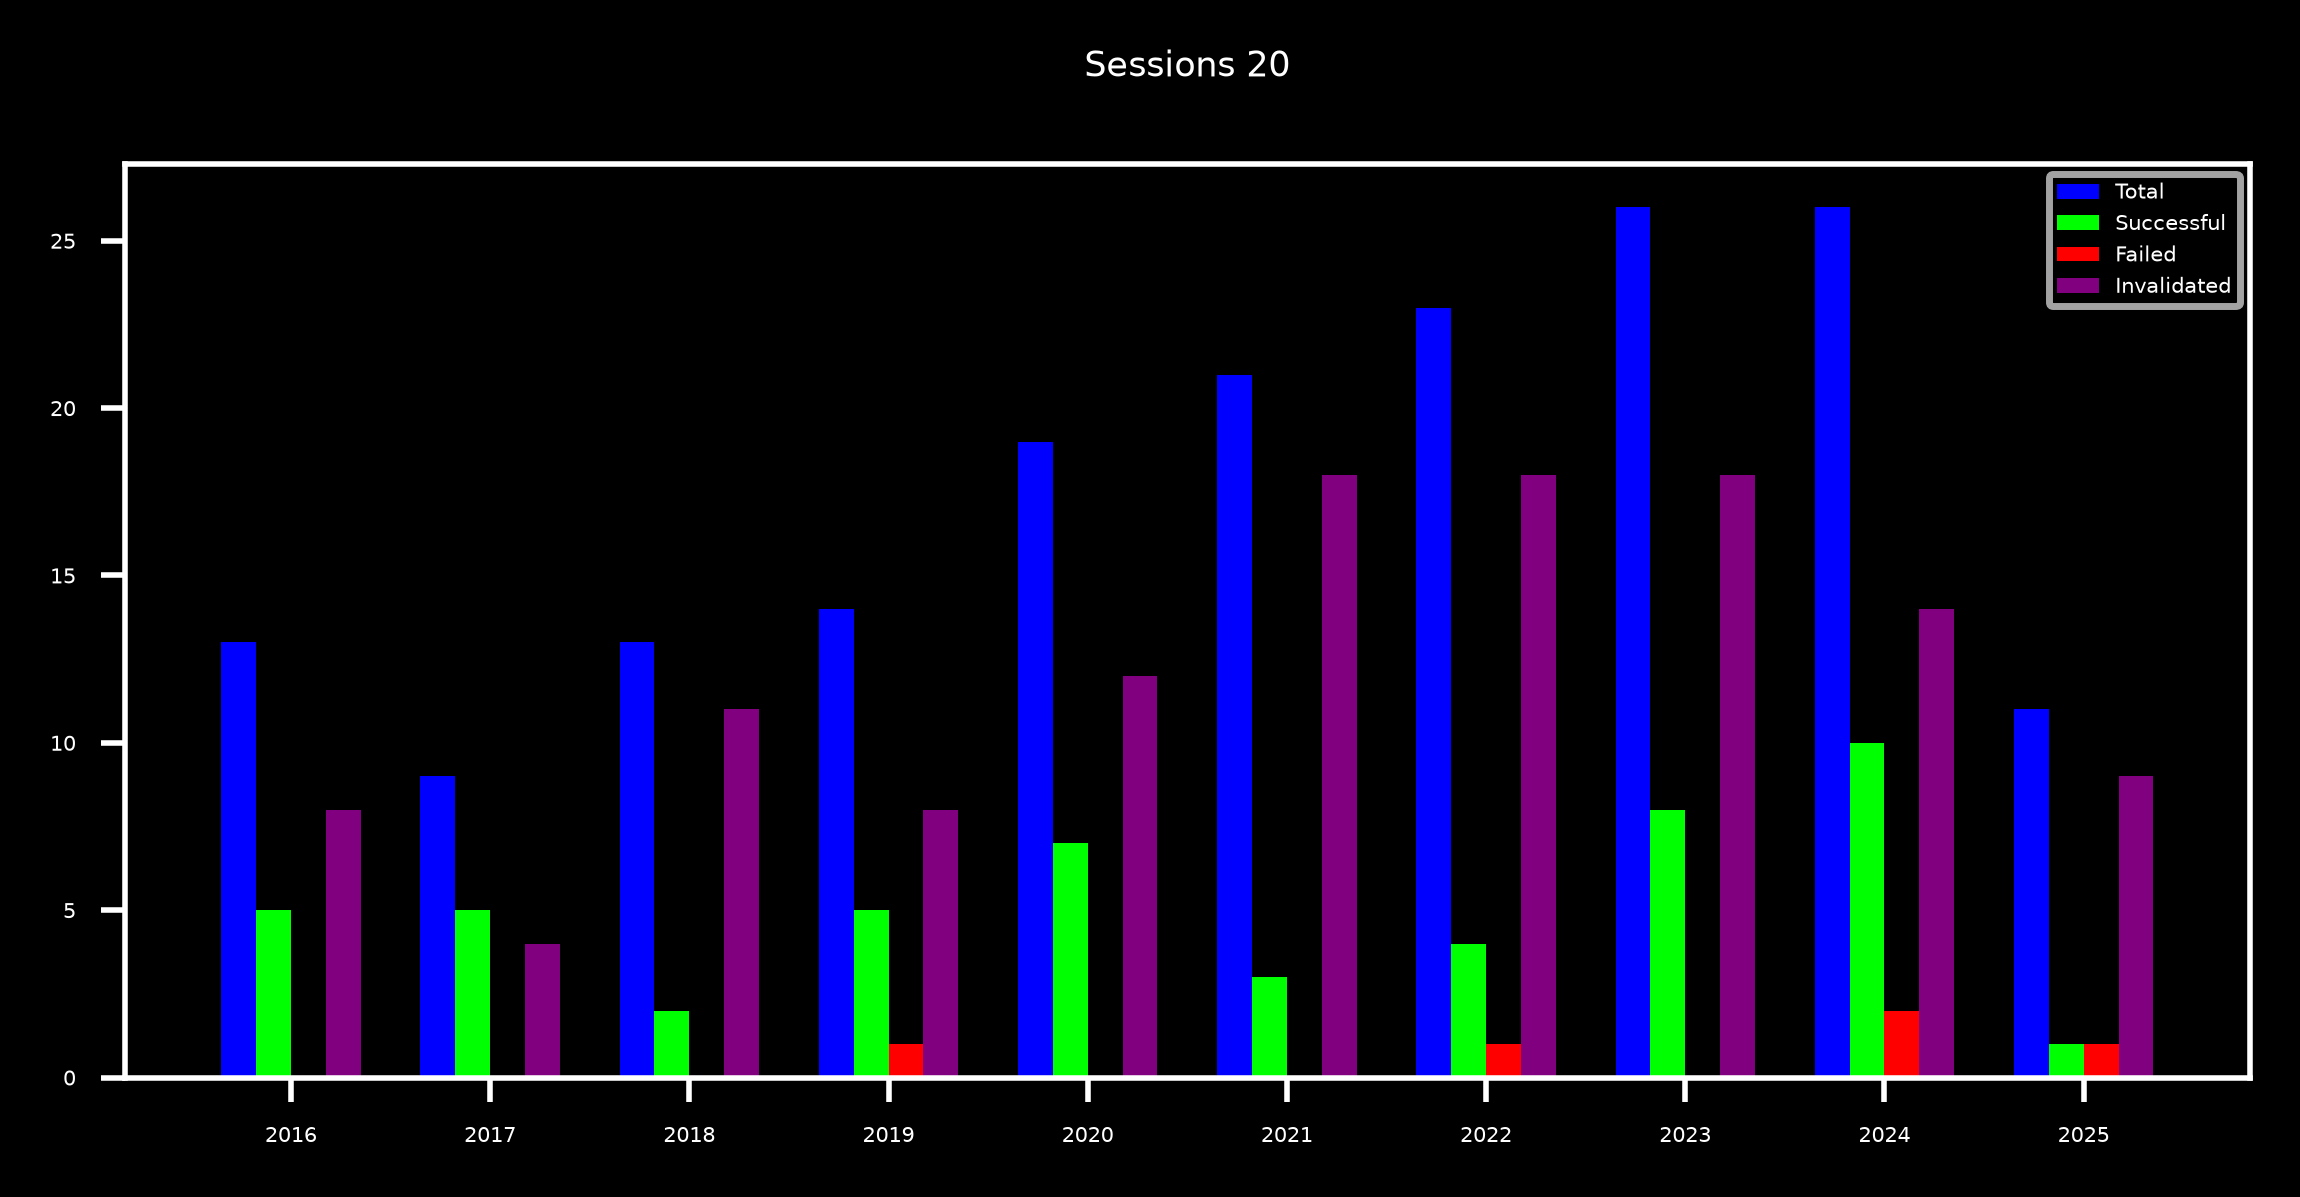

                                                         Sessions 21                                                          
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Interval ┃ Total ┃ Succ ┃ Fail ┃ Inv ┃ Succ% ┃ Fail% ┃ Inv% ┃ Chg%  ┃ MFE%  ┃  MAE%  ┃ Sharpe ┃ Sortino ┃ MaxDD%  ┃ p-val  ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│   2016   │  13   │  5   │  0   │  8  │  38   │   0   │  61  │ 6.92  │ 9.55  │ -7.71  │  2.91  │  2.36   │ -13.29% │ 0.5207 │
│   2017   │   9   │  5   │  0   │  4  │  55   │   0   │  44  │ 41.66 │ 37.08 │ -19.38 │ 19.52  │  27.26  │  0.0%   │ 0.0061 │
│   2018   │  13   │  2   │  0   │ 11  │  15   │   0   │  84  │ 12.47 │ 7.36  │ -21.43 │ -10.81 │  -8.92  │ -69.03% │ 0.0303 │
│   2019   │  14   │  5   │  1   │  8  │  35   │   7   │  57  │ 14.54 │ 17.4  │ -8.13  │  7.01  │  9.88   │ -15.64% │ 0.1224 │
│   2020   │  19   │  7   │  0   │ 12  │  36   │   0   │  63  │ 20.06 │ 15.75 │ -9.14  │  7.19  │  8.48   │ -27.19% │ 0.064  │
│   2021   │  21   │  3   │  0   │ 18  │  14   │   0   │  85  │ 20.77 │ 14.51 │ -17.03 │  1.17  │   1.4   │ -59.75% │ 0.7382 │
│   2022   │  23   │  4   │  1   │ 18  │  17   │   4   │  78  │ 7.09  │ 8.53  │ -12.04 │ -7.69  │  -6.54  │ -73.8%  │ 0.0298 │
│   2023   │  26   │  7   │  1   │ 18  │  26   │   3   │  69  │ 18.08 │ 13.22 │ -5.92  │  8.43  │  22.72  │ -19.62% │ 0.0121 │
│   2024   │  26   │  10  │  2   │ 14  │  38   │   7   │  53  │ 14.73 │ 11.81 │ -8.35  │  5.6   │  9.93   │ -33.02% │ 0.0844 │
│   2025   │  11   │  1   │  1   │  9  │   9   │   9   │  81  │ 9.11  │ 6.37  │ -7.73  │ -2.34  │  -2.83  │ -16.54% │ 0.6352 │
├──────────┼───────┼──────┼──────┼─────┼───────┼───────┼──────┼───────┼───────┼────────┼────────┼─────────┼─────────┼────────┤
│   SUM    │  175  │  49  │  6   │ 120 │  28   │   3   │  68  │ 17.44 │ 13.25 │ -11.04 │  3.23  │   4.3   │ -87.95% │ 0.0078 │
└──────────┴───────┴──────┴──────┴─────┴───────┴───────┴──────┴───────┴───────┴────────┴────────┴─────────┴─────────┴────────┘

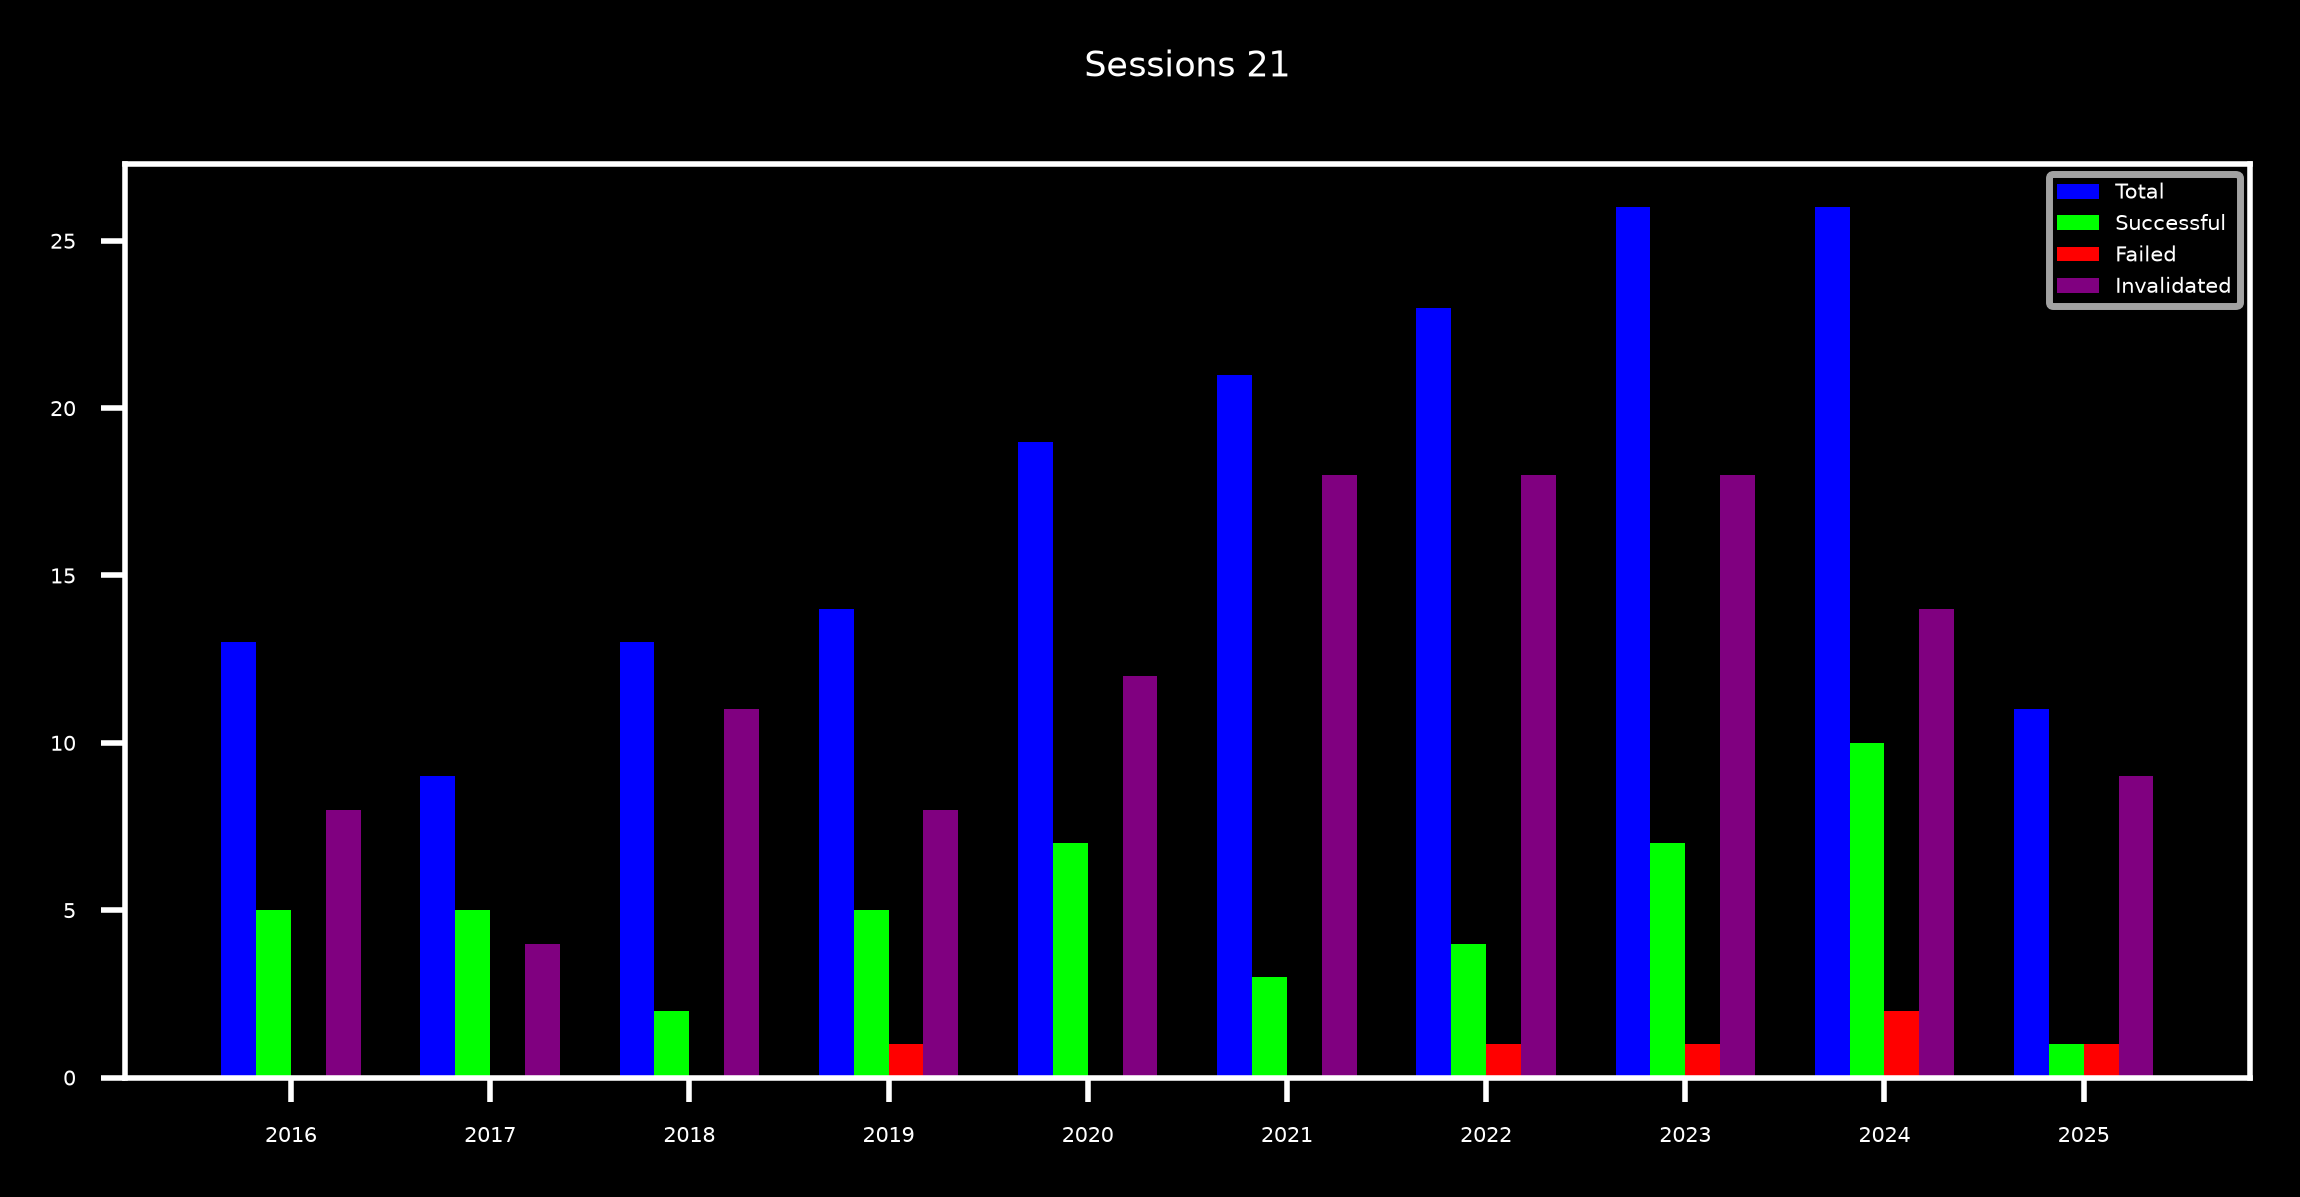

                                                         Sessions 22                                                          
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Interval ┃ Total ┃ Succ ┃ Fail ┃ Inv ┃ Succ% ┃ Fail% ┃ Inv% ┃ Chg%  ┃ MFE%  ┃  MAE%  ┃ Sharpe ┃ Sortino ┃ MaxDD%  ┃ p-val  ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│   2016   │  13   │  5   │  0   │  8  │  38   │   0   │  61  │ 8.44  │ 10.14 │ -7.71  │  3.81  │  3.47   │ -15.45% │ 0.4039 │
│   2017   │   9   │  5   │  0   │  4  │  55   │   0   │  44  │ 37.99 │ 37.85 │ -19.38 │  19.4  │  24.6   │  0.0%   │ 0.0063 │
│   2018   │  13   │  2   │  0   │ 11  │  15   │   0   │  84  │ 11.52 │ 7.36  │ -21.76 │ -13.26 │ -10.08  │ -77.11% │ 0.0109 │
│   2019   │  14   │  5   │  1   │  8  │  35   │   7   │  57  │ 12.81 │ 17.44 │ -8.13  │  7.77  │  12.76  │ -15.17% │ 0.0899 │
│   2020   │  19   │  7   │  0   │ 12  │  36   │   0   │  63  │ 18.7  │ 16.63 │ -9.14  │  7.53  │  7.68   │ -24.1%  │ 0.0534 │
│   2021   │  21   │  3   │  0   │ 18  │  14   │   0   │  85  │ 18.92 │ 15.09 │ -17.05 │  1.23  │  1.76   │ -58.98% │ 0.7259 │
│   2022   │  23   │  3   │  2   │ 18  │  13   │   8   │  78  │ 8.28  │ 8.53  │ -12.1  │ -6.87  │  -6.0   │ -70.83% │ 0.0497 │
│   2023   │  26   │  7   │  1   │ 18  │  26   │   3   │  69  │ 19.11 │ 13.48 │ -6.09  │  9.4   │  27.3   │ -16.2%  │ 0.0057 │
│   2024   │  26   │  10  │  2   │ 14  │  38   │   7   │  53  │ 15.77 │ 11.84 │ -8.45  │  5.84  │  11.87  │ -33.84% │ 0.0726 │
│   2025   │  11   │  1   │  1   │  9  │   9   │   9   │  81  │ 8.73  │ 6.58  │ -7.74  │ -1.18  │  -1.43  │ -15.49% │  0.81  │
├──────────┼───────┼──────┼──────┼─────┼───────┼───────┼──────┼───────┼───────┼────────┼────────┼─────────┼─────────┼────────┤
│   SUM    │  175  │  48  │  7   │ 120 │  27   │   4   │  68  │ 17.33 │ 13.55 │ -11.11 │  3.34  │  4.47   │ -86.78% │ 0.006  │
└──────────┴───────┴──────┴──────┴─────┴───────┴───────┴──────┴───────┴───────┴────────┴────────┴─────────┴─────────┴────────┘

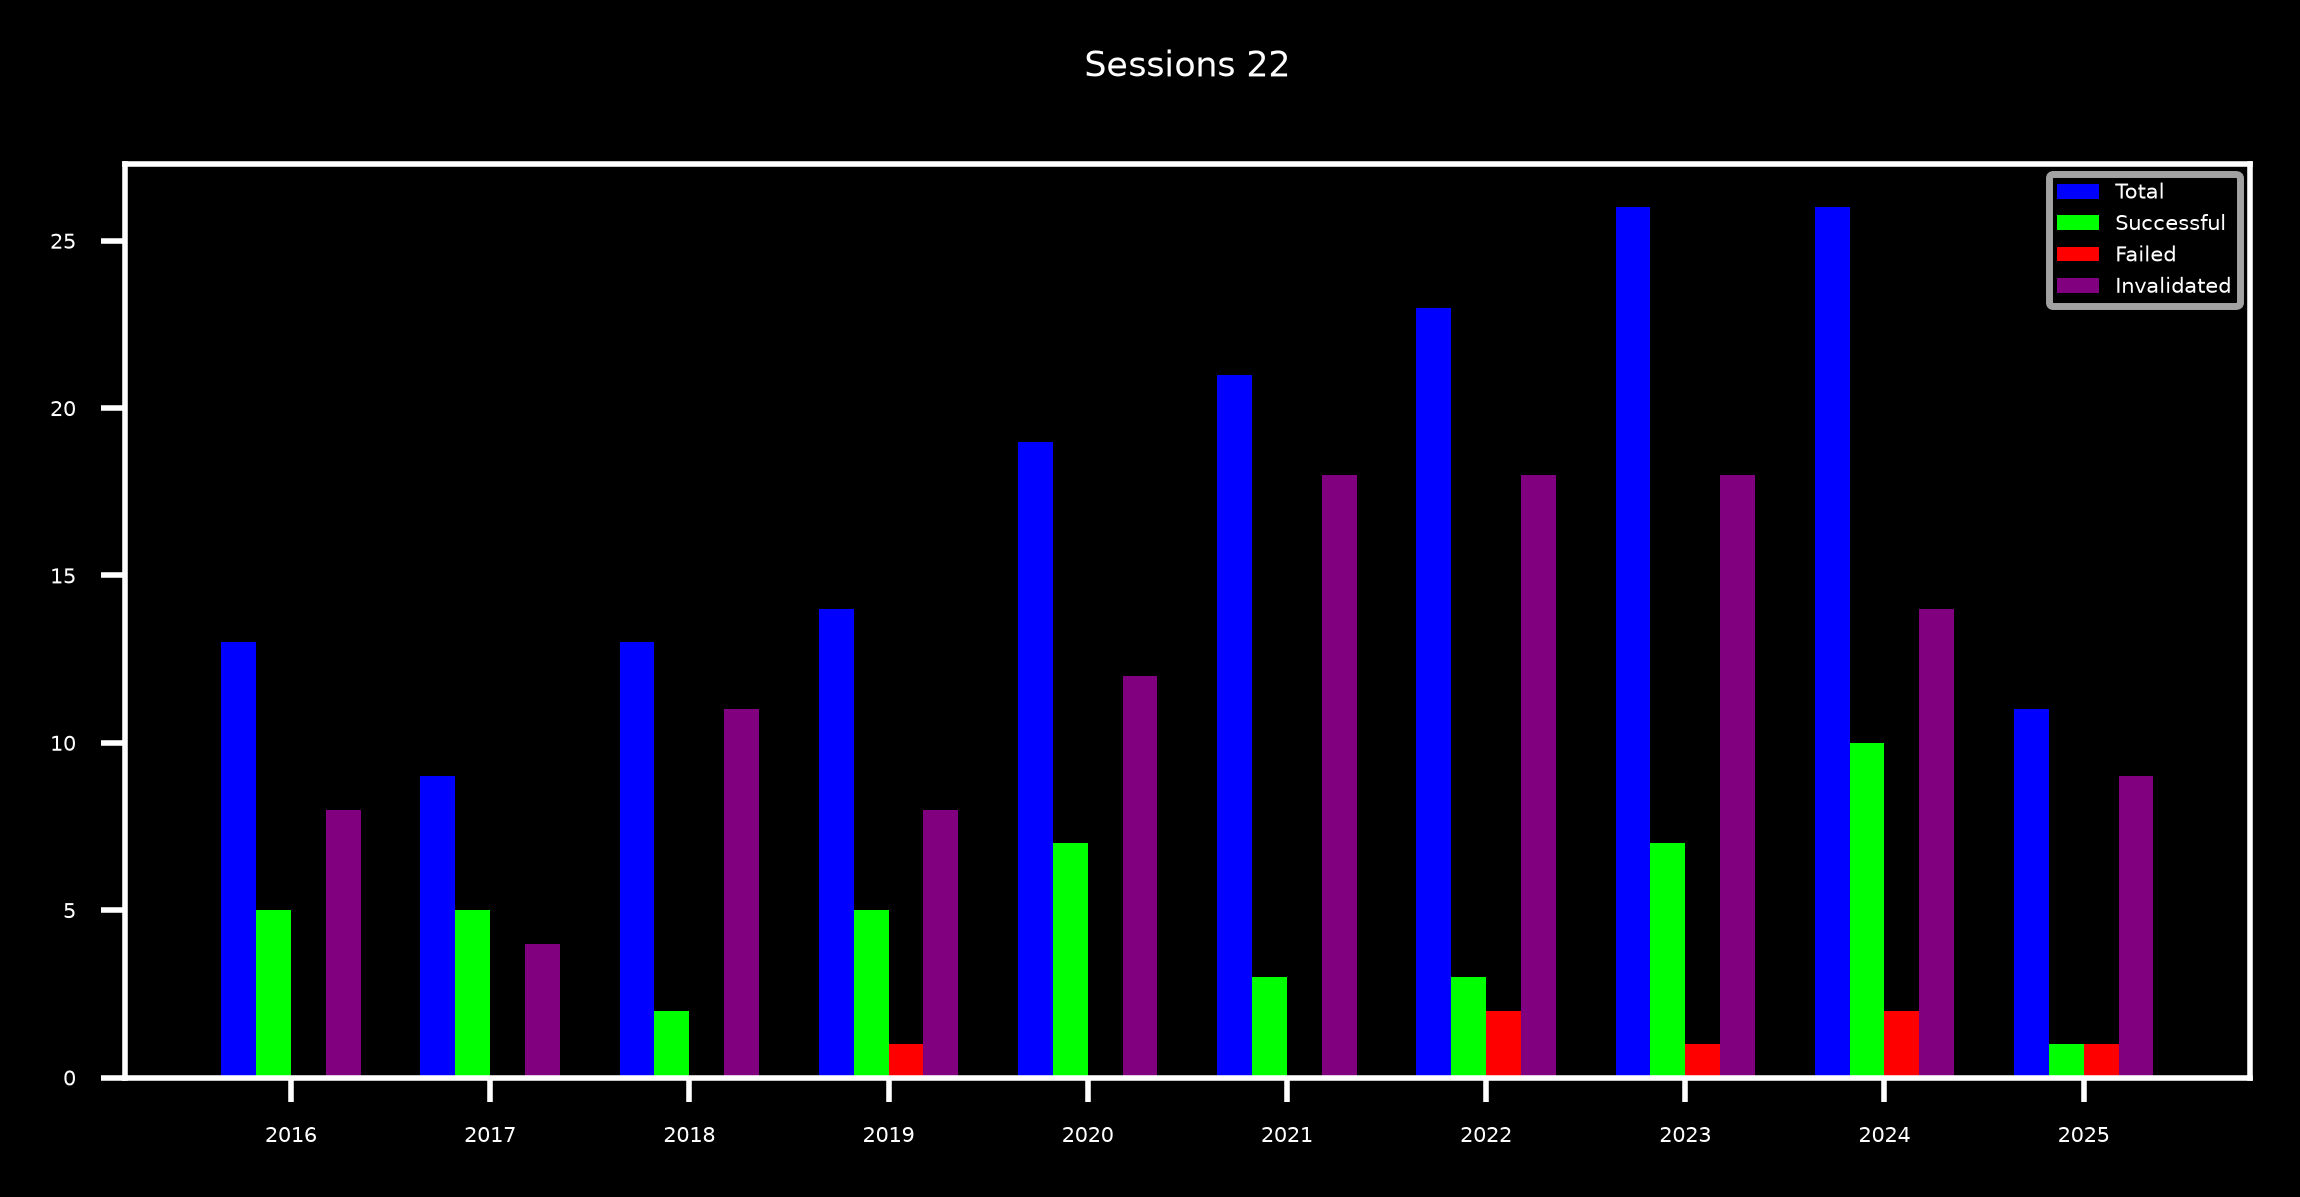

                                                         Sessions 23                                                          
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Interval ┃ Total ┃ Succ ┃ Fail ┃ Inv ┃ Succ% ┃ Fail% ┃ Inv% ┃ Chg%  ┃ MFE%  ┃  MAE%  ┃ Sharpe ┃ Sortino ┃ MaxDD%  ┃ p-val  ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│   2016   │  13   │  5   │  0   │  8  │  38   │   0   │  61  │  8.8  │ 10.28 │ -7.71  │  4.53  │  4.45   │ -15.8%  │ 0.324  │
│   2017   │   9   │  5   │  0   │  4  │  55   │   0   │  44  │ 41.08 │ 38.35 │ -19.38 │ 16.04  │  16.97  │  0.0%   │ 0.0163 │
│   2018   │  13   │  2   │  0   │ 11  │  15   │   0   │  84  │ 10.64 │ 7.36  │ -22.17 │ -12.8  │  -9.8   │ -78.68% │ 0.0132 │
│   2019   │  14   │  5   │  1   │  8  │  35   │   7   │  57  │ 12.75 │ 17.65 │ -8.13  │  7.59  │  11.98  │ -15.51% │ 0.0971 │
│   2020   │  19   │  7   │  0   │ 12  │  36   │   0   │  63  │ 19.18 │ 17.69 │ -9.14  │  7.49  │  8.66   │ -24.95% │ 0.0546 │
│   2021   │  21   │  3   │  0   │ 18  │  14   │   0   │  85  │ 18.78 │ 15.26 │ -17.31 │  1.3   │  1.76   │ -66.6%  │ 0.7107 │
│   2022   │  23   │  2   │  3   │ 18  │   8   │  13   │  78  │  9.9  │ 8.65  │ -12.69 │ -7.98  │  -6.92  │ -79.48% │ 0.0247 │
│   2023   │  26   │  7   │  0   │ 19  │  26   │   0   │  73  │ 19.53 │ 13.57 │ -6.36  │  9.06  │  19.53  │ -19.32% │ 0.0075 │
│   2024   │  26   │  9   │  3   │ 14  │  34   │  11   │  53  │ 16.85 │ 12.19 │ -8.45  │  5.41  │  10.81  │ -42.26% │ 0.0946 │
│   2025   │  11   │  1   │  0   │ 10  │   9   │   0   │  90  │ 8.03  │ 7.14  │ -8.18  │ -2.25  │  -2.65  │ -17.27% │ 0.649  │
├──────────┼───────┼──────┼──────┼─────┼───────┼───────┼──────┼───────┼───────┼────────┼────────┼─────────┼─────────┼────────┤
│   SUM    │  175  │  46  │  7   │ 122 │  26   │   4   │  69  │ 18.29 │ 13.86 │ -11.32 │  2.99  │   3.9   │ -90.67% │ 0.0135 │
└──────────┴───────┴──────┴──────┴─────┴───────┴───────┴──────┴───────┴───────┴────────┴────────┴─────────┴─────────┴────────┘

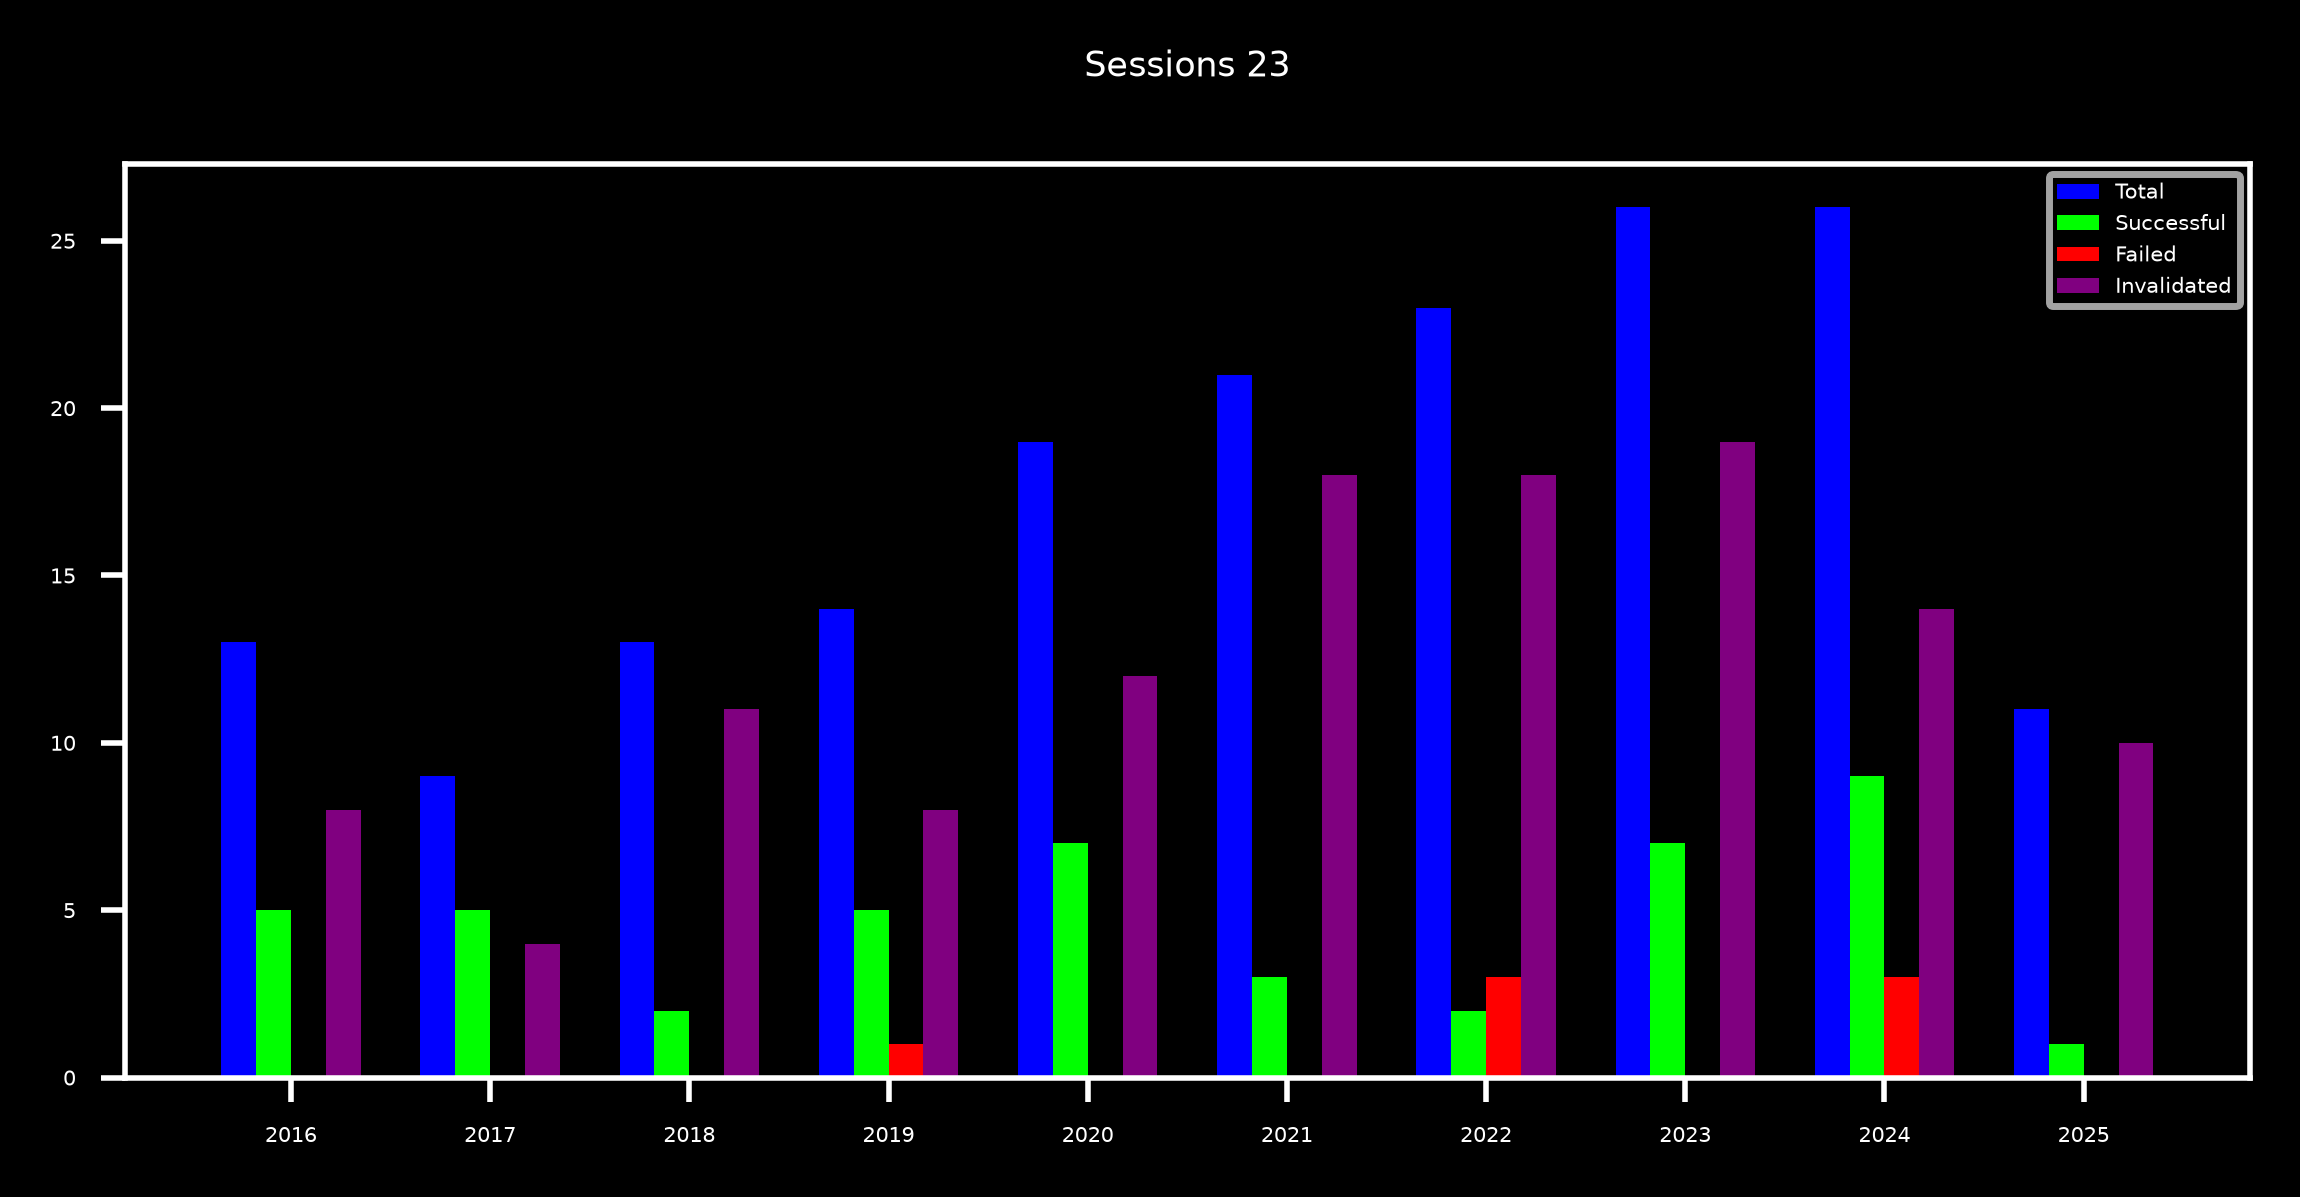

                                                         Sessions 24                                                          
┏━━━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ Interval ┃ Total ┃ Succ ┃ Fail ┃ Inv ┃ Succ% ┃ Fail% ┃ Inv% ┃ Chg%  ┃ MFE%  ┃  MAE%  ┃ Sharpe ┃ Sortino ┃ MaxDD%  ┃ p-val  ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│   2016   │  13   │  5   │  0   │  8  │  38   │   0   │  61  │ 9.51  │ 10.72 │ -7.71  │  4.85  │  4.79   │ -14.13% │ 0.2921 │
│   2017   │   9   │  5   │  0   │  4  │  55   │   0   │  44  │ 40.09 │ 41.74 │ -19.65 │ 16.57  │  19.87  │  0.0%   │ 0.014  │
│   2018   │  13   │  1   │  1   │ 11  │   7   │   7   │  84  │ 24.47 │ 7.57  │ -22.69 │ -12.57 │ -10.38  │ -79.18% │ 0.0145 │
│   2019   │  14   │  5   │  1   │  8  │  35   │   7   │  57  │ 18.15 │ 19.87 │ -8.13  │  8.98  │  17.94  │ -14.67% │ 0.0541 │
│   2020   │  19   │  7   │  0   │ 12  │  36   │   0   │  63  │ 14.74 │ 17.76 │ -9.63  │  6.06  │   5.6   │ -36.24% │ 0.1136 │
│   2021   │  21   │  3   │  0   │ 18  │  14   │   0   │  85  │ 17.04 │ 15.96 │ -17.4  │  1.4   │  2.03   │ -64.38% │ 0.6902 │
│   2022   │  23   │  3   │  2   │ 18  │  13   │   8   │  78  │ 7.81  │ 8.65  │ -13.08 │ -7.25  │  -6.29  │ -76.51% │ 0.0394 │
│   2023   │  26   │  7   │  0   │ 19  │  26   │   0   │  73  │ 19.84 │ 13.84 │ -6.47  │  8.52  │  18.4   │ -21.39% │ 0.0112 │
│   2024   │  26   │  9   │  2   │ 15  │  34   │   7   │  57  │ 14.71 │ 12.75 │ -8.55  │  4.89  │  8.47   │ -49.95% │ 0.1287 │
│   2025   │  11   │  1   │  0   │ 10  │   9   │   0   │  90  │ 8.34  │ 7.26  │ -8.46  │ -1.61  │  -2.03  │ -16.99% │ 0.7428 │
├──────────┼───────┼──────┼──────┼─────┼───────┼───────┼──────┼───────┼───────┼────────┼────────┼─────────┼─────────┼────────┤
│   SUM    │  175  │  46  │  6   │ 123 │  26   │   3   │  70  │ 17.84 │ 14.48 │ -11.53 │  3.0   │  3.99   │ -89.3%  │ 0.0134 │
└──────────┴───────┴──────┴──────┴─────┴───────┴───────┴──────┴───────┴───────┴────────┴────────┴─────────┴─────────┴────────┘

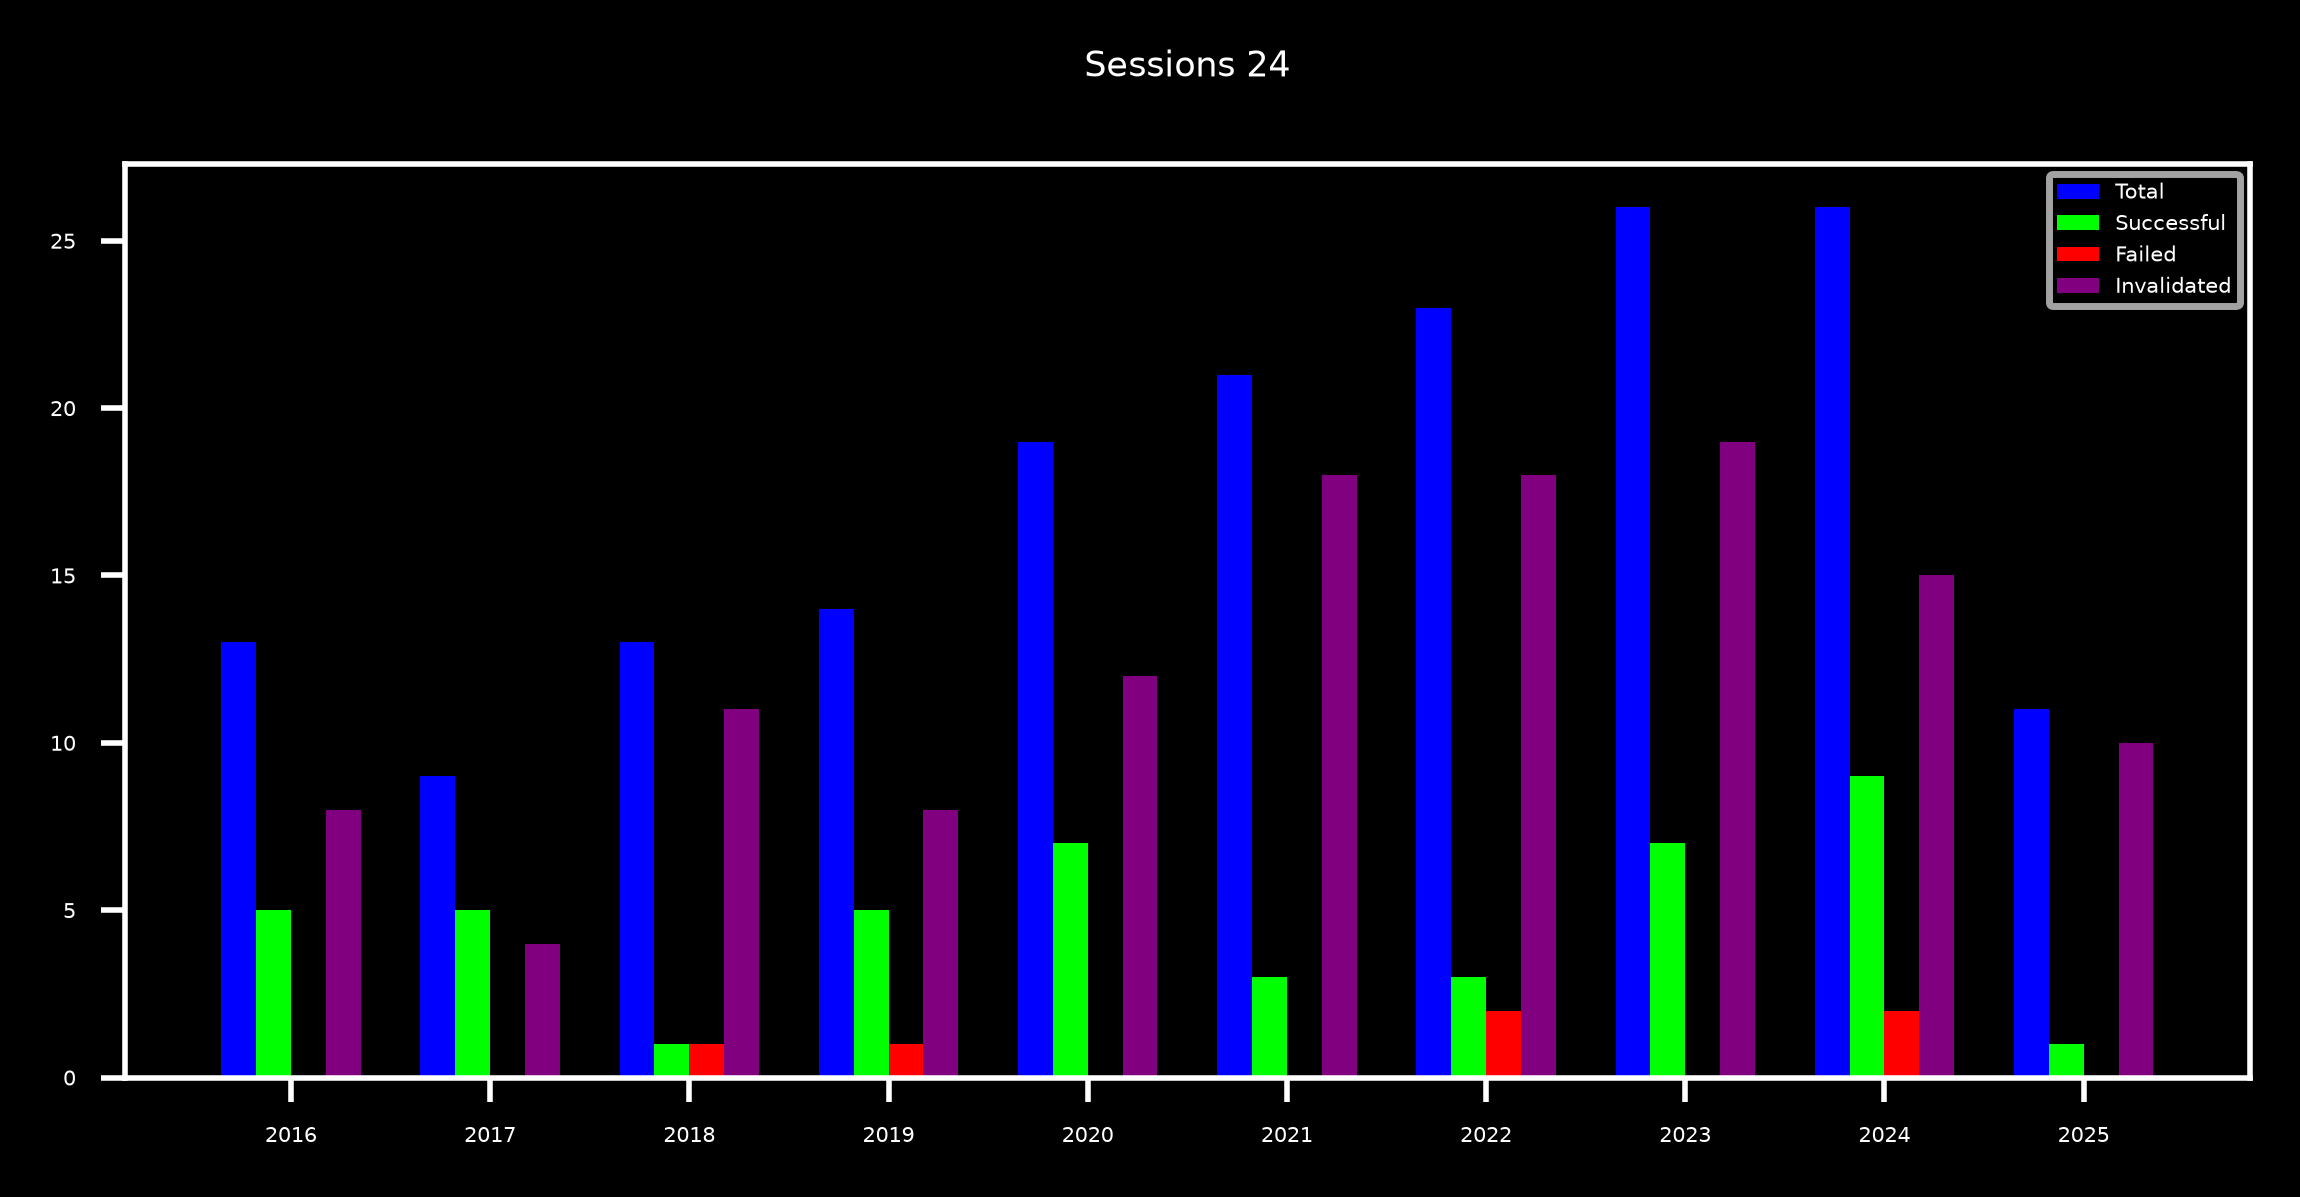

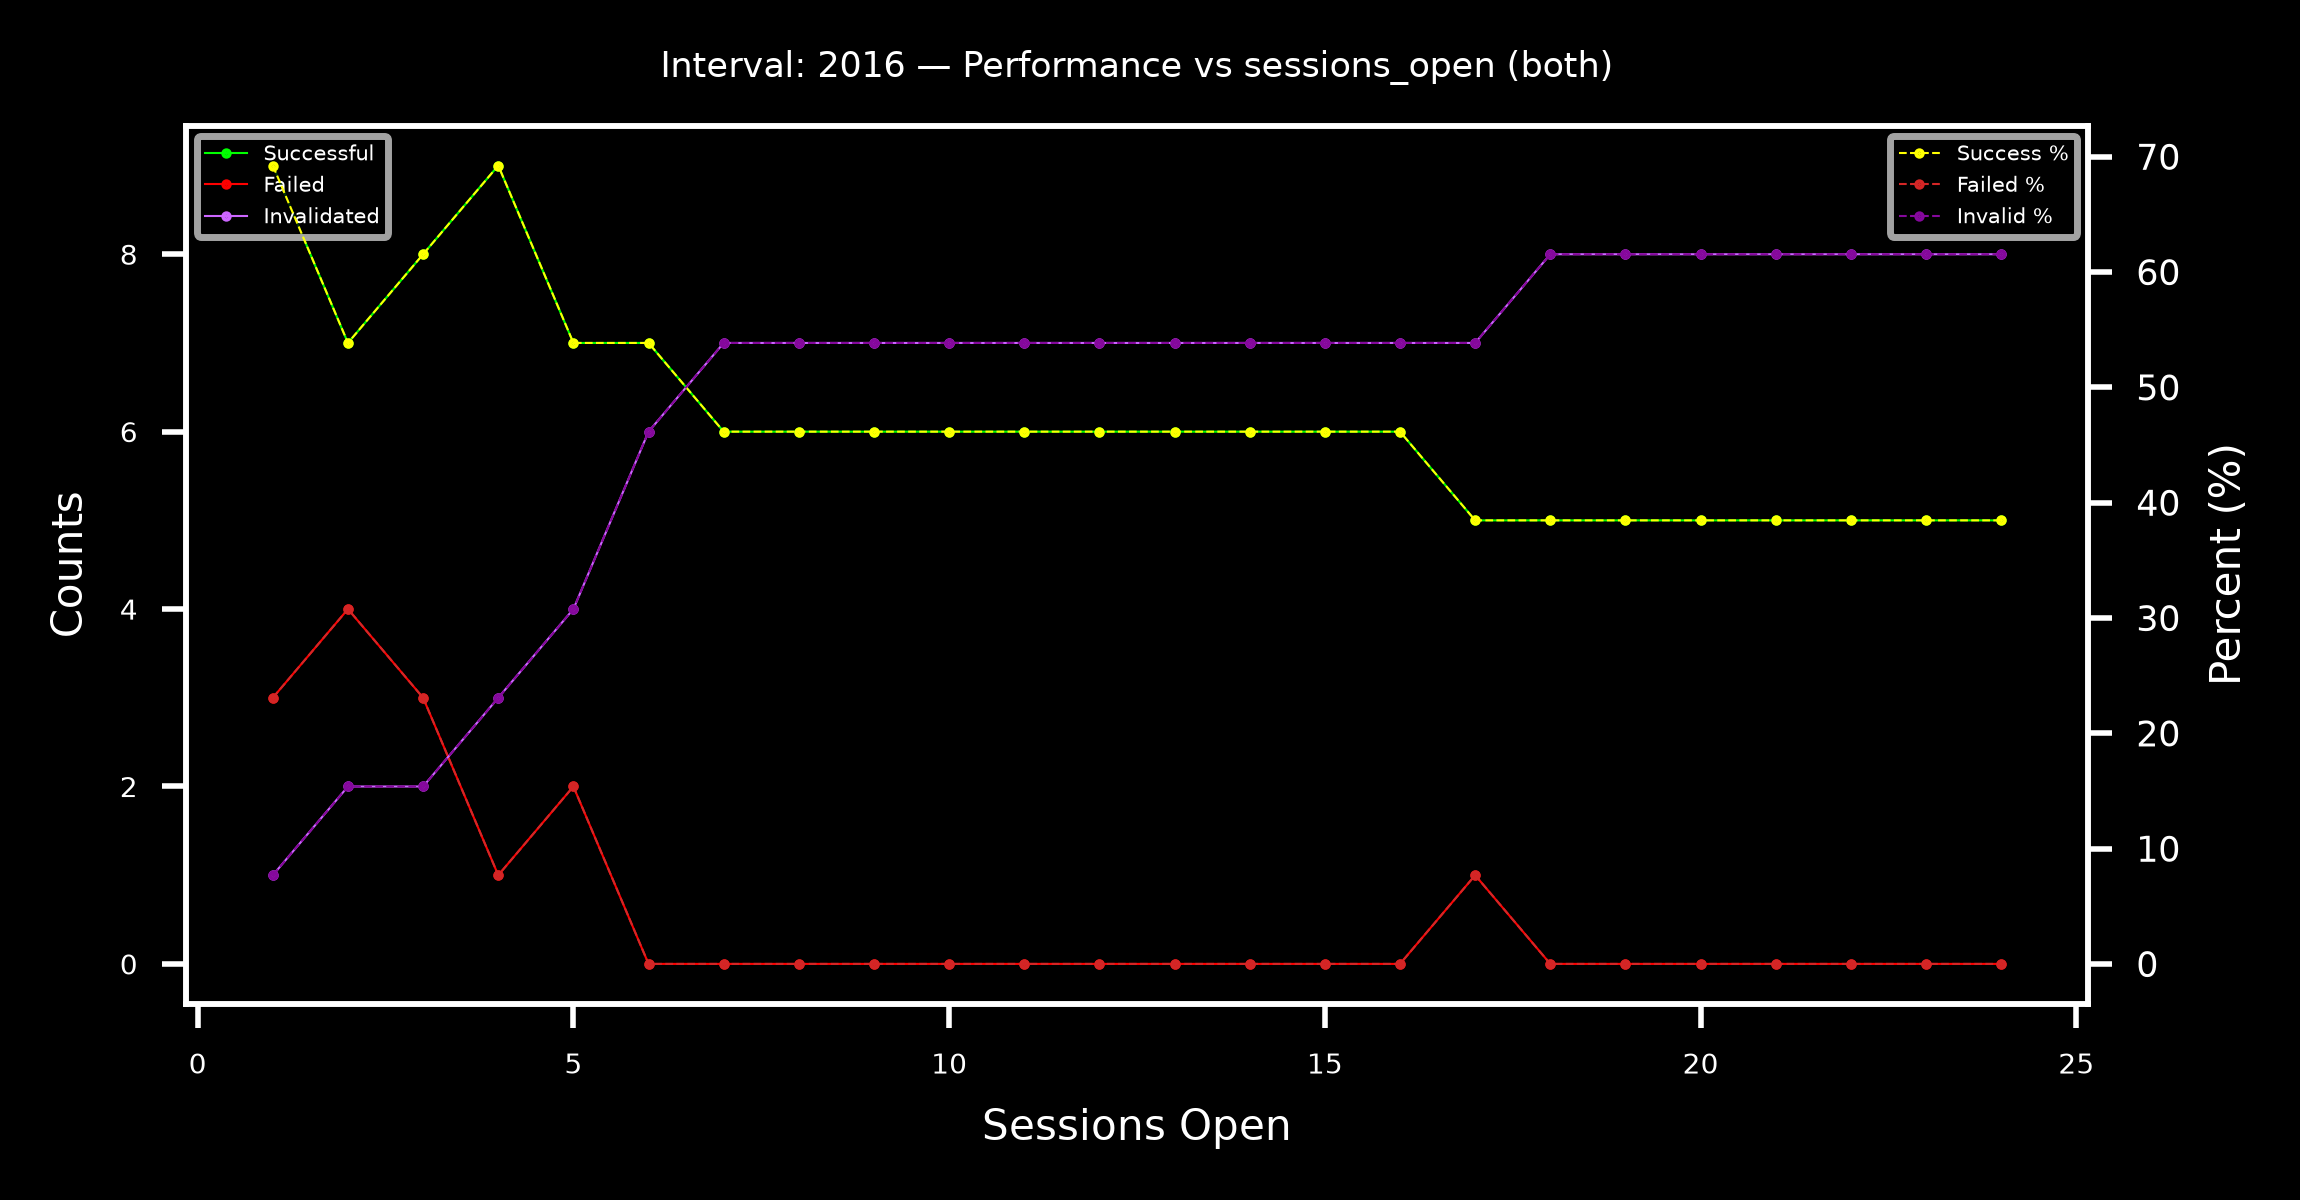

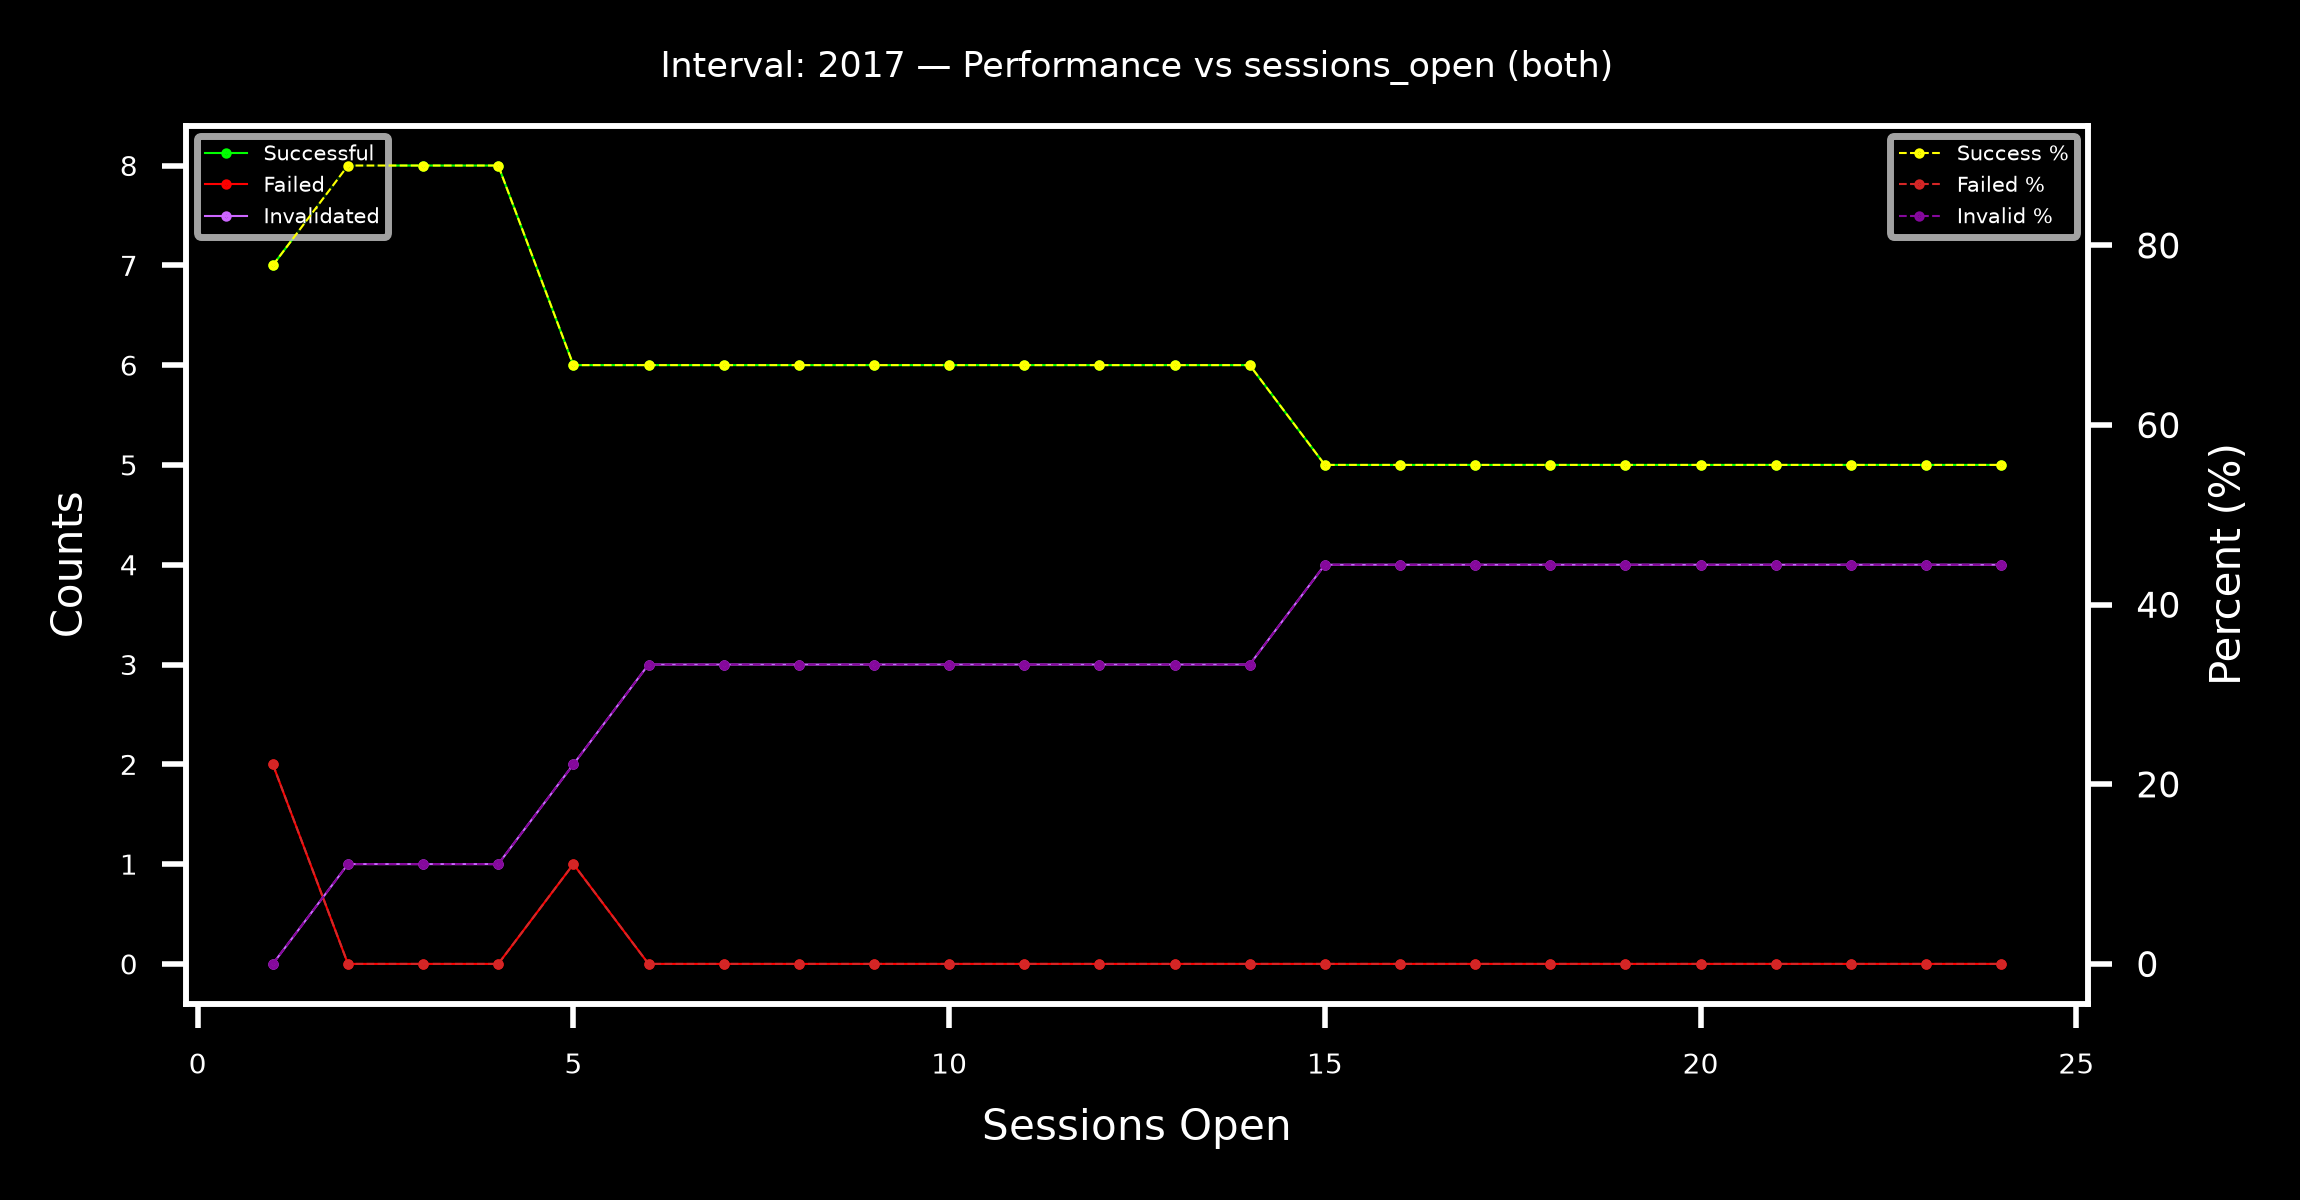

KeyboardInterrupt: 

In [7]:
engine.run(show_results=True, plot_patterns=False)

In [ ]:
engine.show_stats_per_session()

In [ ]:
engine.show_stats_progress_in_intervals(mode='absolute')

In [ ]:
engine.show_stats_progress_in_intervals(mode='percentage')

In [ ]:
epoch_intervals = [
    (date_to_epoch(f"16/12/2017 00:00:00"), date_to_epoch(f"15/12/2018 00:00:00")),
    (date_to_epoch(f"15/12/2018 00:00:00"), date_to_epoch(f"30/10/2021 00:00:00")),
    (date_to_epoch(f"30/10/2021 00:00:00"), date_to_epoch(f"21/11/2022 00:00:00")),
    (date_to_epoch(f"21/11/2022 00:00:00"), date_to_epoch(f"01/01/2026 00:00:00"))
]
epoch_titles = [
    "Bear 2018",
    "Bull 2019-",
    "Bear 2022",
    "Bull 2023-"
]

sessions_open_list = [i for i in range(1, 50)]

In [ ]:
engine = PatternEngine(
    loader=loader,
    evaluator=evaluator,
    intervals=epoch_intervals,
    interval_labels=epoch_titles,
    sessions_open_list=sessions_open_list
)

In [ ]:
engine.run(show_results=False)

In [ ]:
engine.show_stats_per_session()

In [ ]:
engine.show_stats_progress_in_intervals(mode='absolute')

In [ ]:
engine.show_stats_progress_in_intervals(mode='percentage')